Hybrid Recommendation System using SVD and TF-IDF

In [1]:
import pandas as pd
import numpy as np
import os

# Завантаження даних
output_dir = os.path.join('..', 'data', 'processed')
anime_info = pd.read_parquet(os.path.join(output_dir, "anime_clean.parquet"))
train = pd.read_parquet(os.path.join(output_dir, "train_final.parquet"))
test = pd.read_parquet(os.path.join(output_dir, "test_final.parquet"))
val = pd.read_parquet(os.path.join(output_dir, "val_final.parquet"))

In [2]:
import numpy as np
import gc

# 1. Визначаємо унікальних користувачів
train_users = set(train['user_id'].unique())
test_users = set(test['user_id'].unique())

# 2. Відбираємо обов'язкових (тільки тих, хто є в test)
must_keep_users = train_users.intersection(test_users)

# Ті, з кого будемо обирати випадково
optional_users = list(train_users - must_keep_users)

# 3. Рахуємо цільову кількість (30% від Train)
target_user_count = int(len(train_users) * 0.30)

print(f"Всього унікальних користувачів у Train: {len(train_users)}")
print(f"Обов'язкових (є в test): {len(must_keep_users)}")
print(f"Цільова кількість (30%): {target_user_count}")

# 4. Формуємо фінальний набір користувачів
if len(must_keep_users) >= target_user_count:
    print("⚠️ Увага: Користувачів з test більше (або дорівнює) 30%. Залишаємо тільки їх.")
    final_users_to_keep = must_keep_users
else:
    # Рахуємо, скільки ще треба добрати
    needed_random_users = target_user_count - len(must_keep_users)
    
    np.random.seed(42) # Для відтворюваності
    sampled_optional = np.random.choice(optional_users, size=needed_random_users, replace=False)
    
    final_users_to_keep = must_keep_users.union(set(sampled_optional))

# 5. ЗМЕНШУЄМО TRAIN
train_small = train[train['user_id'].isin(final_users_to_keep)].copy()

# 6. ЗМЕНШУЄМО VAL (залишаємо тільки тих, хто вижив у train_small)
val_small = val[val['user_id'].isin(final_users_to_keep)].copy()

print(f"\n--- Результати скорочення ---")
print(f"Train: було {len(train)} записів -> стало {len(train_small)}")
print(f"Val:   було {len(val)} записів -> стало {len(val_small)}")
print(f"Test:  залишається незмінним ({len(test)} записів)")

# Примусово чистимо пам'ять
gc.collect()

Всього унікальних користувачів у Train: 280510
Обов'язкових (є в test): 28047
Цільова кількість (30%): 84153

--- Результати скорочення ---
Train: було 44080125 записів -> стало 11873128
Val:   було 10676750 записів -> стало 2623574
Test:  залишається незмінним (2735694 записів)


0

In [3]:
print(f"Кількість користувачів в тестовій вибірці: {len(test['user_id'].unique())}")
print(f"Кількість користувачів в валідаційній вибірці: {len(val_small['user_id'].unique())}")
print(f"Кількість користувачів в тренувальній вибірці: {len(train_small['user_id'].unique())}")

Кількість користувачів в тестовій вибірці: 28047
Кількість користувачів в валідаційній вибірці: 61554
Кількість користувачів в тренувальній вибірці: 84153


In [4]:
# Збереження train_small та val_small у форматі parquet
train_small.to_parquet(os.path.join(output_dir, "train_small.parquet"), index=False)
val_small.to_parquet(os.path.join(output_dir, "val_small.parquet"), index=False)

print("✓ train_small збережений")
print("✓ val_small збережений")
print(f"Файли збережені в папку: {output_dir}")

✓ train_small збережений
✓ val_small збережений
Файли збережені в папку: ..\data\processed


✅ Гібридні ваги розраховано!
W_collab (SVD): 0.8446
W_content (TF-IDF): 0.1554
--- Результати для SVD (Pure Collaborative) ---
RMSE: 1.2089 | MSE: 1.4616 | MAE: 0.9042
--- Результати для TF-IDF (Pure Content) ---
RMSE: 1.4755 | MSE: 2.1771 | MAE: 1.1056
--- Результати для Hybrid Model (SVD + TF-IDF) ---
RMSE: 1.2036 | MSE: 1.4486 | MAE: 0.9018

In [5]:
import pandas as pd
import numpy as np
import os

In [6]:
test = pd.read_parquet(os.path.join(output_dir, 'anime_test_predictions.parquet'))

print(f"Успішно завантажено! Кількість тестових записів: {len(test)}")
print(test[['user_id', 'anime_id', 'rating', 'svd_pred', 'content_pred', 'hybrid_pred']].head())

Успішно завантажено! Кількість тестових записів: 2735694
   user_id  anime_id  rating  svd_pred  content_pred  hybrid_pred
0       20     36754       8  7.036268      7.086447     7.044064
1       20     16498       8  8.742247      7.161861     8.496729
2       20     35507       7  7.469710      7.395607     7.458198
3       20     36456       9  8.519880      7.611506     8.378761
4       20     34134       7  7.373141      7.666783     7.418759


In [7]:
# 1. Створюємо маску для фільтрації (оцінка менше 6)
low_ratings_mask = test['rating'] < 6

# 2. Відбираємо потрібні колонки
columns_to_show = ['user_id', 'anime_id', 'rating', 'svd_pred', 'content_pred', 'hybrid_pred']

# 3. Застосовуємо маску та колонки до датафрейму
low_ratings_df = test.loc[low_ratings_mask, columns_to_show]

# Виводимо загальну кількість таких записів
print(f"Кількість записів з оцінкою < 6: {len(low_ratings_df)}")

# Виводимо перші 15 рядків для візуального аналізу
print("\n--- Приклади прогнозів для низьких оцінок ---")
print(low_ratings_df.head(15).to_string(index=False))

Кількість записів з оцінкою < 6: 302617

--- Приклади прогнозів для низьких оцінок ---
 user_id  anime_id  rating  svd_pred  content_pred  hybrid_pred
      20     35203       3  5.085167      6.513150     5.307009
      20     33012       5  5.497510      7.138423     5.752431
      27     33836       5  7.064483      7.479775     7.129000
      27       743       5  6.497456      7.494921     6.652415
      56       570       5  8.410882      8.653543     8.448580
     164       836       2  6.445117      7.362768     6.587677
     164       651       4  5.956993           NaN     5.956993
     164       991       4  6.093996      7.255223     6.274396
     164       257       5  6.291764      7.567179     6.489903
     173      2476       5  6.056253      7.557625     6.289496
     173     19315       2  3.197886      7.404613     3.851415
     215     27787       5  8.583003      7.908475     8.478213
     248      9136       5  7.073177      7.724958     7.174433
     248      679

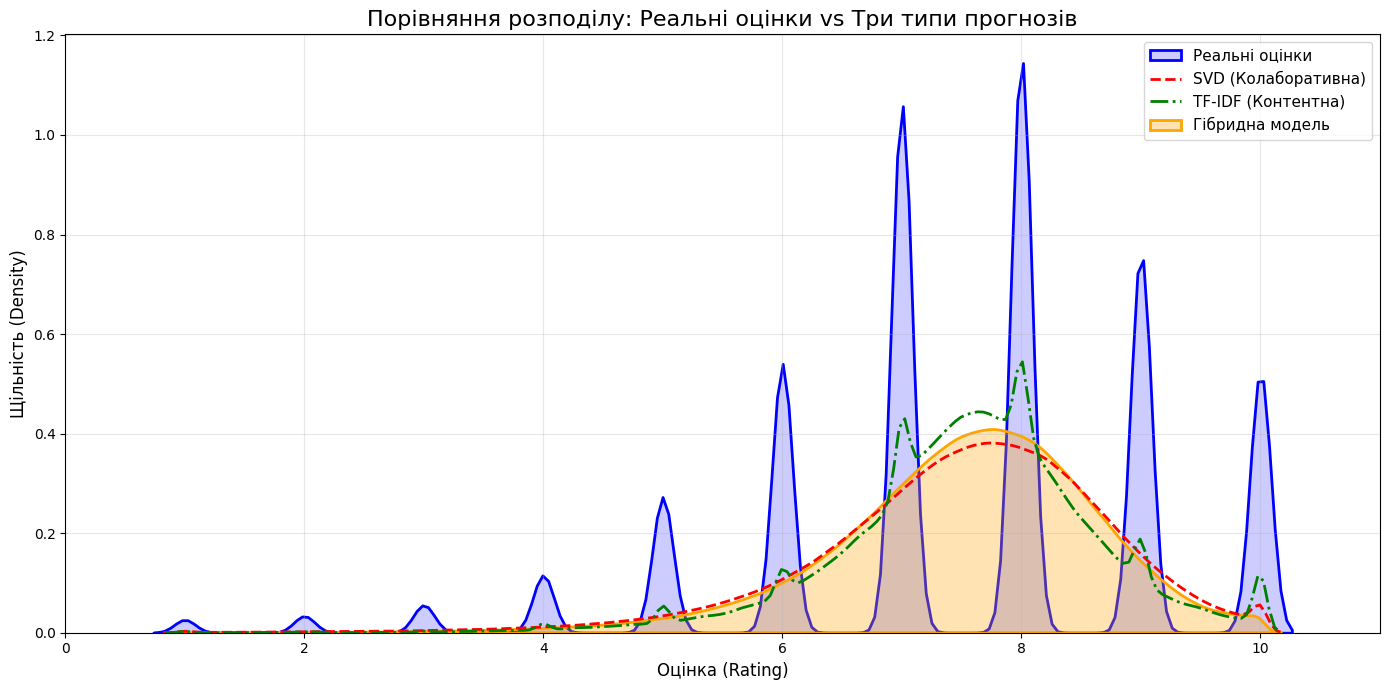

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Створюємо велике полотно для кращої видимості
plt.figure(figsize=(14, 7))

# 1. Реальні оцінки (чорна лінія з заливкою для контрасту)
sns.kdeplot(test['rating'], label='Реальні оцінки', fill=True, color="blue", alpha=0.2, linewidth=2)

# 2. Прогноз SVD (синя пунктирна лінія)
sns.kdeplot(test['svd_pred'], label='SVD (Колаборативна)', fill=False, color="red", linewidth=2, linestyle='--')

# 3. Прогноз TF-IDF (зелена штрихпунктирна лінія)
# Обов'язково додаємо .dropna(), щоб уникнути помилок через NaN
sns.kdeplot(test['content_pred'].dropna(), label='TF-IDF (Контентна)', fill=False, color="green", linewidth=2, linestyle='-.')

# 4. Гібридний прогноз (помаранчева лінія з легкою заливкою)
sns.kdeplot(test['hybrid_pred'], label='Гібридна модель', fill=True, color="orange", alpha=0.3, linewidth=2)

# Налаштування краси графіка
plt.title('Порівняння розподілу: Реальні оцінки vs Три типи прогнозів', fontsize=16)
plt.xlabel('Оцінка (Rating)', fontsize=12)
plt.ylabel('Щільність (Density)', fontsize=12)

# Обмежуємо вісь X від 0 до 11, оскільки наші оцінки лежать в межах 1-10
plt.xlim(0, 11) 

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [9]:
# Розраховуємо абсолютну помилку для кожного методу
test['svd_abs_error'] = (test['rating'] - test['svd_pred']).abs()
test['content_abs_error'] = (test['rating'] - test['content_pred']).abs()
test['hybrid_abs_error'] = (test['rating'] - test['hybrid_pred']).abs()

print("✅ Абсолютні помилки розраховано та додано до таблиці!")

# Виведемо кілька рядків, щоб побачити результат
columns_to_show = [
    'rating', 
    'svd_pred', 'svd_abs_error', 
    'content_pred', 'content_abs_error', 
    'hybrid_pred', 'hybrid_abs_error'
]

print("\n--- Приклад розрахунків (перші 5 записів) ---")
print(test[columns_to_show].head().to_string(index=False))

✅ Абсолютні помилки розраховано та додано до таблиці!

--- Приклад розрахунків (перші 5 записів) ---
 rating  svd_pred  svd_abs_error  content_pred  content_abs_error  hybrid_pred  hybrid_abs_error
      8  7.036268       0.963732      7.086447           0.913553     7.044064          0.955936
      8  8.742247       0.742247      7.161861           0.838139     8.496729          0.496729
      7  7.469710       0.469710      7.395607           0.395607     7.458198          0.458198
      9  8.519880       0.480120      7.611506           1.388494     8.378761          0.621239
      7  7.373141       0.373141      7.666783           0.666783     7.418759          0.418759


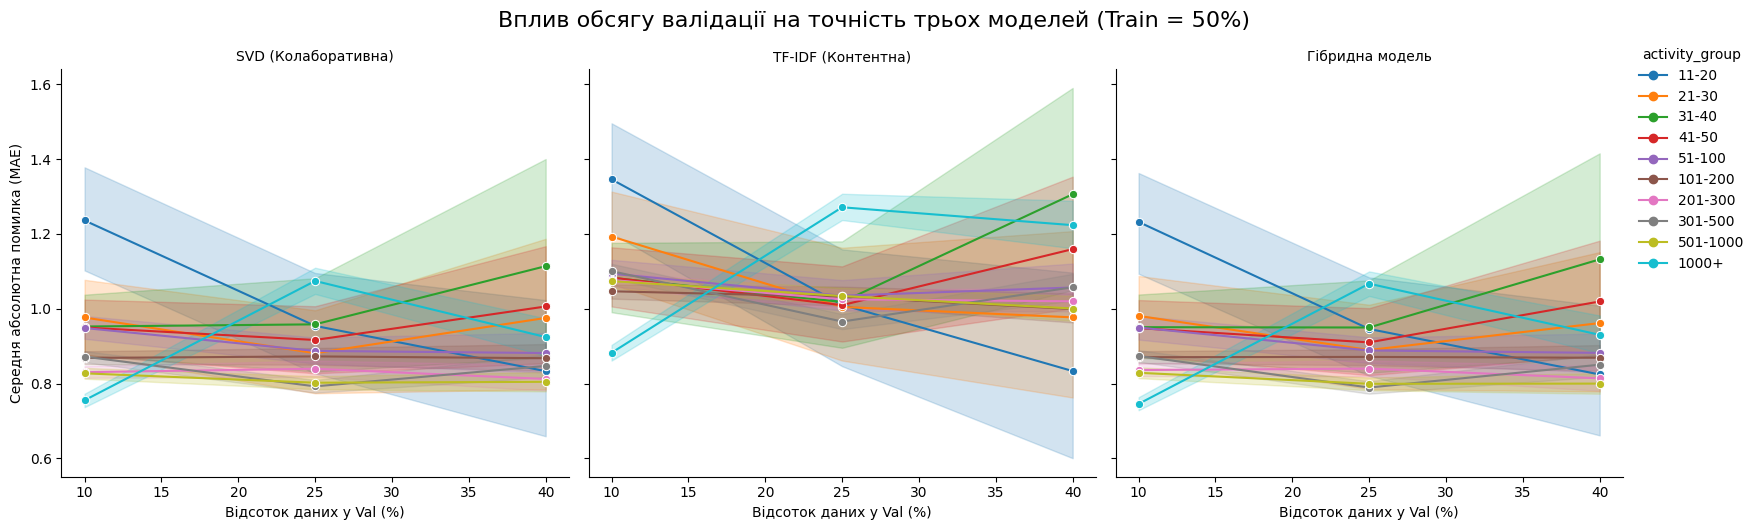

In [10]:
# 1. Фільтруємо серію B (Fixed Train)
df_series_b = test[test['series_id'] == 'B_FixedTrain'].copy()

# 2. Згортаємо дані (Melt)
# Ця функція бере наші 3 колонки з помилками і перетворює їх на дві: 
# одна колонка з назвою моделі, інша - зі значенням помилки.
df_melted = df_series_b.melt(
    id_vars=['y_pct', 'activity_group'], # Те, що залишається незмінним
    value_vars=['svd_abs_error', 'content_abs_error', 'hybrid_abs_error'], # Те, що групуємо
    var_name='model_type', 
    value_name='mae_value'
)

# 3. Робимо красиві назви для заголовків графіків
model_names = {
    'svd_abs_error': 'SVD (Колаборативна)',
    'content_abs_error': 'TF-IDF (Контентна)',
    'hybrid_abs_error': 'Гібридна модель'
}
df_melted['model_type'] = df_melted['model_type'].map(model_names)

# 4. Побудова сітки графіків (relplot = relational plot для ліній/точок)
g = sns.relplot(
    data=df_melted,
    x='y_pct',
    y='mae_value',
    hue='activity_group',
    col='model_type',   # Створюємо окремий графік для кожної моделі
    kind='line',        # Тип графіка - лінія
    marker='o',
    height=5,           # Висота кожного графіка
    aspect=1.1,         # Пропорція ширини до висоти
    facet_kws={'sharey': True} # Важливо: спільна вісь Y для чесного порівняння висоти помилки
)

# 5. Налаштування краси
g.set_axis_labels("Відсоток даних у Val (%)", "Середня абсолютна помилка (MAE)")
g.set_titles("{col_name}") 
g.fig.suptitle('Вплив обсягу валідації на точність трьох моделей (Train = 50%)', y=1.05, fontsize=16)

# Переміщуємо легенду трохи зручніше
sns.move_legend(g, "upper right", bbox_to_anchor=(1, 1))

plt.show()

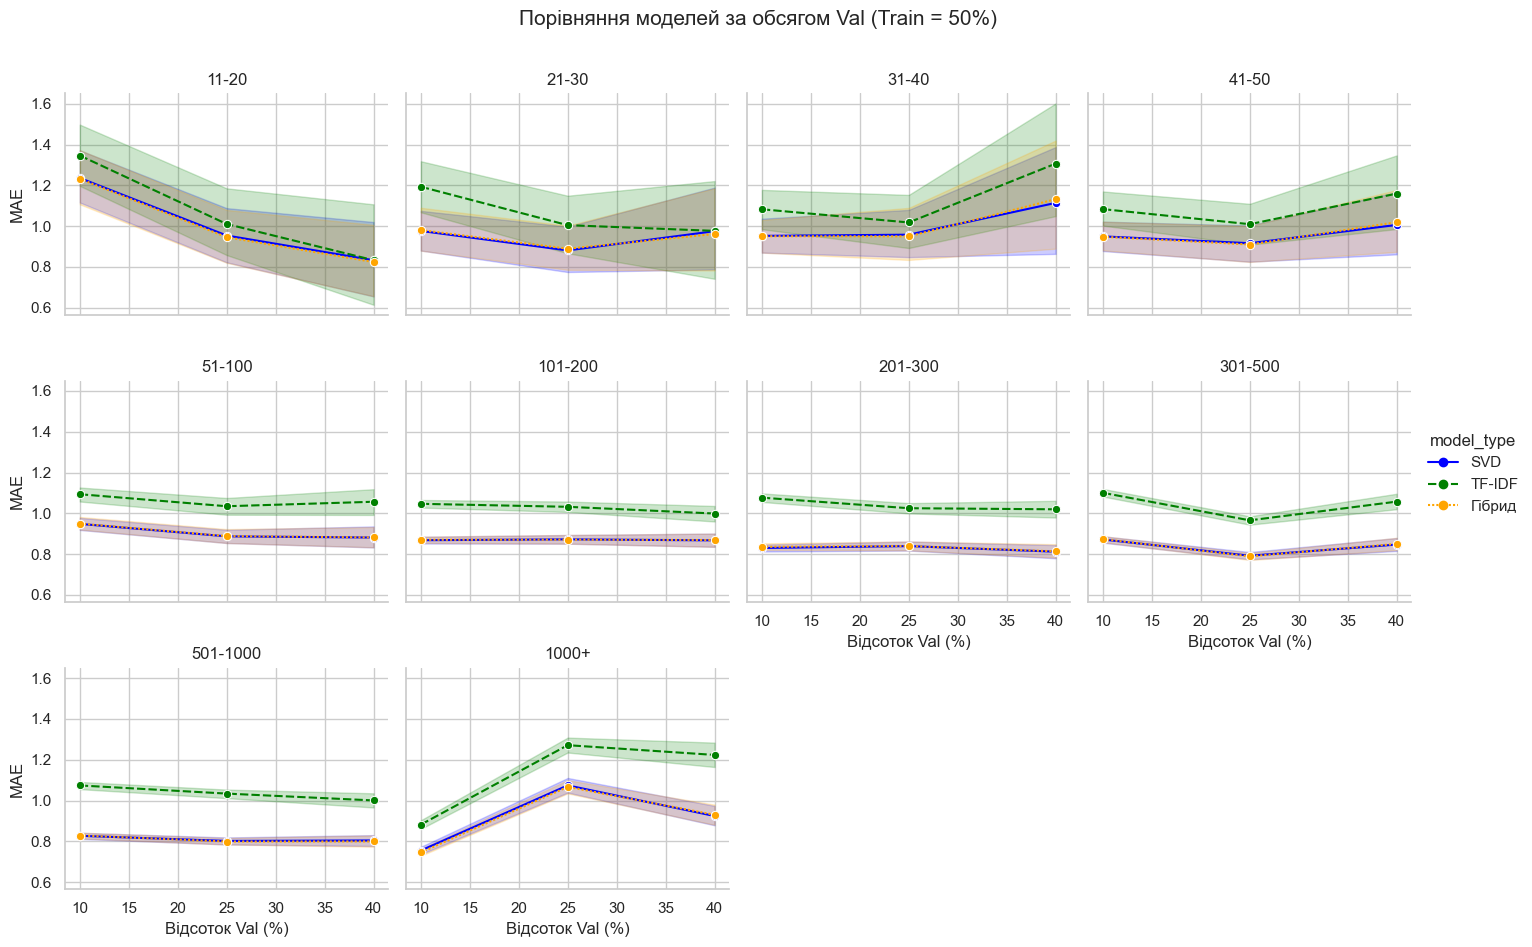

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю
sns.set_theme(style="whitegrid")

# Якщо ви ще не зберегли df_melted з попереднього кроку, ось його створення:
# (якщо він вже є, цей крок просто оновить його)
df_melted = df_series_b.melt(
    id_vars=['y_pct', 'activity_group'], 
    value_vars=['svd_abs_error', 'content_abs_error', 'hybrid_abs_error'], 
    var_name='model_type', 
    value_name='mae_value'
)

# Перейменовуємо для красивої легенди
model_names = {
    'svd_abs_error': 'SVD',
    'content_abs_error': 'TF-IDF',
    'hybrid_abs_error': 'Гібрид'
}
df_melted['model_type'] = df_melted['model_type'].map(model_names)

# Створення фасетної сітки за допомогою relplot
g = sns.relplot(
    data=df_melted, 
    x="y_pct", 
    y="mae_value", 
    col="activity_group", # Кожна група активності — окремий підграфік
    hue="model_type",     # РІЗНІ КОЛЬОРИ для різних моделей!
    style="model_type",   # Додаємо різні типи ліній/маркерів для ще кращої відмінності
    kind="line",          # Малюємо лінії
    marker="o", 
    col_wrap=4,           # по 4 графіки в рядку
    height=3, 
    aspect=1.2,
    facet_kws={'sharey': True}, # Спільна шкала Y для чесного порівняння
    palette=["blue", "green", "orange"] # Задаємо власні кольори (SVD, Content, Hybrid)
)

# Налаштування підписів
g.set_axis_labels("Відсоток Val (%)", "MAE")
g.set_titles("{col_name}") # Прибираємо зайвий текст "activity_group =" з заголовків

# Загальний заголовок
g.fig.suptitle('Порівняння моделей за обсягом Val (Train = 50%)', y=1.05, fontsize=15)

plt.show()

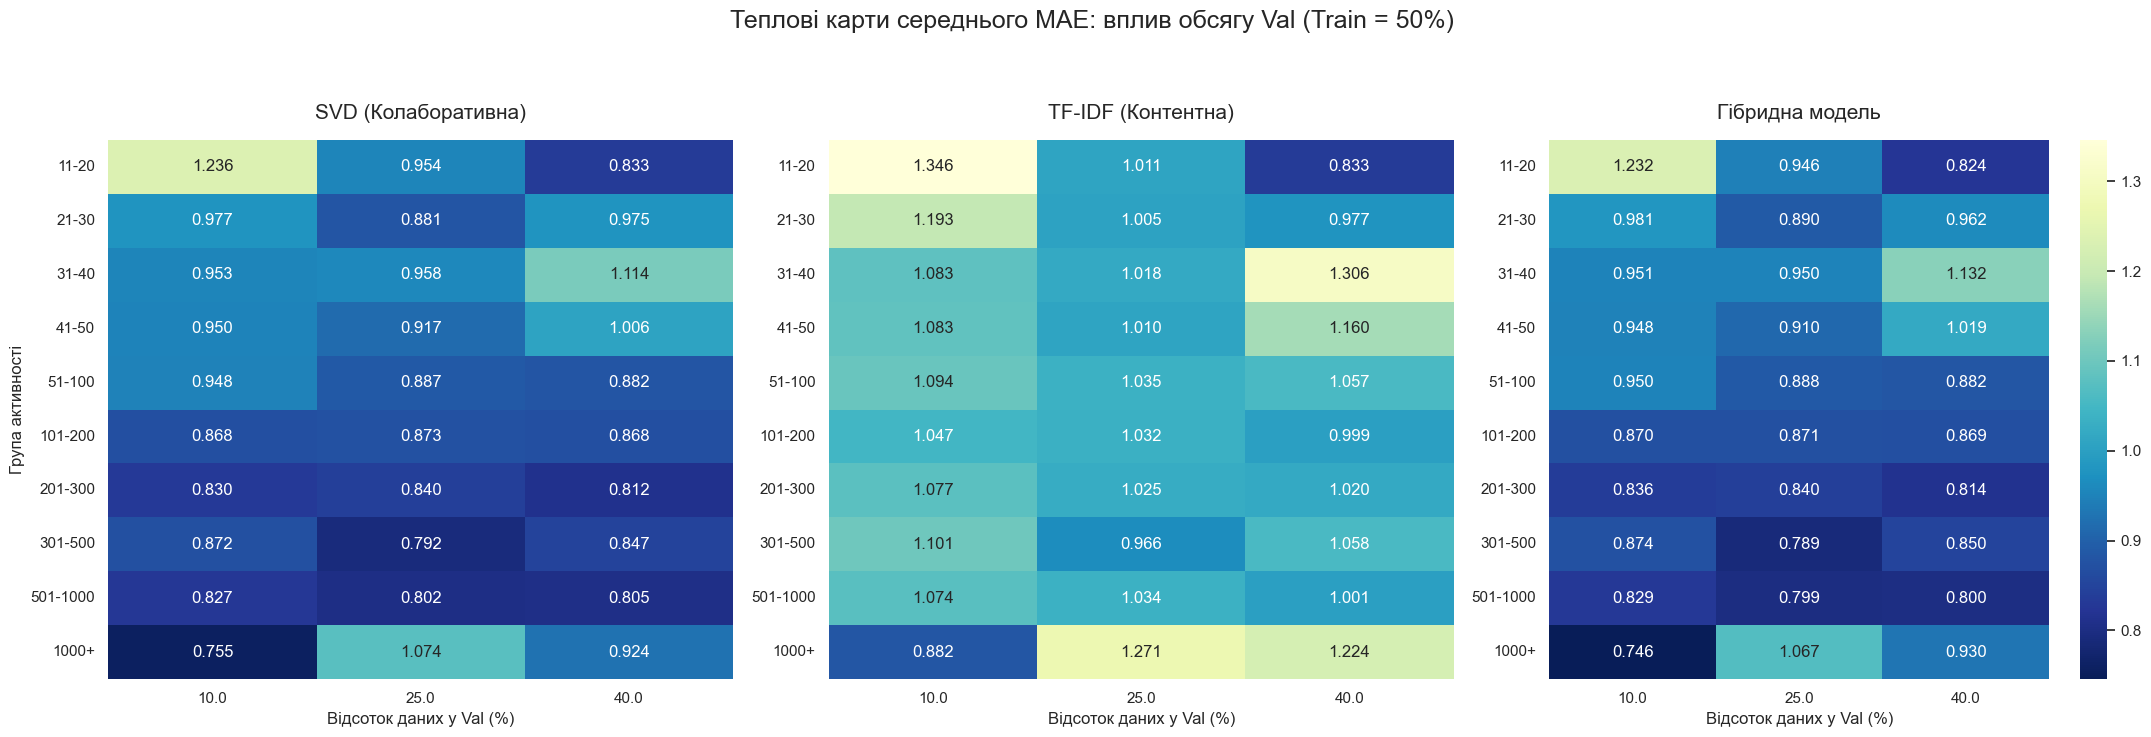

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Визначаємо наші колонки з помилками та заголовки для графіків
models = [
    ('svd_abs_error', 'SVD (Колаборативна)'),
    ('content_abs_error', 'TF-IDF (Контентна)'),
    ('hybrid_abs_error', 'Гібридна модель')
]

# 1. Знаходимо глобальний мінімум та максимум для Спільної Кольорової Шкали
all_means = []
for col, _ in models:
    pt = df_series_b.pivot_table(index='activity_group', columns='y_pct', values=col, aggfunc='mean')
    all_means.extend([pt.values.min(), pt.values.max()])

global_vmin = min(all_means)
global_vmax = max(all_means)

# 2. Створюємо полотно для 3 графіків поруч (1 рядок, 3 колонки)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 3. Будуємо теплові карти в циклі
for i, (col, title) in enumerate(models):
    
    # Готуємо дані для конкретної моделі
    heatmap_data = df_series_b.pivot_table(
        index='activity_group', 
        columns='y_pct', 
        values=col, 
        aggfunc='mean'
    )
    
    # Малюємо heatmap на відповідному підграфіку (ax=axes[i])
    sns.heatmap(
        heatmap_data, 
        annot=True, 
        fmt=".3f", 
        cmap="YlGnBu_r", # Перевернута шкала: чим світліше, тим менша помилка
        vmin=global_vmin, 
        vmax=global_vmax,
        cbar=(i == 2),   # Показуємо кольорову лінійку ТІЛЬКИ біля останнього графіка
        ax=axes[i]
    )
    
    # Налаштування підписів
    axes[i].set_title(title, fontsize=15, pad=15)
    axes[i].set_xlabel("Відсоток даних у Val (%)", fontsize=12)
    
    # Залишаємо вісь Y (Групи) тільки для першого графіка, щоб не дублювати
    if i == 0:
        axes[i].set_ylabel("Група активності", fontsize=12)
    else:
        axes[i].set_ylabel("")

# Загальний заголовок
plt.suptitle("Теплові карти середнього MAE: вплив обсягу Val (Train = 50%)", fontsize=18, y=1.05)
plt.tight_layout()

plt.show()

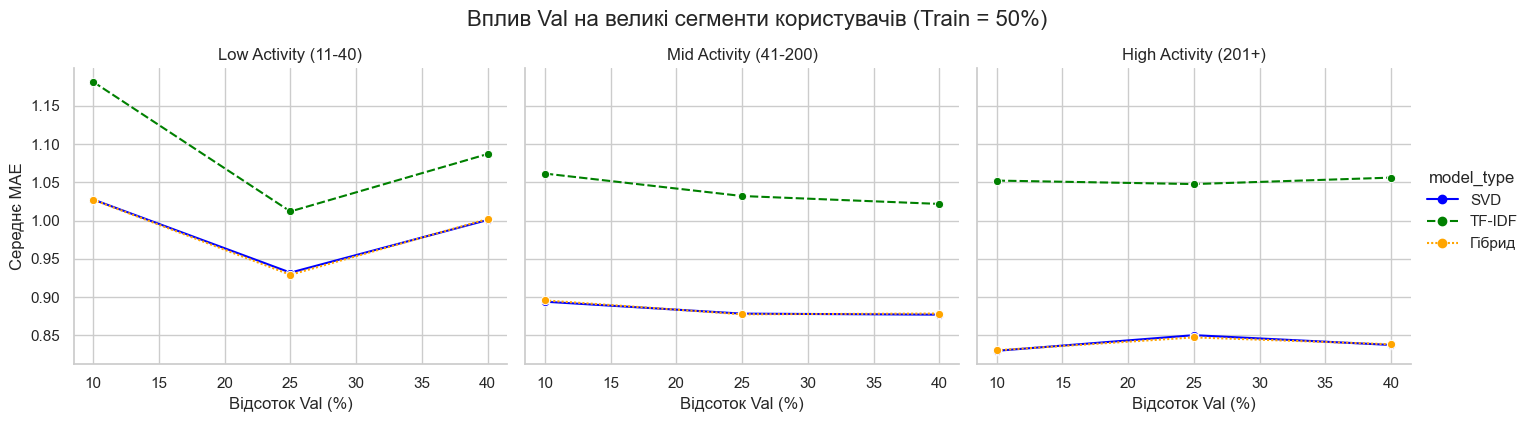

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ваша функція агрегації (трохи уточнив назви для графіків)
def aggregate_groups(group):
    if group in ['11-20', '21-30', '31-40']: 
        return 'Low Activity (11-40)'
    elif group in ['41-50', '51-100', '101-200']: 
        return 'Mid Activity (41-200)'
    else: 
        return 'High Activity (201+)'

# Додаємо колонку broad_group у датафрейм
df_series_b['broad_group'] = df_series_b['activity_group'].apply(aggregate_groups)

# 2. Згортаємо дані (Melt), тепер обов'язково зберігаючи broad_group
df_melted_broad = df_series_b.melt(
    id_vars=['y_pct', 'broad_group'],  # Зберігаємо відсоток та макро-групу
    value_vars=['svd_abs_error', 'content_abs_error', 'hybrid_abs_error'], 
    var_name='model_type', 
    value_name='mae_value'
)

# Перейменовуємо для легенди
model_names = {
    'svd_abs_error': 'SVD',
    'content_abs_error': 'TF-IDF',
    'hybrid_abs_error': 'Гібрид'
}
df_melted_broad['model_type'] = df_melted_broad['model_type'].map(model_names)

# 3. Побудова графіка
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df_melted_broad, 
    x='y_pct', 
    y='mae_value', 
    col='broad_group',    # Розбиваємо на 3 підграфіки за активністю
    col_order=['Low Activity (11-40)', 'Mid Activity (41-200)', 'High Activity (201+)'], # Правильний порядок
    hue='model_type',     # Різні кольори для моделей
    style='model_type',   # Різні типи ліній
    kind='line', 
    marker='o',
    errorbar=None,        # Прибираємо "тіні" (ci=None в нових версіях), щоб лінії були чіткими
    height=4,
    aspect=1.2,
    palette=["blue", "green", "orange"] # Наші фірмові кольори моделей
)

# Налаштування краси
g.set_axis_labels("Відсоток Val (%)", "Середнє MAE")
g.set_titles("{col_name}") 
g.fig.suptitle("Вплив Val на великі сегменти користувачів (Train = 50%)", y=1.05, fontsize=16)

plt.show()

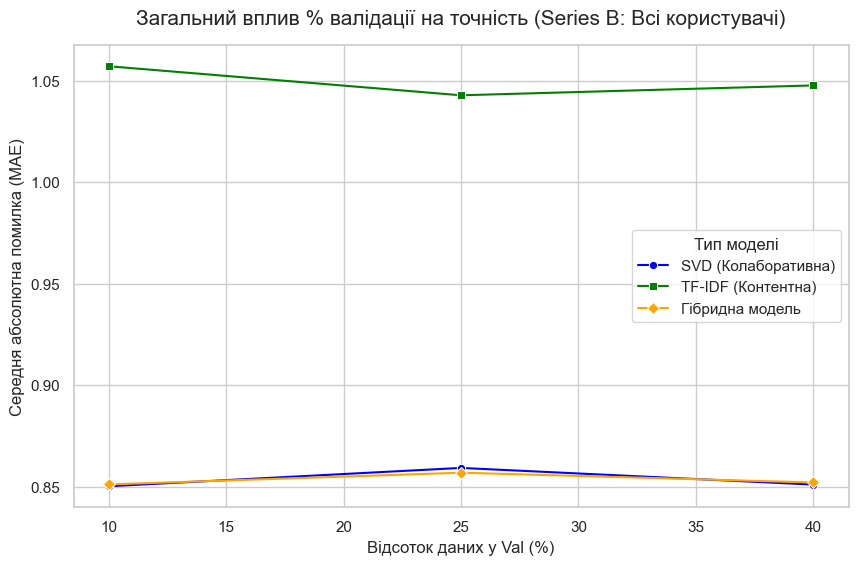

In [14]:
# 1. Згортаємо дані (беремо тільки y_pct та 3 колонки з помилками)
df_melted_all = df_series_b.melt(
    id_vars=['y_pct'], 
    value_vars=['svd_abs_error', 'content_abs_error', 'hybrid_abs_error'], 
    var_name='model_type', 
    value_name='mae_value'
)

# Робимо красиві назви для легенди
model_names = {
    'svd_abs_error': 'SVD (Колаборативна)',
    'content_abs_error': 'TF-IDF (Контентна)',
    'hybrid_abs_error': 'Гібридна модель'
}
df_melted_all['model_type'] = df_melted_all['model_type'].map(model_names)

# 2. Налаштування полотна
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Побудова графіка
# Seaborn автоматично порахує середнє значення (mean) помилки для всіх користувачів на кожному кроці y_pct
sns.lineplot(
    data=df_melted_all, 
    x='y_pct', 
    y='mae_value', 
    hue='model_type',    # Розбиваємо на різні кольори
    style='model_type',  # Додаємо різні типи маркерів
    markers=["o", "s", "D"], # Кружечок, квадрат, ромб
    dashes=False,        # Робимо лінії суцільними
    palette=["blue", "green", "orange"], # Наші стандартні кольори
    errorbar=None        # Прибираємо "тіні" довірчих інтервалів для чіткості ліній
)

# 4. Налаштування краси
plt.title('Загальний вплив % валідації на точність (Series B: Всі користувачі)', fontsize=15, pad=15)
plt.xlabel('Відсоток даних у Val (%)', fontsize=12)
plt.ylabel('Середня абсолютна помилка (MAE)', fontsize=12)

# Розташування легенди
plt.legend(title='Тип моделі', fontsize=11, title_fontsize=12)

plt.show()

In [15]:
['svd_abs_error', 'content_abs_error', 'hybrid_abs_error']

['svd_abs_error', 'content_abs_error', 'hybrid_abs_error']

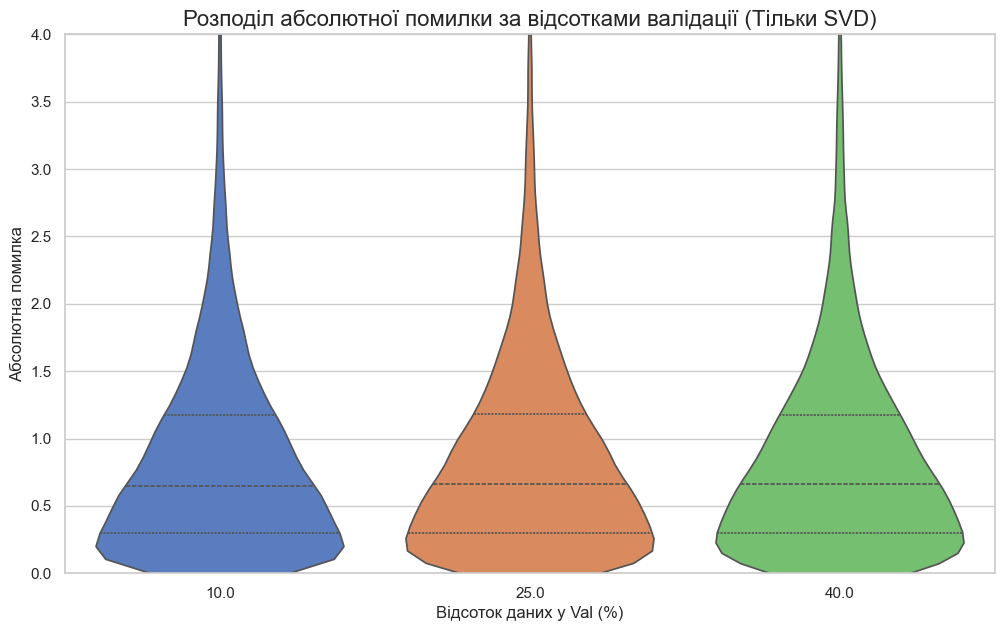

In [16]:
plt.figure(figsize=(12, 7))
sns.violinplot(
    data=df_series_b, 
    x='y_pct', 
    y='svd_abs_error', 
    hue='y_pct', # додаємо для кольору
    inner="quartile", # покаже медіану та квартилі
    palette="muted",
    legend=False
)
plt.title('Розподіл абсолютної помилки за відсотками валідації (Тільки SVD)', fontsize=16)
plt.xlabel('Відсоток даних у Val (%)')
plt.ylabel('Абсолютна помилка')
plt.ylim(0, 4) # фокусуємося на основній масі помилок
plt.show()

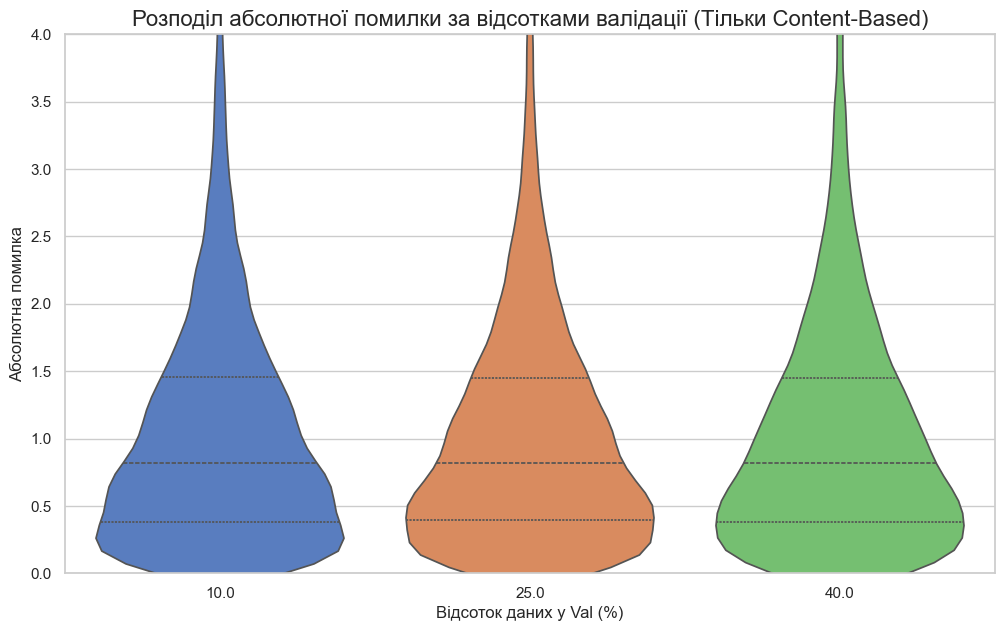

In [17]:
plt.figure(figsize=(12, 7))
sns.violinplot(
    data=df_series_b, 
    x='y_pct', 
    y='content_abs_error', 
    hue='y_pct', # додаємо для кольору
    inner="quartile", # покаже медіану та квартилі
    palette="muted",
    legend=False
)
plt.title('Розподіл абсолютної помилки за відсотками валідації (Тільки Content-Based)', fontsize=16)
plt.xlabel('Відсоток даних у Val (%)')
plt.ylabel('Абсолютна помилка')
plt.ylim(0, 4) # фокусуємося на основній масі помилок
plt.show()

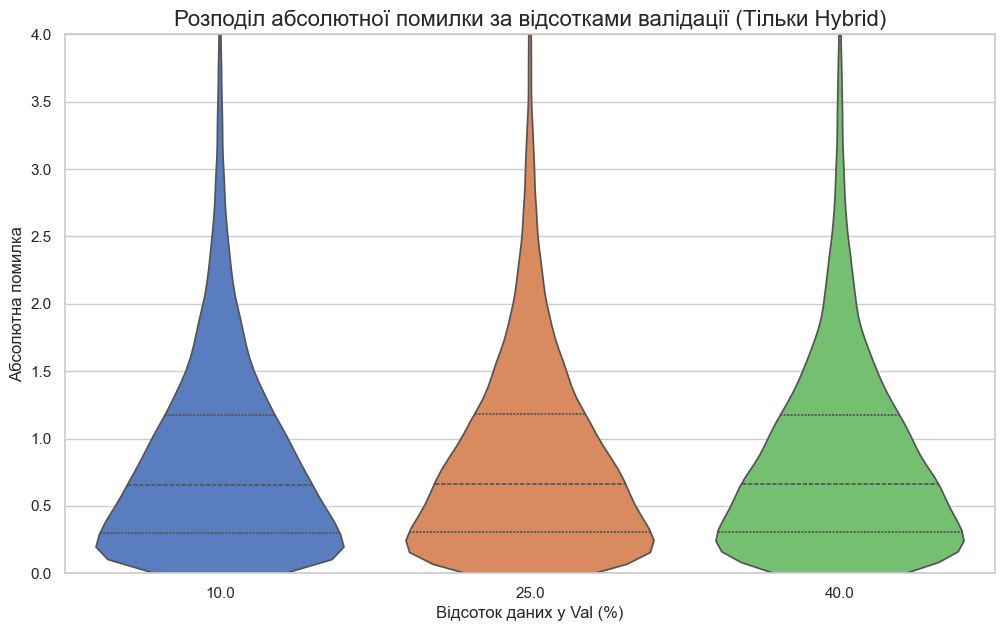

In [18]:
plt.figure(figsize=(12, 7))
sns.violinplot(
    data=df_series_b, 
    x='y_pct', 
    y='hybrid_abs_error', 
    hue='y_pct', # додаємо для кольору
    inner="quartile", # покаже медіану та квартилі
    palette="muted",
    legend=False
)
plt.title('Розподіл абсолютної помилки за відсотками валідації (Тільки Hybrid)', fontsize=16)
plt.xlabel('Відсоток даних у Val (%)')
plt.ylabel('Абсолютна помилка')
plt.ylim(0, 4) # фокусуємося на основній масі помилок
plt.show()

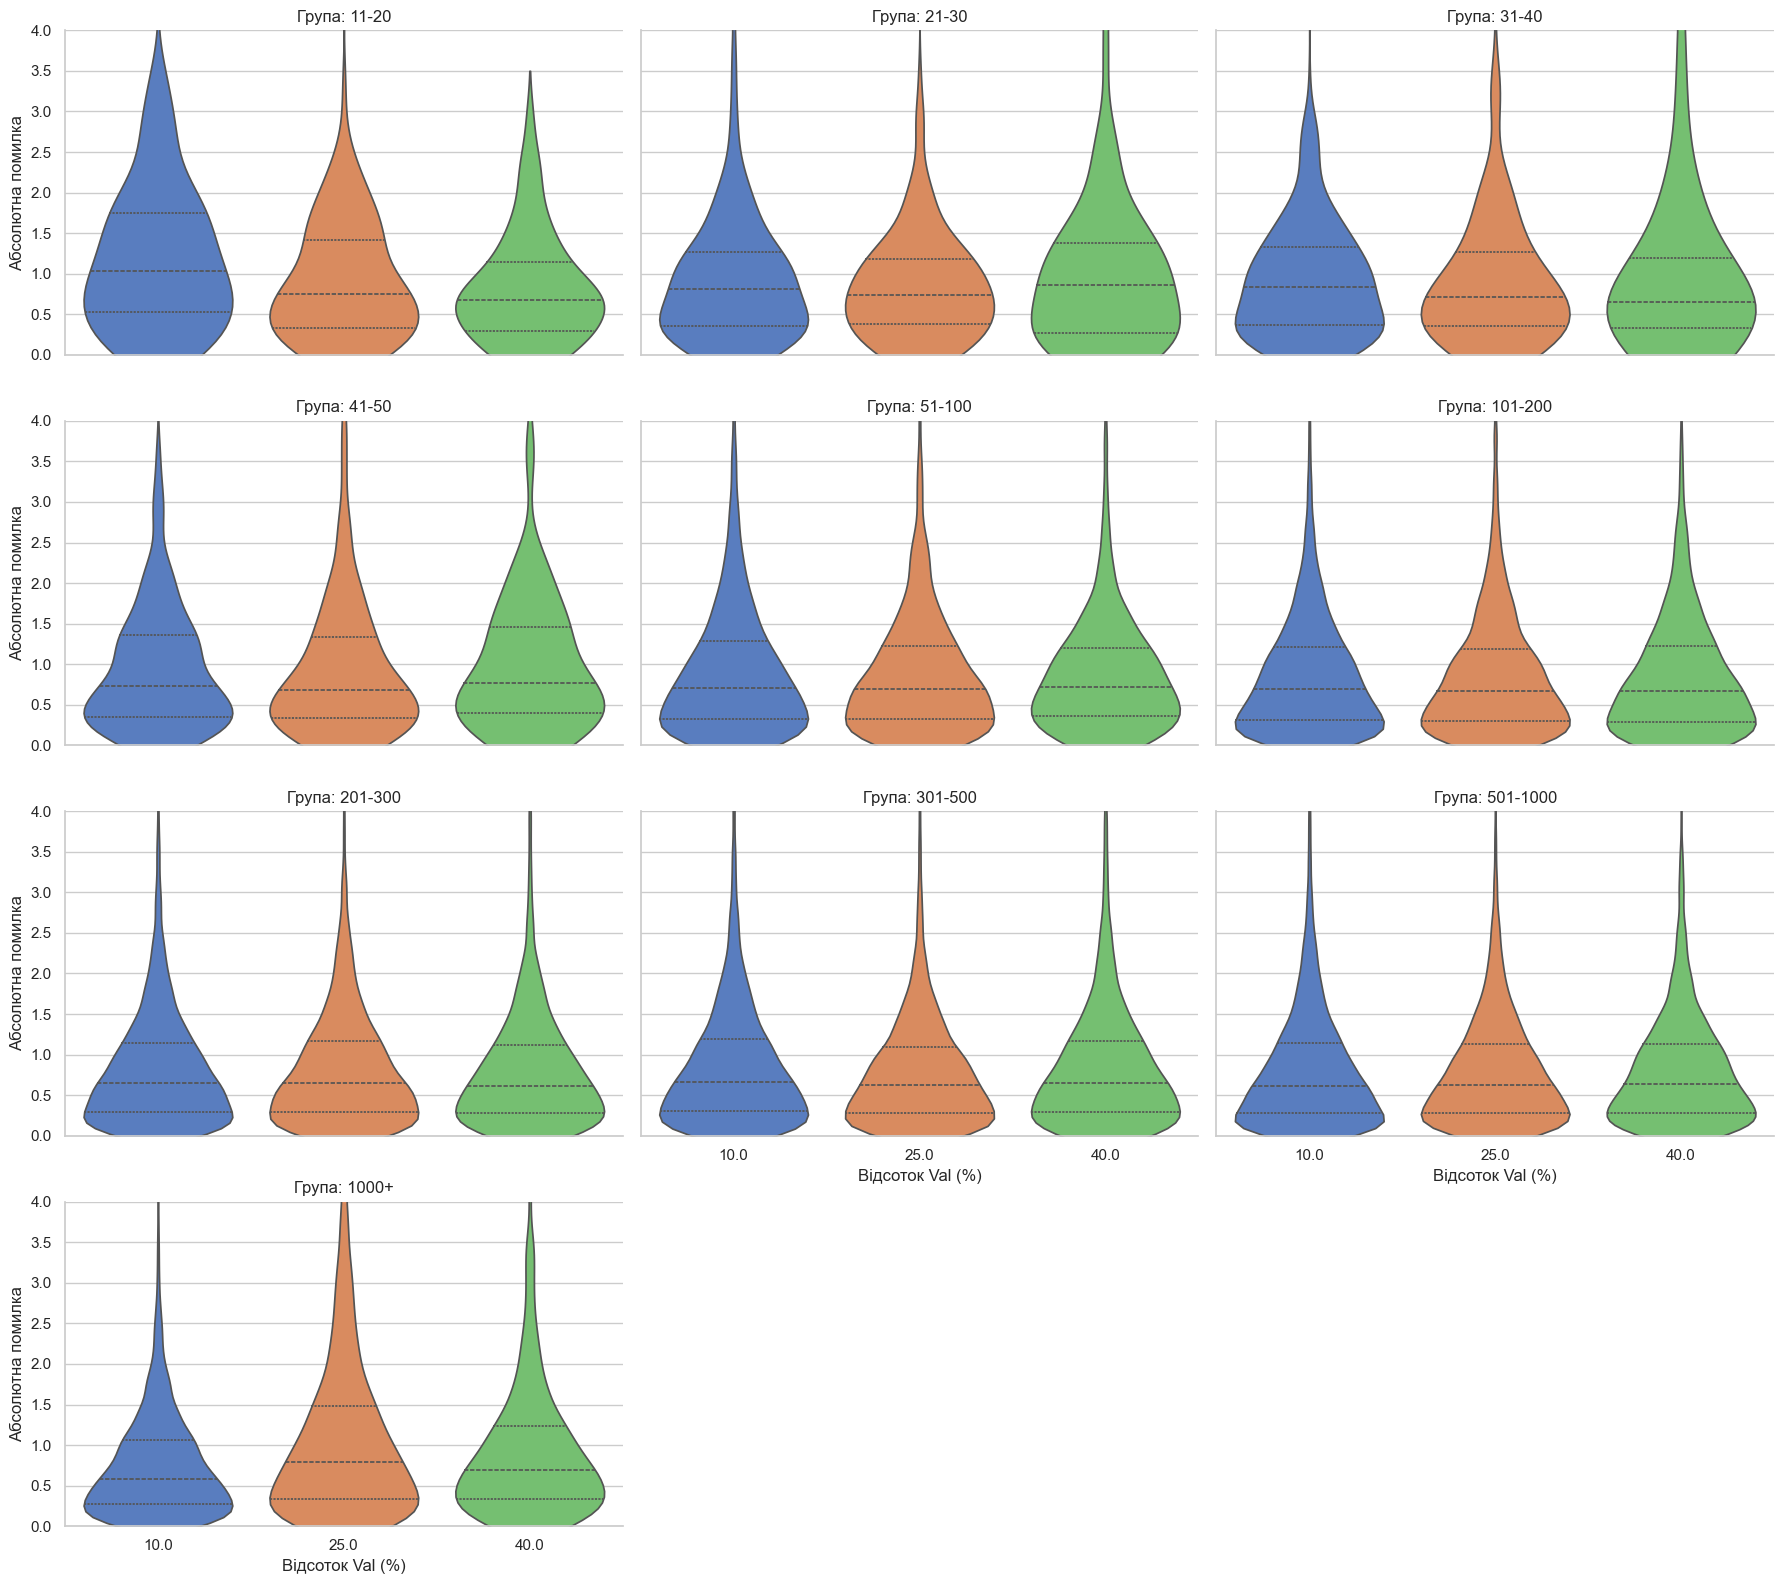

In [19]:
# Налаштовуємо стиль
sns.set_theme(style="whitegrid")

# Створюємо сітку: по 3-4 групи в рядку
g = sns.FacetGrid(
    df_series_b, 
    col="activity_group", 
    col_wrap=3, 
    height=4, 
    aspect=1.5,
    sharey=True # Залишаємо спільну шкалу для порівняння груп між собою
)

# Малюємо скрипки
g.map_dataframe(
    sns.violinplot, 
    x="y_pct", 
    y="svd_abs_error", 
    hue="y_pct",
    inner="quartile",
    palette="muted",
    legend=False
)

# Налаштування осей та заголовків
g.set_axis_labels("Відсоток Val (%)", "Абсолютна помилка")
g.set_titles(col_template="Група: {col_name}")

# Обмежуємо Y до 4.0, щоб бачити деталі (більшість помилок там)
plt.ylim(0, 4)
plt.tight_layout()
plt.show()

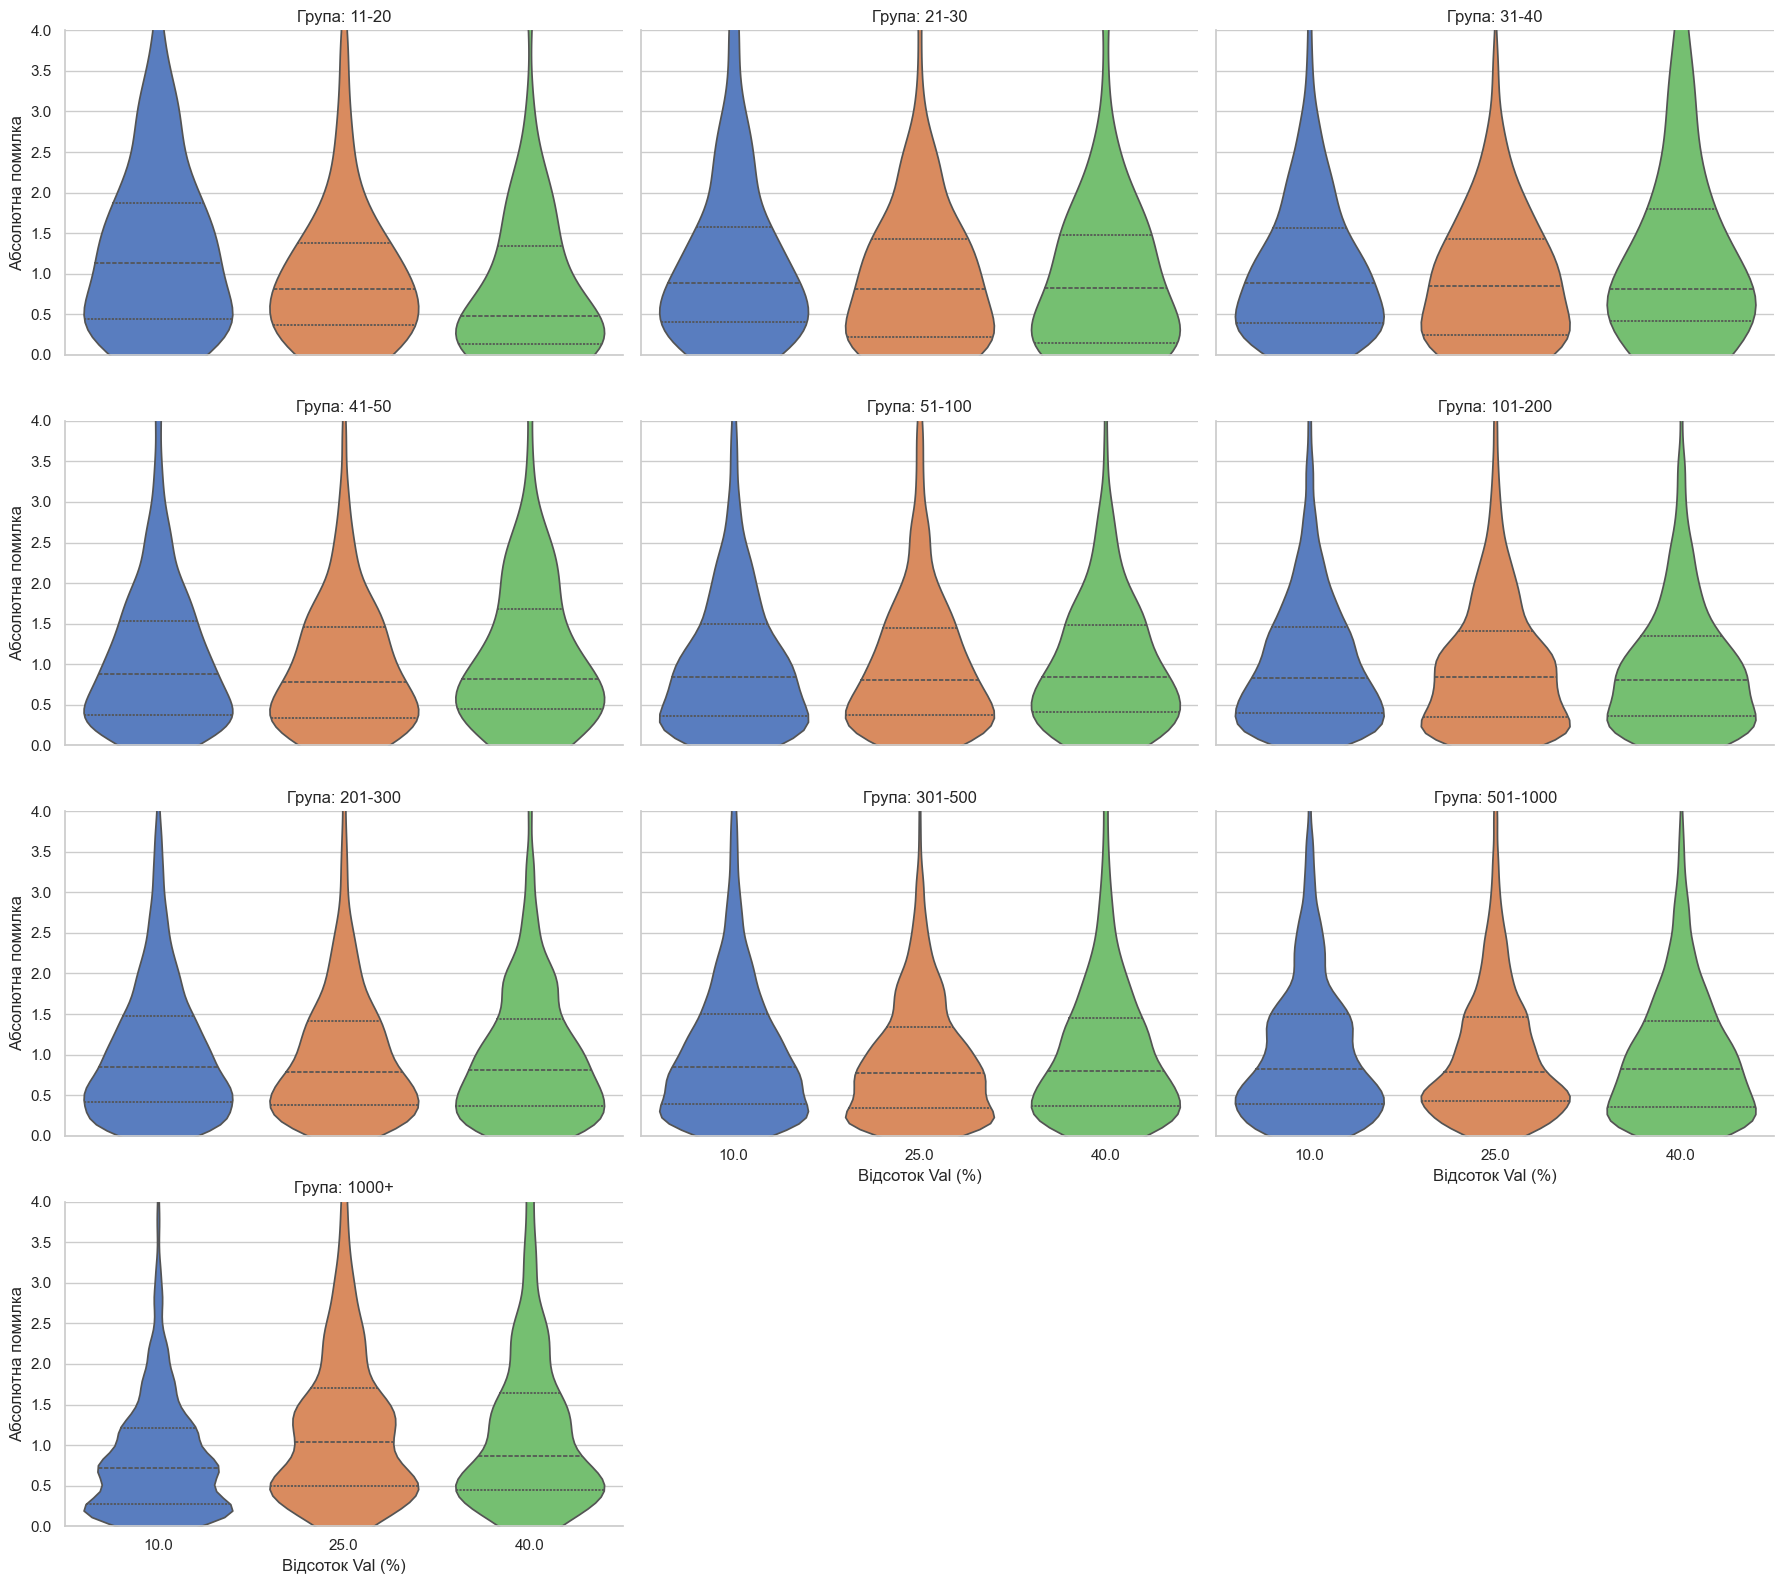

In [20]:
# Налаштовуємо стиль
sns.set_theme(style="whitegrid")

# Створюємо сітку: по 3-4 групи в рядку
g = sns.FacetGrid(
    df_series_b, 
    col="activity_group", 
    col_wrap=3, 
    height=4, 
    aspect=1.5,
    sharey=True # Залишаємо спільну шкалу для порівняння груп між собою
)

# Малюємо скрипки
g.map_dataframe(
    sns.violinplot, 
    x="y_pct", 
    y="content_abs_error", 
    hue="y_pct",
    inner="quartile",
    palette="muted",
    legend=False
)

# Налаштування осей та заголовків
g.set_axis_labels("Відсоток Val (%)", "Абсолютна помилка")
g.set_titles(col_template="Група: {col_name}")

# Обмежуємо Y до 4.0, щоб бачити деталі (більшість помилок там)
plt.ylim(0, 4)
plt.tight_layout()
plt.show()

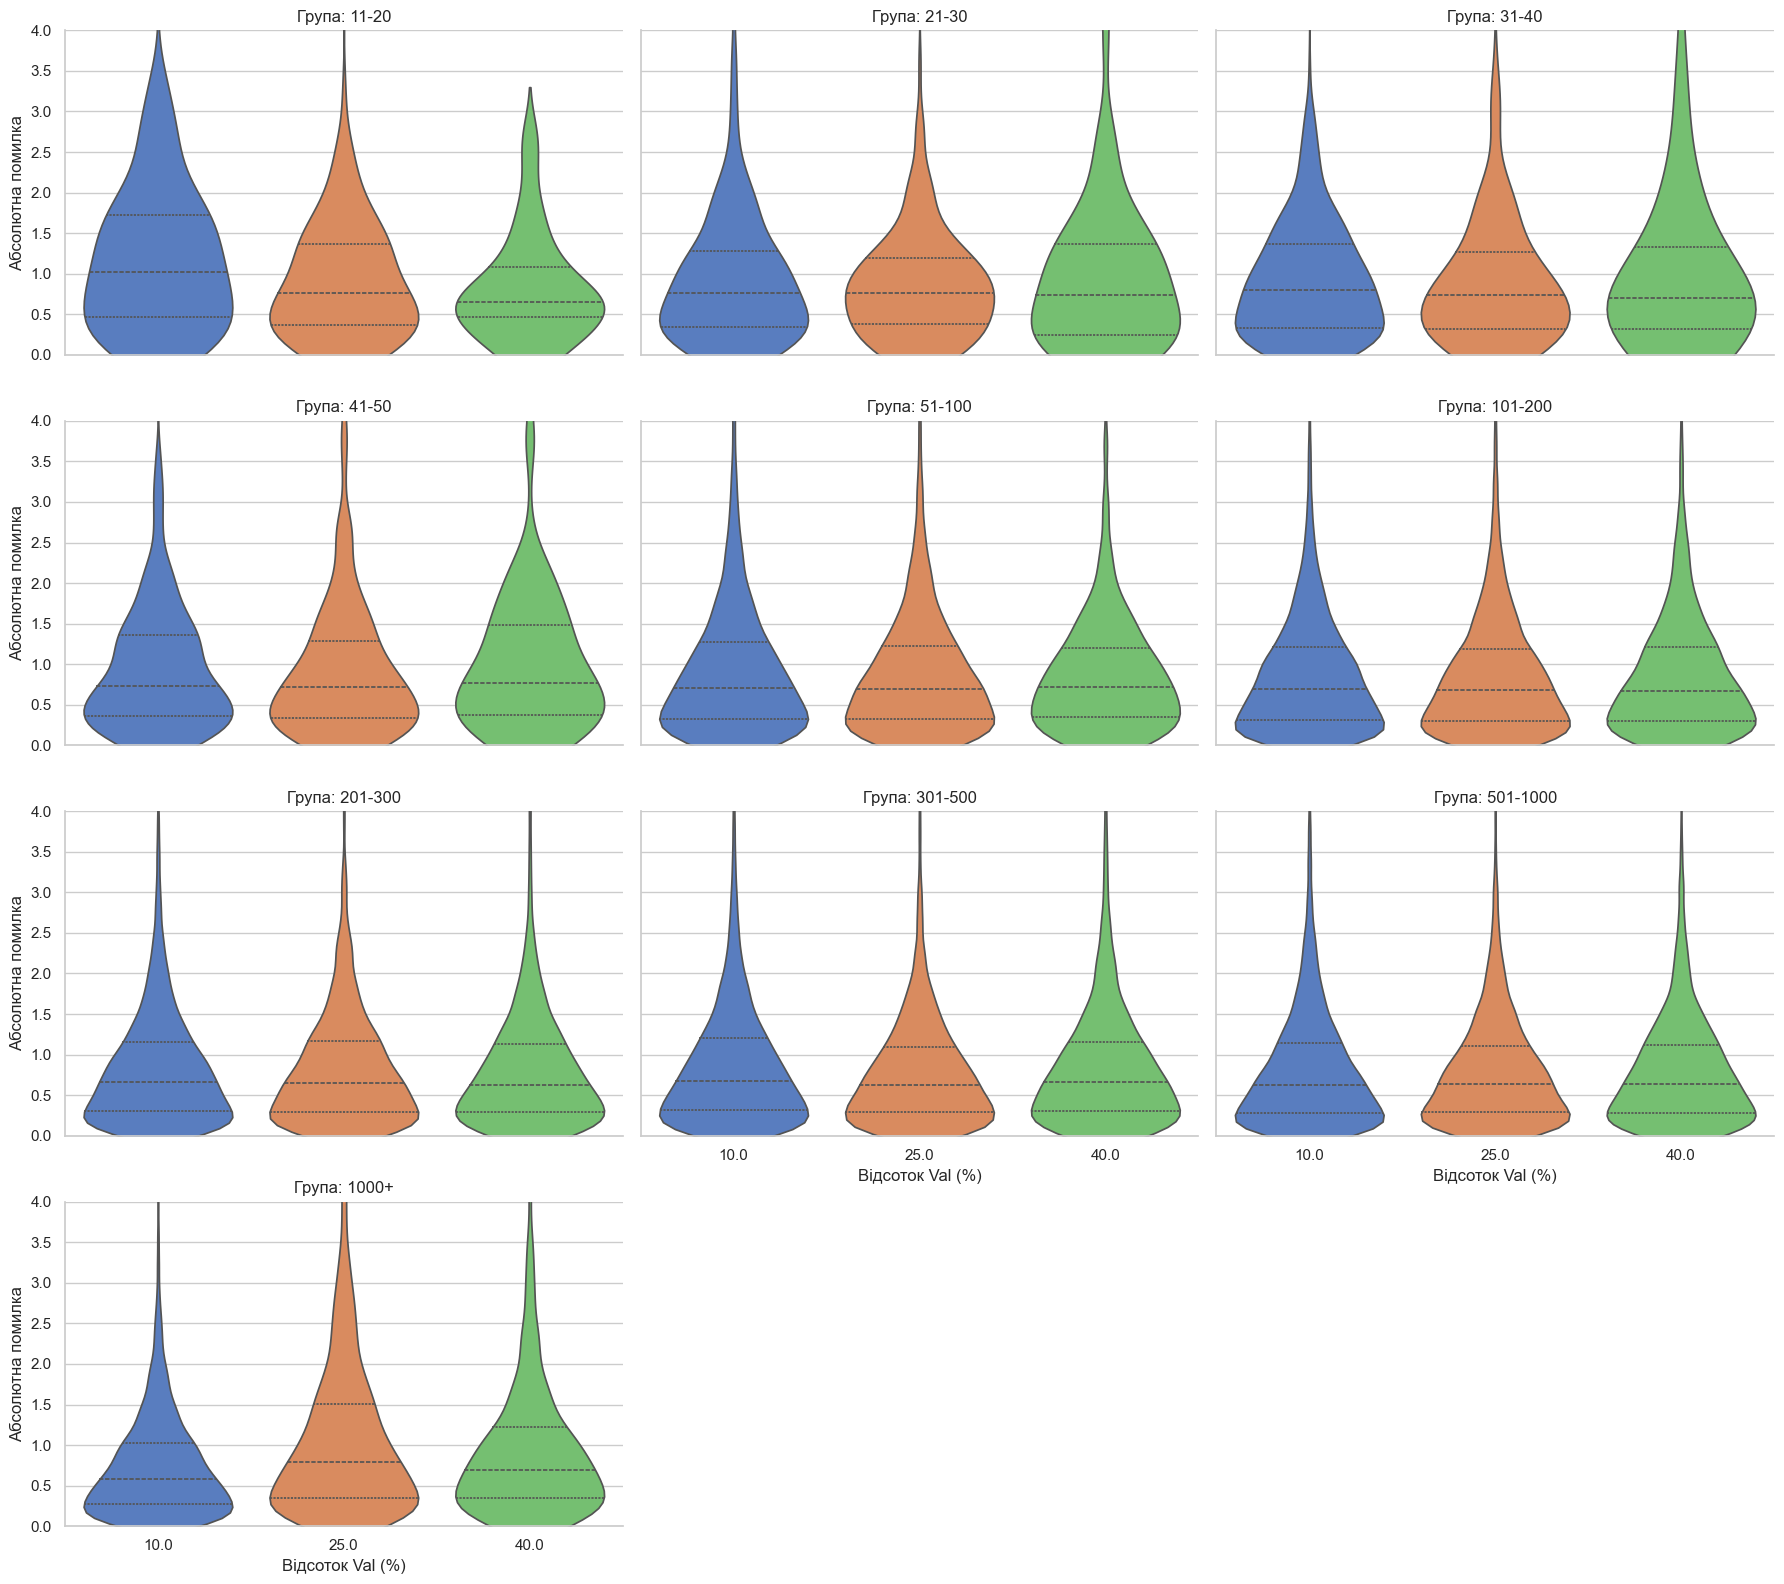

In [21]:
# Налаштовуємо стиль
sns.set_theme(style="whitegrid")

# Створюємо сітку: по 3-4 групи в рядку
g = sns.FacetGrid(
    df_series_b, 
    col="activity_group", 
    col_wrap=3, 
    height=4, 
    aspect=1.5,
    sharey=True # Залишаємо спільну шкалу для порівняння груп між собою
)

# Малюємо скрипки
g.map_dataframe(
    sns.violinplot, 
    x="y_pct", 
    y="hybrid_abs_error", 
    hue="y_pct",
    inner="quartile",
    palette="muted",
    legend=False
)

# Налаштування осей та заголовків
g.set_axis_labels("Відсоток Val (%)", "Абсолютна помилка")
g.set_titles(col_template="Група: {col_name}")

# Обмежуємо Y до 4.0, щоб бачити деталі (більшість помилок там)
plt.ylim(0, 4)
plt.tight_layout()
plt.show()

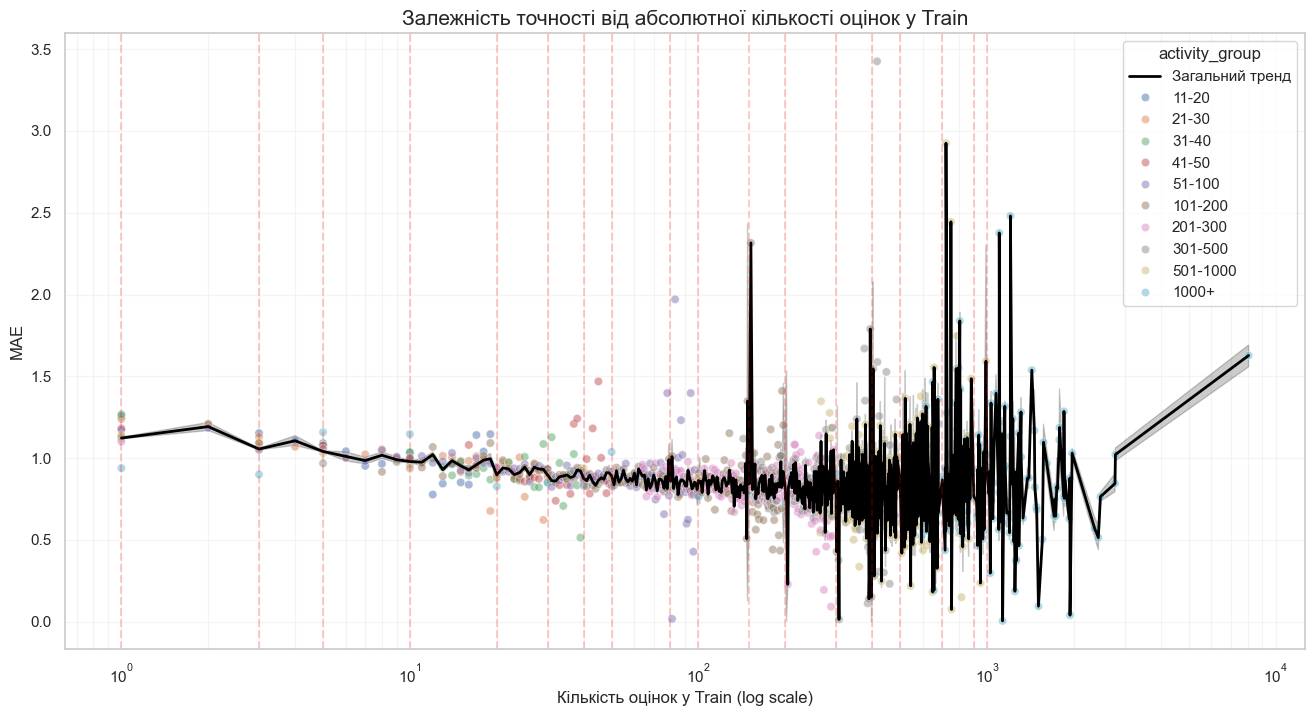

In [22]:
# Фільтруємо основний тест (без експериментальних серій)
df_main_test = test[test['series_id'].isna()].copy()

# Список ваших референтних значень для виділення на графіку
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

plt.figure(figsize=(16, 8))

# Будуємо загальну лінію тренду
sns.lineplot(data=df_main_test, x='train_count', y='svd_abs_error', color='black', linewidth=2, label='Загальний тренд')

# Додаємо точки для кожної групи активності
sns.scatterplot(
    data=df_main_test.groupby(['train_count', 'activity_group'])['svd_abs_error'].mean().reset_index(),
    x='train_count', y='svd_abs_error', hue='activity_group', alpha=0.5
)

# Виділяємо референтні кількості вертикальними лініями
for ref in ref_counts:
    if ref <= df_main_test['train_count'].max():
        plt.axvline(x=ref, color='red', linestyle='--', alpha=0.2)

plt.xscale('log') # Логарифмічна шкала краще показує різницю між 1 та 10 оцінками
plt.title('Залежність точності від абсолютної кількості оцінок у Train', fontsize=15)
plt.xlabel('Кількість оцінок у Train (log scale)', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

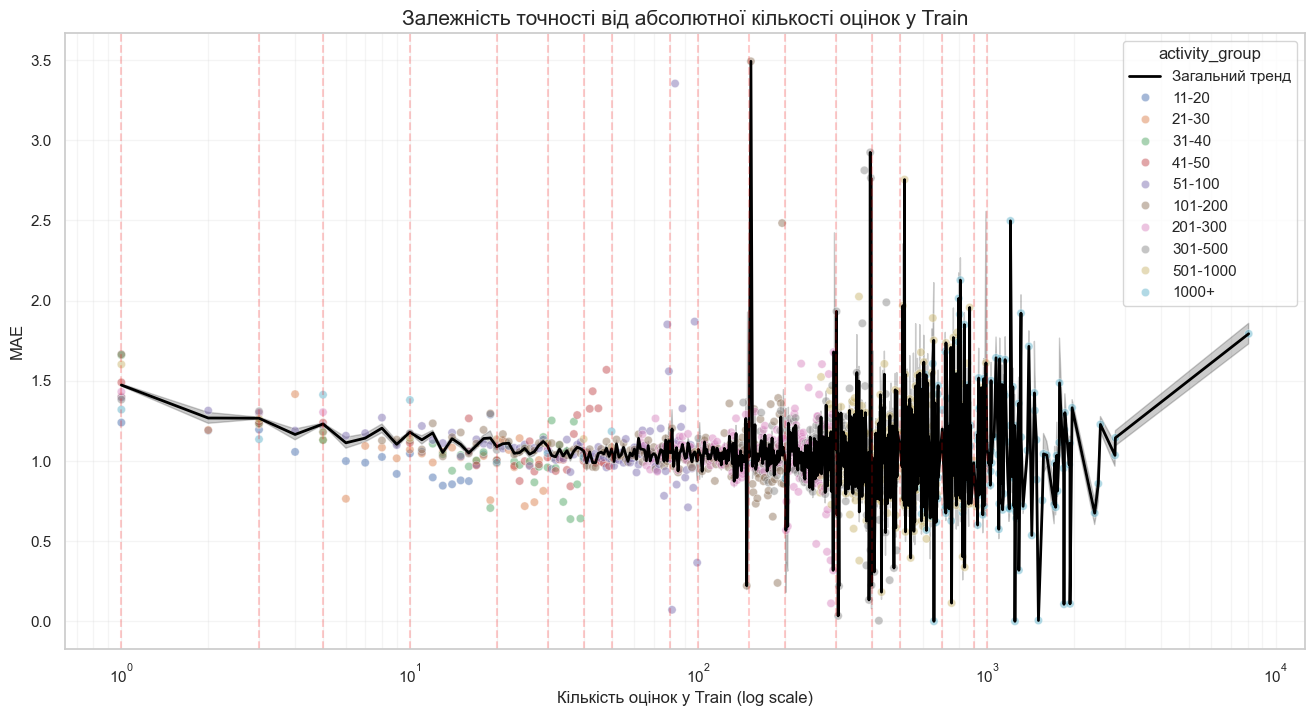

In [23]:
# Фільтруємо основний тест (без експериментальних серій)
df_main_test = test[test['series_id'].isna()].copy()

# Список ваших референтних значень для виділення на графіку
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

plt.figure(figsize=(16, 8))

# Будуємо загальну лінію тренду
sns.lineplot(data=df_main_test, x='train_count', y='content_abs_error', color='black', linewidth=2, label='Загальний тренд')

# Додаємо точки для кожної групи активності
sns.scatterplot(
    data=df_main_test.groupby(['train_count', 'activity_group'])['content_abs_error'].mean().reset_index(),
    x='train_count', y='content_abs_error', hue='activity_group', alpha=0.5
)

# Виділяємо референтні кількості вертикальними лініями
for ref in ref_counts:
    if ref <= df_main_test['train_count'].max():
        plt.axvline(x=ref, color='red', linestyle='--', alpha=0.2)

plt.xscale('log') # Логарифмічна шкала краще показує різницю між 1 та 10 оцінками
plt.title('Залежність точності від абсолютної кількості оцінок у Train', fontsize=15)
plt.xlabel('Кількість оцінок у Train (log scale)', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

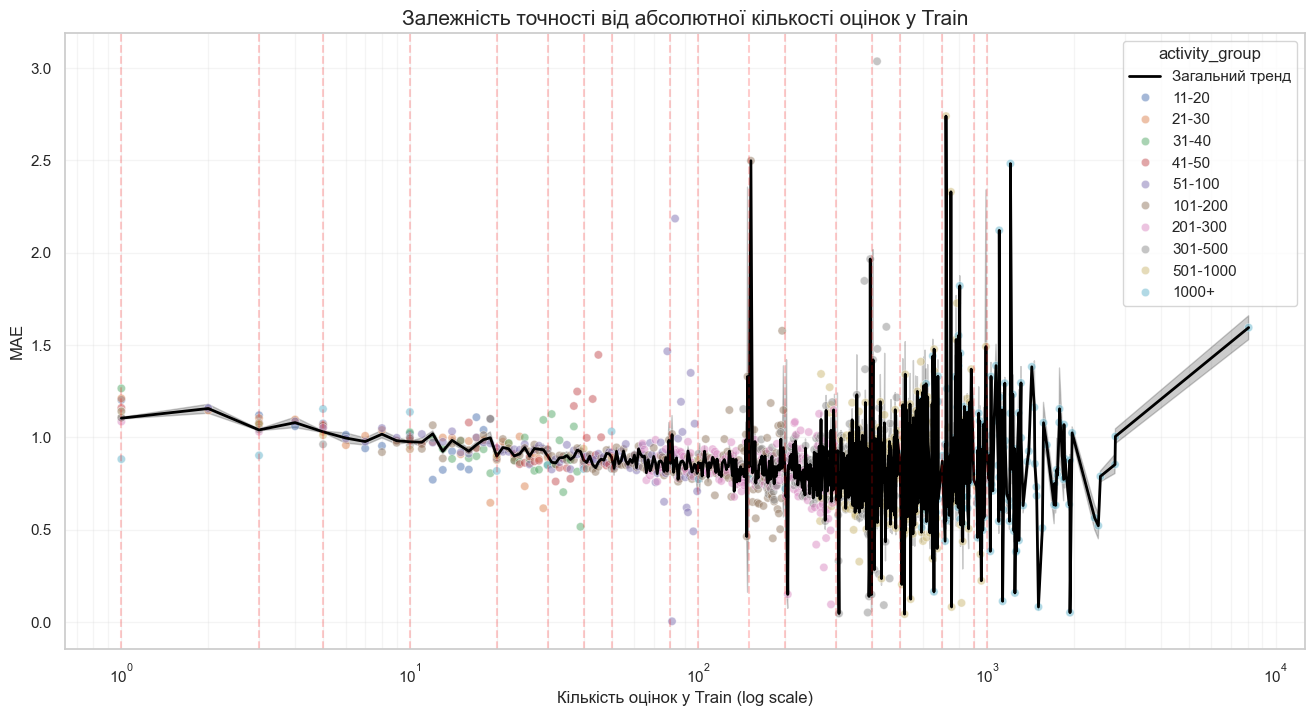

In [24]:
# Фільтруємо основний тест (без експериментальних серій)
df_main_test = test[test['series_id'].isna()].copy()

# Список ваших референтних значень для виділення на графіку
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

plt.figure(figsize=(16, 8))

# Будуємо загальну лінію тренду
sns.lineplot(data=df_main_test, x='train_count', y='hybrid_abs_error', color='black', linewidth=2, label='Загальний тренд')

# Додаємо точки для кожної групи активності
sns.scatterplot(
    data=df_main_test.groupby(['train_count', 'activity_group'])['hybrid_abs_error'].mean().reset_index(),
    x='train_count', y='hybrid_abs_error', hue='activity_group', alpha=0.5
)

# Виділяємо референтні кількості вертикальними лініями
for ref in ref_counts:
    if ref <= df_main_test['train_count'].max():
        plt.axvline(x=ref, color='red', linestyle='--', alpha=0.2)

plt.xscale('log') # Логарифмічна шкала краще показує різницю між 1 та 10 оцінками
plt.title('Залежність точності від абсолютної кількості оцінок у Train', fontsize=15)
plt.xlabel('Кількість оцінок у Train (log scale)', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

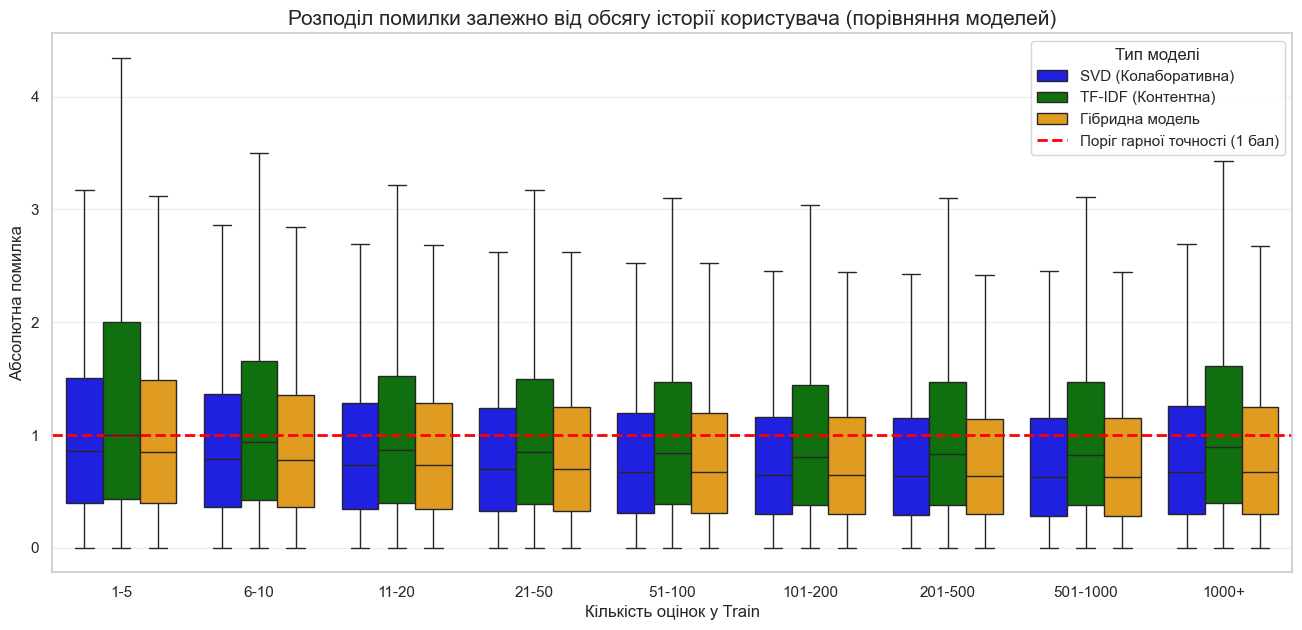

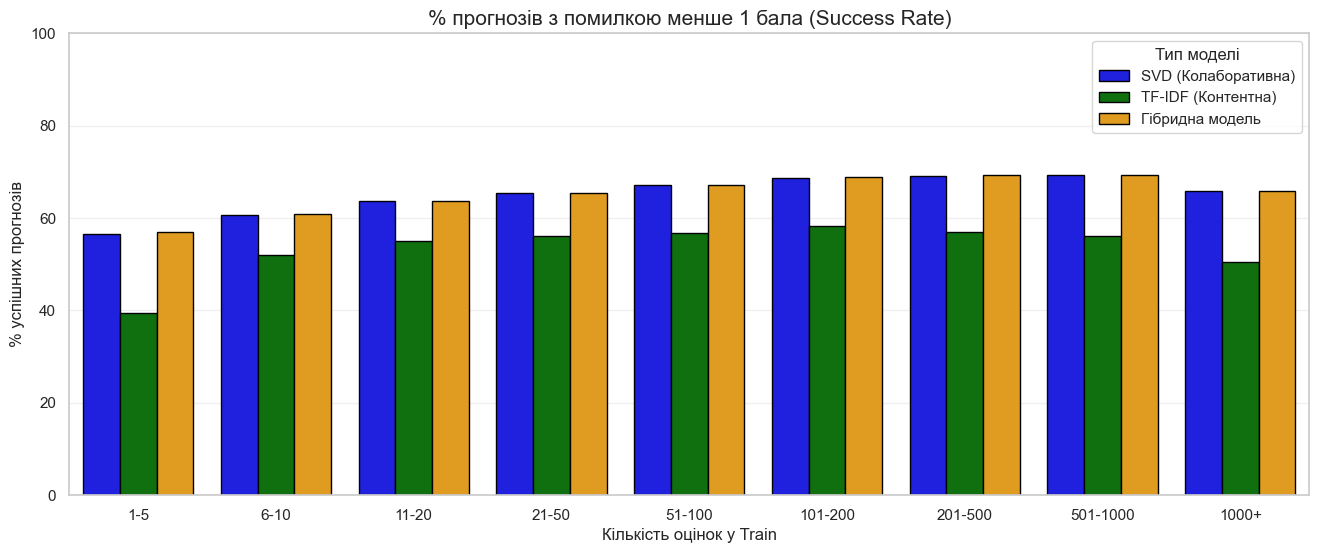

In [25]:
# ==========================================
# 1. Підготовка даних
# ==========================================
# (Припускаємо, що працюємо з датафреймом test, де вже є наші 3 помилки та train_count)

# Створюємо логічні кошики (біни) для кількості оцінок
bins = [0, 5, 10, 20, 50, 100, 200, 500, 1000, 10000]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201-500', '501-1000', '1000+']
test['train_bin'] = pd.cut(test['train_count'], bins=bins, labels=labels)

# Згортаємо дані (Melt) для побудови з розбиттям на моделі
df_bins_melted = test.melt(
    id_vars=['train_bin'], 
    value_vars=['svd_abs_error', 'content_abs_error', 'hybrid_abs_error'], 
    var_name='model_type', 
    value_name='abs_error'
)

# Робимо красиві назви моделей
model_names = {
    'svd_abs_error': 'SVD (Колаборативна)',
    'content_abs_error': 'TF-IDF (Контентна)',
    'hybrid_abs_error': 'Гібридна модель'
}
df_bins_melted['model_type'] = df_bins_melted['model_type'].map(model_names)


# ==========================================
# 2. Графік 1: Boxplot (Розподіл помилки)
# ==========================================
plt.figure(figsize=(16, 7))

# hue='model_type' робить 3 окремі "ящики" для кожного біна
sns.boxplot(
    data=df_bins_melted, 
    x='train_bin', 
    y='abs_error', 
    hue='model_type', 
    showfliers=False, 
    palette=["blue", "green", "orange"] # Фірмові кольори
)

plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Поріг гарної точності (1 бал)')

plt.title('Розподіл помилки залежно від обсягу історії користувача (порівняння моделей)', fontsize=15)
plt.xlabel('Кількість оцінок у Train', fontsize=12)
plt.ylabel('Абсолютна помилка', fontsize=12)
plt.legend(title='Тип моделі')
plt.grid(axis='y', alpha=0.3)
plt.show()


# ==========================================
# 3. Графік 2: Barplot (% успішних прогнозів)
# ==========================================
# Маленький хитрий трюк: створюємо колонку, де True=100, False=0. 
# Тоді середнє значення цієї колонки - це і є відсоток успіху!
df_bins_melted['is_success_pct'] = (df_bins_melted['abs_error'] < 1.0) * 100

plt.figure(figsize=(16, 6))

# sns.barplot автоматично рахує середнє значення (наш відсоток) і розбиває по hue
sns.barplot(
    data=df_bins_melted, 
    x='train_bin', 
    y='is_success_pct', 
    hue='model_type', 
    palette=["blue", "green", "orange"], 
    edgecolor='black',
    errorbar=None # Прибираємо чорні "вусики" довірчого інтервалу для чистоти
)

plt.title('% прогнозів з помилкою менше 1 бала (Success Rate)', fontsize=15)
plt.xlabel('Кількість оцінок у Train', fontsize=12)
plt.ylabel('% успішних прогнозів', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Тип моделі')
plt.grid(axis='y', alpha=0.3)
plt.show()

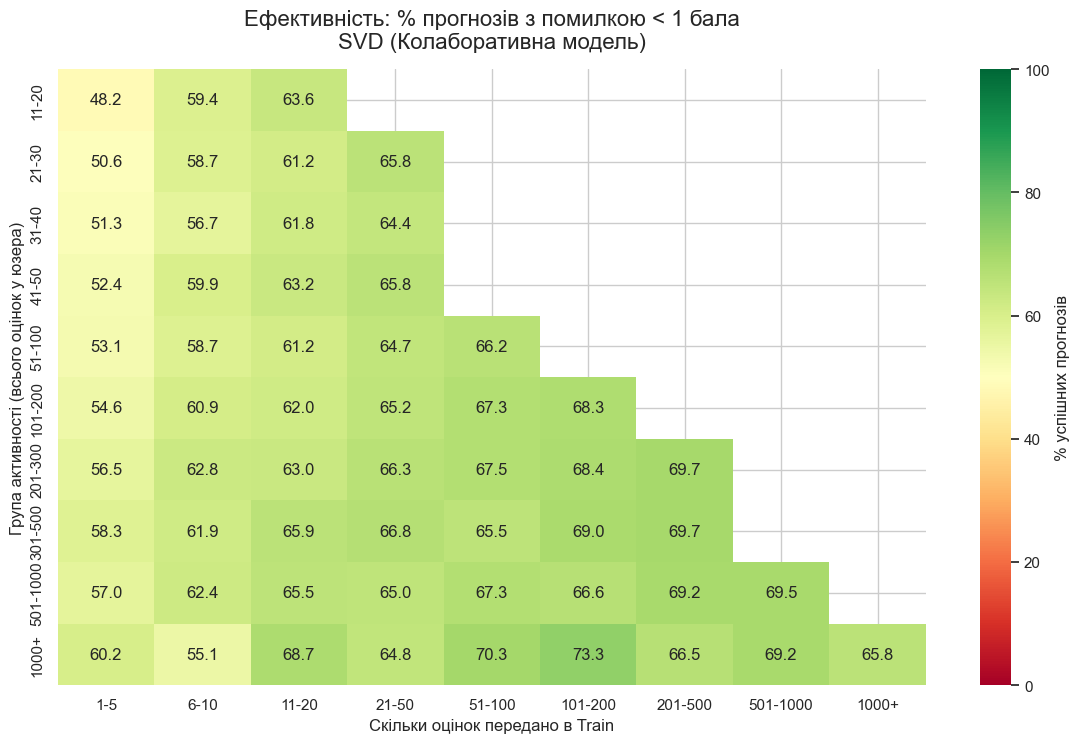

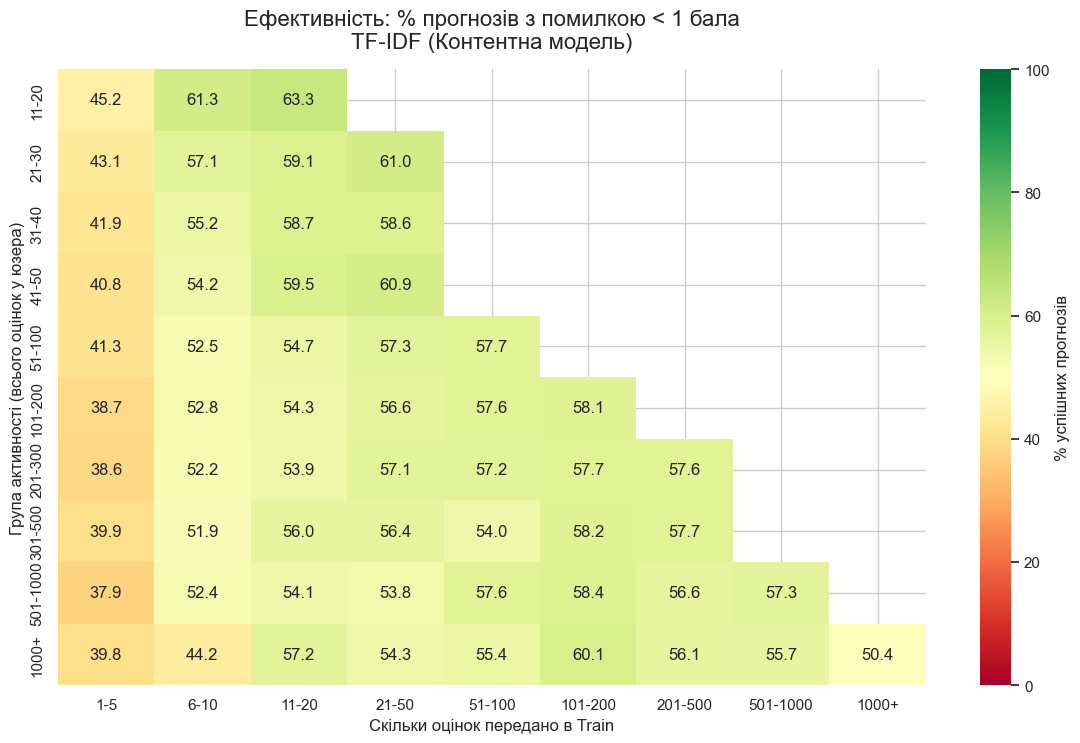

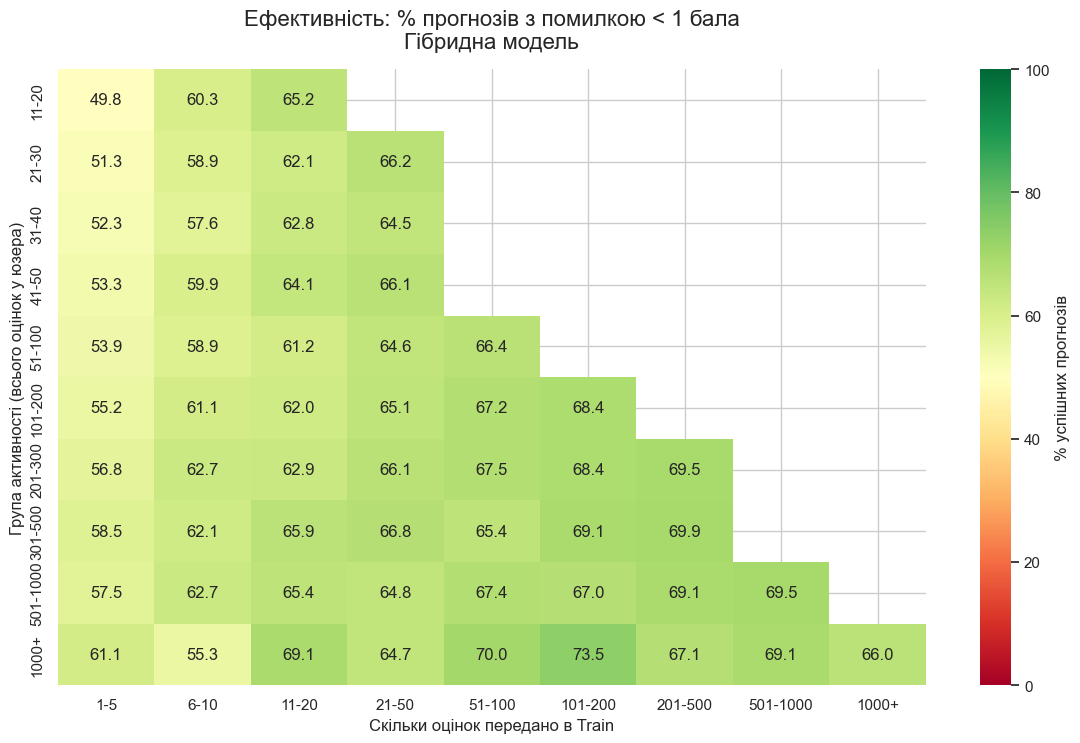

In [26]:
# Визначаємо наші колонки з помилками та заголовки
models_to_plot = [
    ('svd_abs_error', 'SVD (Колаборативна модель)'),
    ('content_abs_error', 'TF-IDF (Контентна модель)'),
    ('hybrid_abs_error', 'Гібридна модель')
]

# Проходимося циклом і малюємо 3 ОКРЕМІ великі графіки
for error_col, model_name in models_to_plot:
    
    # 1. Готуємо дані (відсоток успіху) для конкретної моделі
    # Примітка: використовуйте test або df_main_test залежно від того, 
    # де саме зараз знаходяться ваші колонки *_abs_error
    pivot_success = test.pivot_table(
        index='activity_group',
        columns='train_bin',
        values=error_col,
        aggfunc=lambda x: (x < 1.0).mean() * 100
    )
    
    # 2. Створюємо окреме велике полотно для кожної ітерації
    plt.figure(figsize=(14, 8))
    
    # 3. Малюємо теплову карту з фіксованою шкалою (vmin=0, vmax=100)
    sns.heatmap(
        pivot_success, 
        annot=True, 
        fmt=".1f", 
        cmap="RdYlGn", 
        vmin=0, 
        vmax=100,
        cbar_kws={'label': '% успішних прогнозів'}
    )
    
    # 4. Налаштовуємо підписи та заголовки
    plt.title(f"Ефективність: % прогнозів з помилкою < 1 бала\n{model_name}", fontsize=16, pad=15)
    plt.ylabel("Група активності (всього оцінок у юзера)", fontsize=12)
    plt.xlabel("Скільки оцінок передано в Train", fontsize=12)
    
    # 5. Виводимо графік (це розірве їх на три окремі малюнки в Colab/Jupyter)
    plt.show()
    
    # Додаємо трохи порожнього простору між виводами графіків для естетики
    print("\n" * 2)

In [27]:
print(f"Поточний тип даних train_count: {df_main_test['train_count'].dtype}")

Поточний тип даних train_count: float64


In [28]:
df_main_test['train_count'] = df_main_test['train_count'].astype('int32')

print(f"Новий тип даних: {df_main_test['train_count'].dtype}")

Новий тип даних: int32


C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


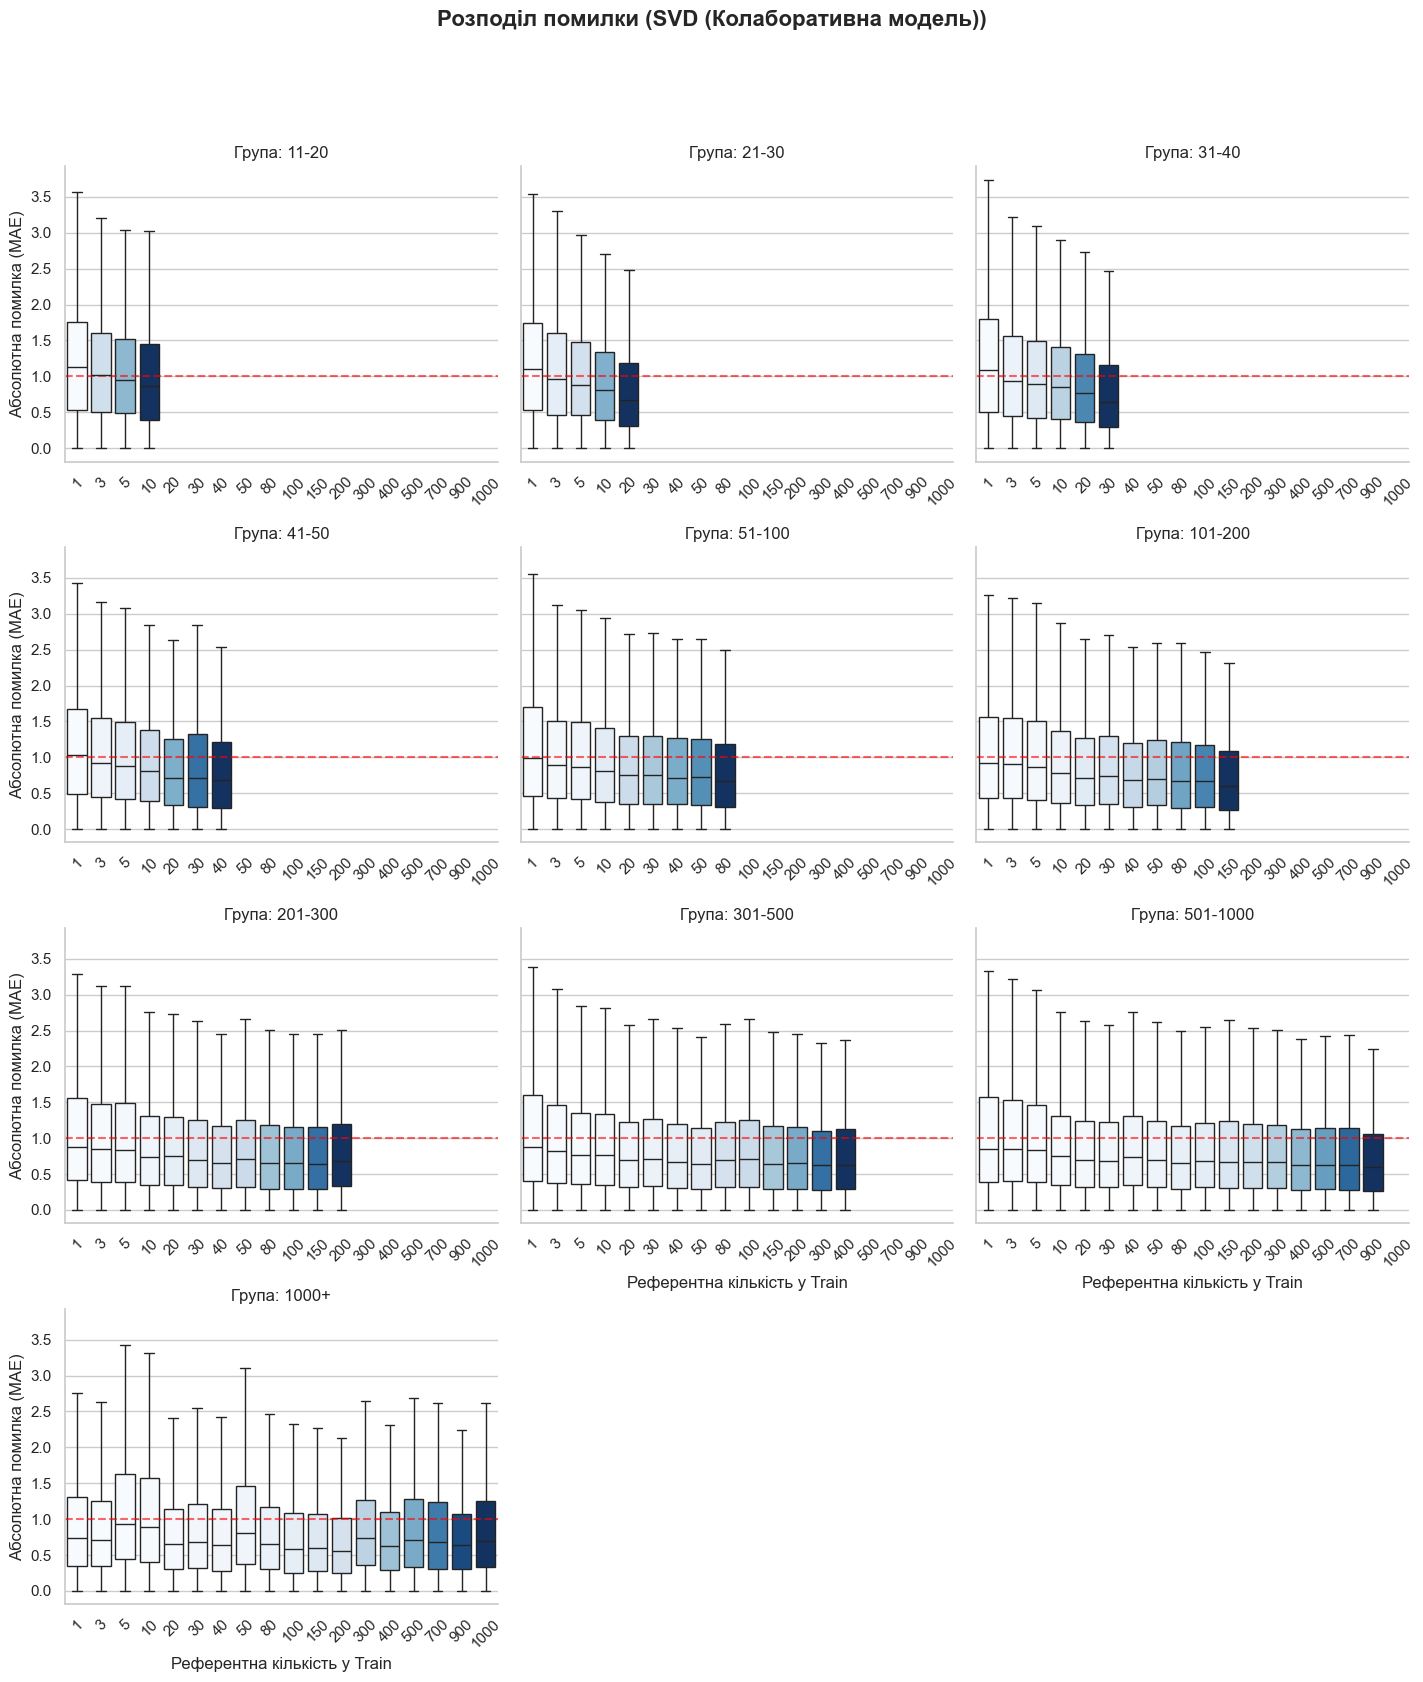

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


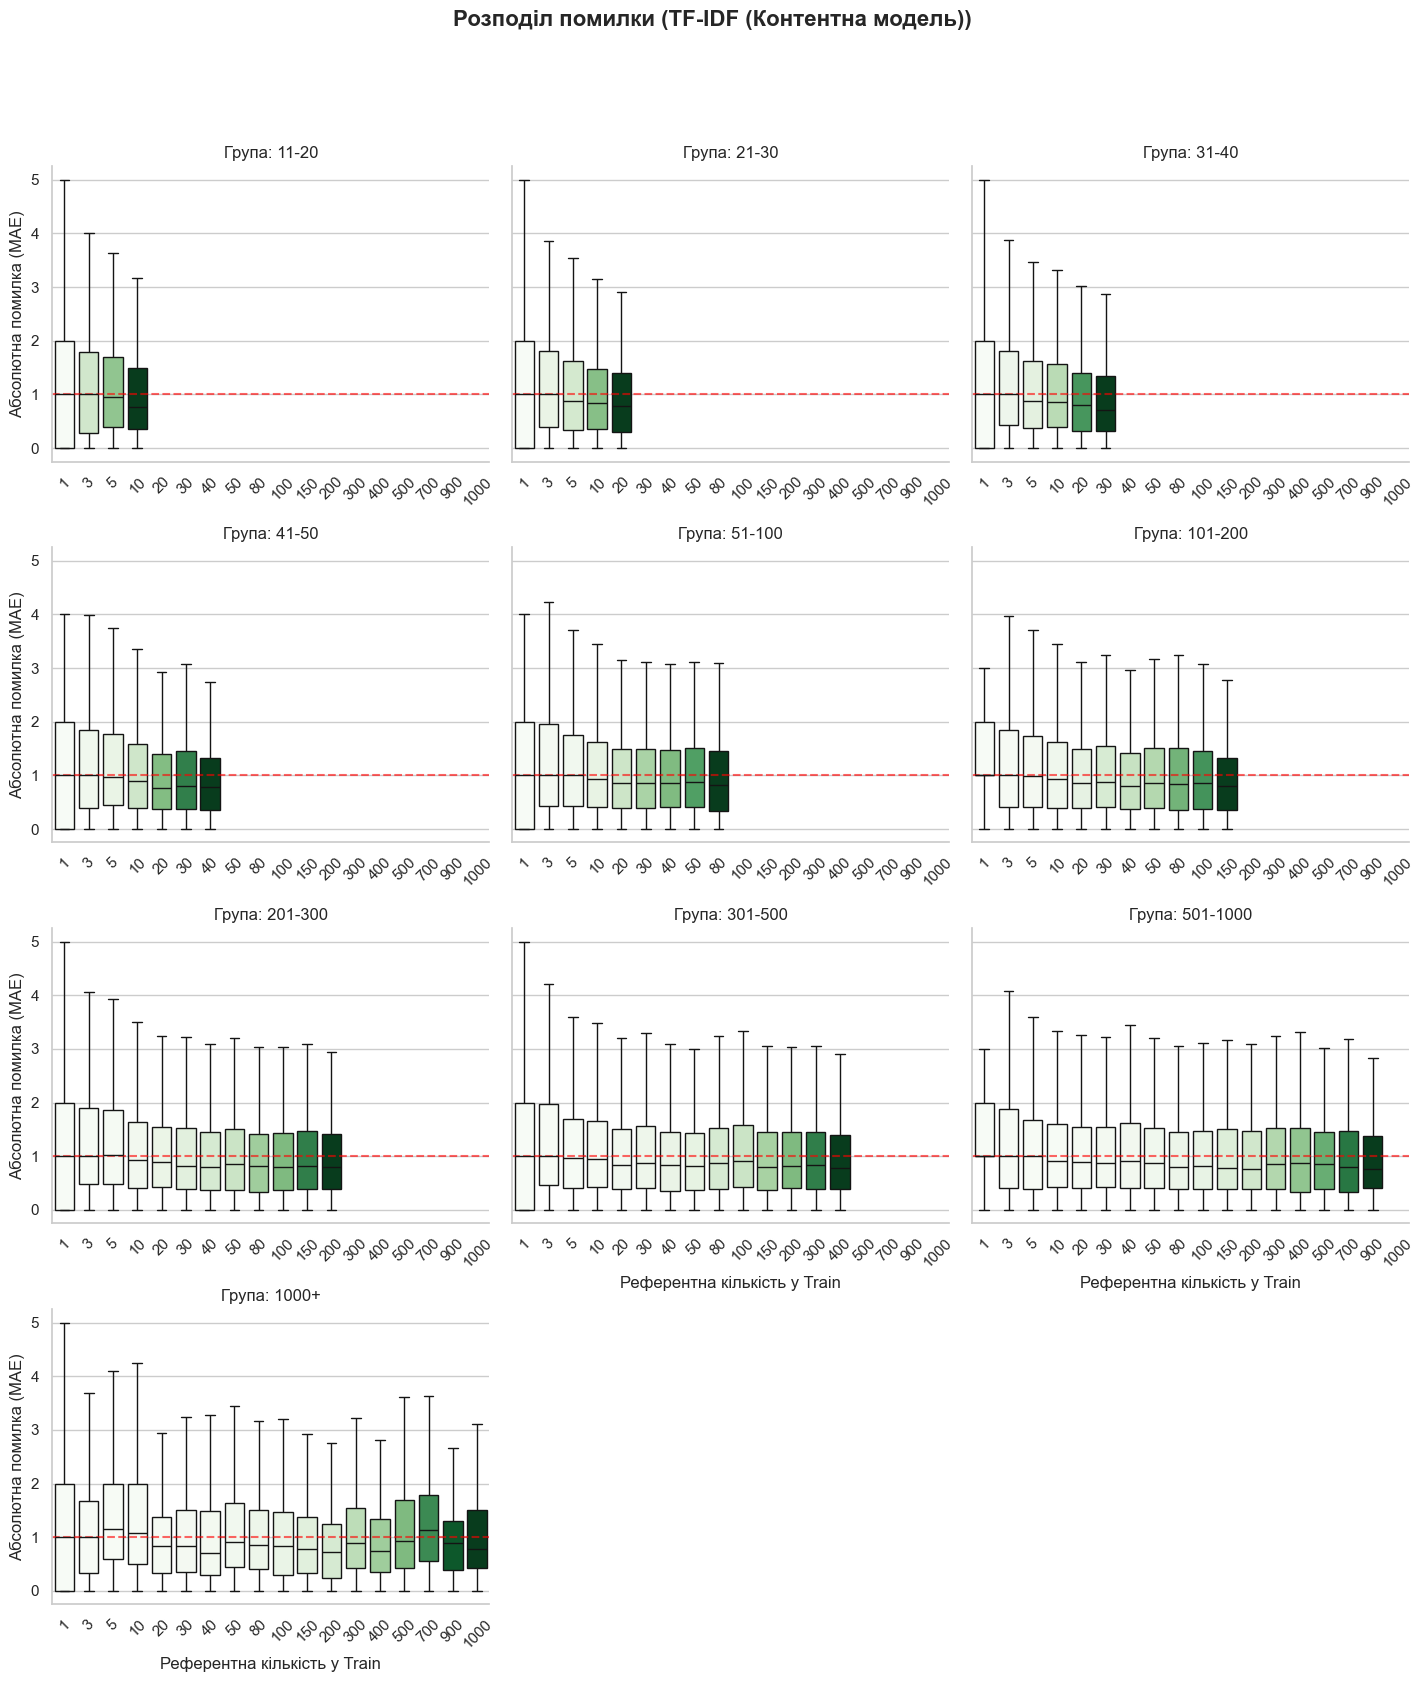

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\373862290.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


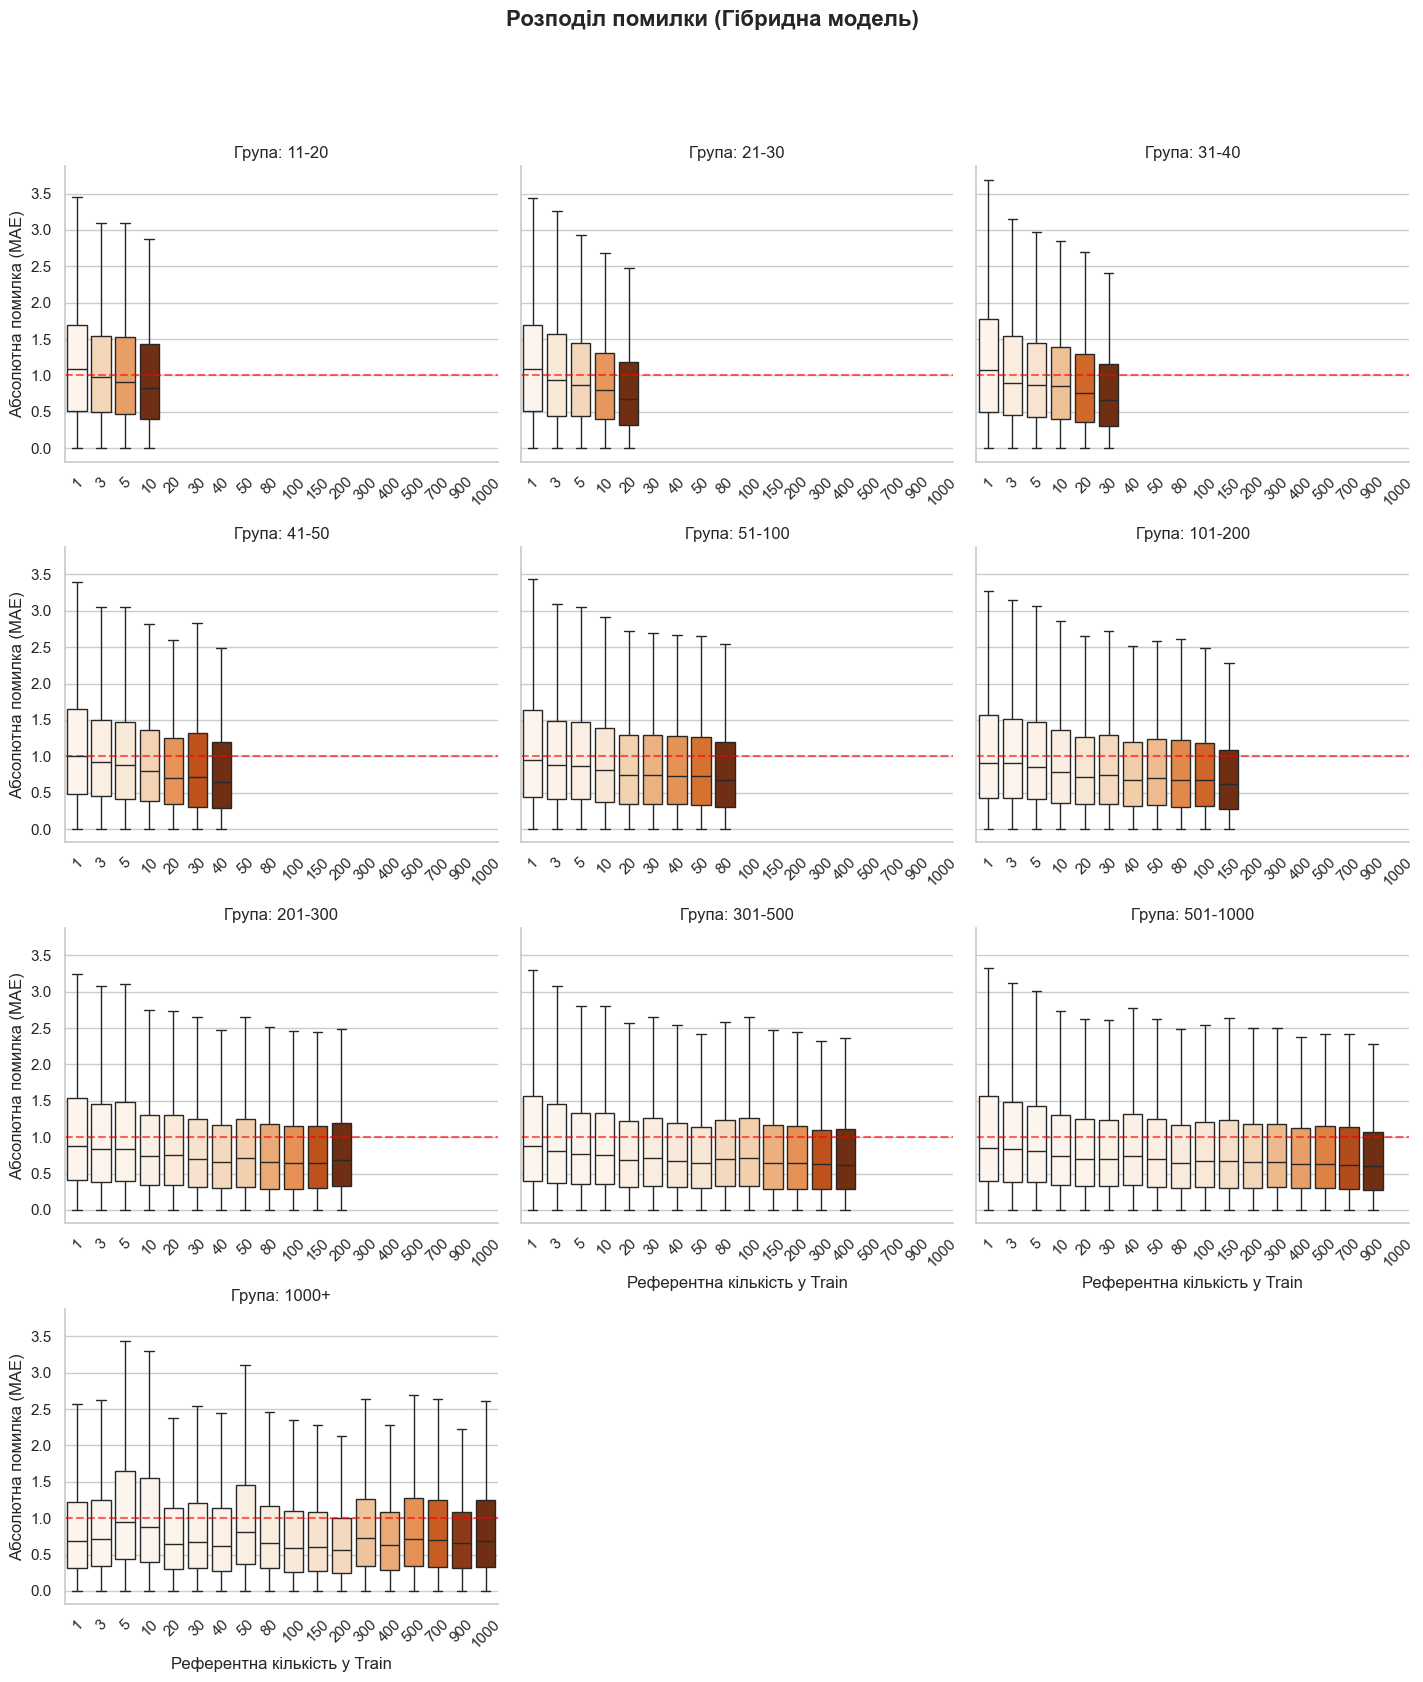

In [29]:
# 1. Підготовка точок
ref_points = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

# Переконайтеся, що ви використовуєте правильний датафрейм (test або df_main_test),
# де вже розраховані svd_abs_error, content_abs_error, hybrid_abs_error
df_ref = df_main_test[df_main_test['train_count'].isin(ref_points)].copy() 

# Створюємо список моделей для побудови
models_to_plot = [
    ('svd_abs_error', 'SVD (Колаборативна модель)', 'Blues'),
    ('content_abs_error', 'TF-IDF (Контентна модель)', 'Greens'),
    ('hybrid_abs_error', 'Гібридна модель', 'Oranges')
]

# 2. Будуємо окрему сітку для кожної моделі
for error_col, model_name, color_palette in models_to_plot:
    
    # Створюємо сітку
    g = sns.FacetGrid(
        df_ref, 
        col="activity_group", 
        col_wrap=3, 
        height=4, 
        aspect=1.2, 
        sharex=False # У кожної групи своя шкала Train
    )

    # Малюємо боксплоти. Зверніть увагу: y=error_col
    g.map_dataframe(
        sns.boxplot, 
        x="train_count", 
        y=error_col, 
        order=ref_points, 
        showfliers=False,
        palette=color_palette, # Кожній моделі - свій фірмовий колір
        hue="train_count",     
        legend=False
    )

    # Налаштування осей та ліній для кожного підграфіка
    for ax in g.axes.flat:
        # Додаємо червону лінію "порогу якості"
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
        
        # Обертаємо підписи, щоб вони не зливалися
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    # Підписи осей та заголовки
    g.set_axis_labels("Референтна кількість у Train", "Абсолютна помилка (MAE)")
    g.set_titles("Група: {col_name}", size=12)
    
    # Додаємо ГОЛОВНИЙ заголовок для всієї сітки (над усіма графіками)
    g.fig.suptitle(f'Розподіл помилки ({model_name})', y=1.05, fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Додаємо візуальний відступ між виводами різних сіток
    print("\n" + "="*80 + "\n")

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\1162512053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


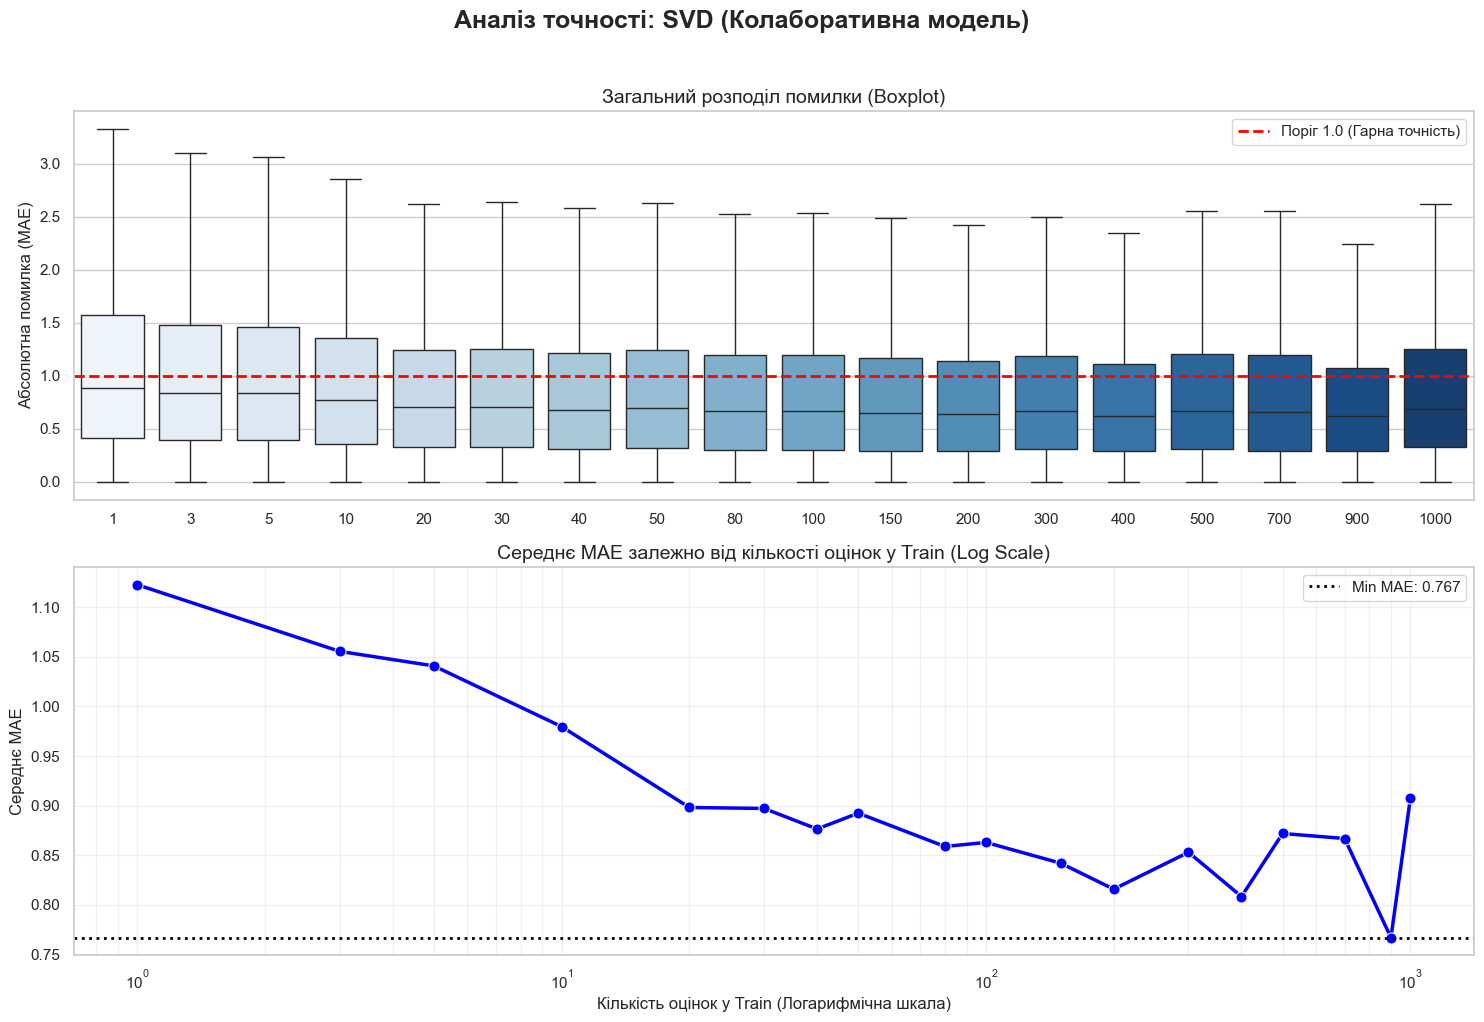

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\1162512053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


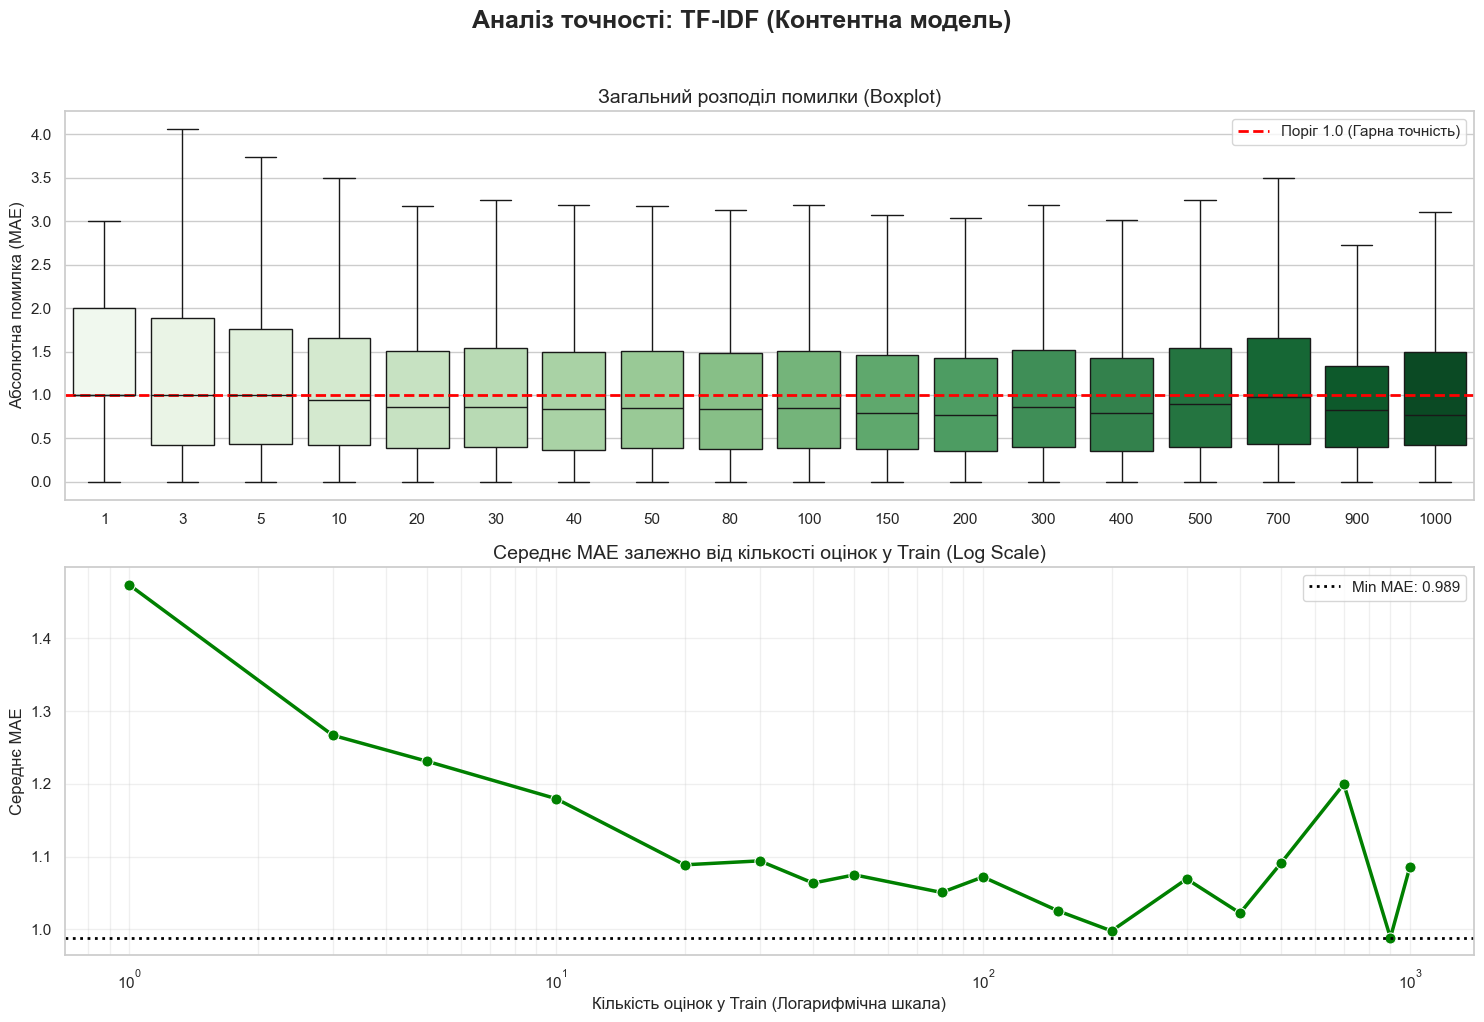

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\1162512053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


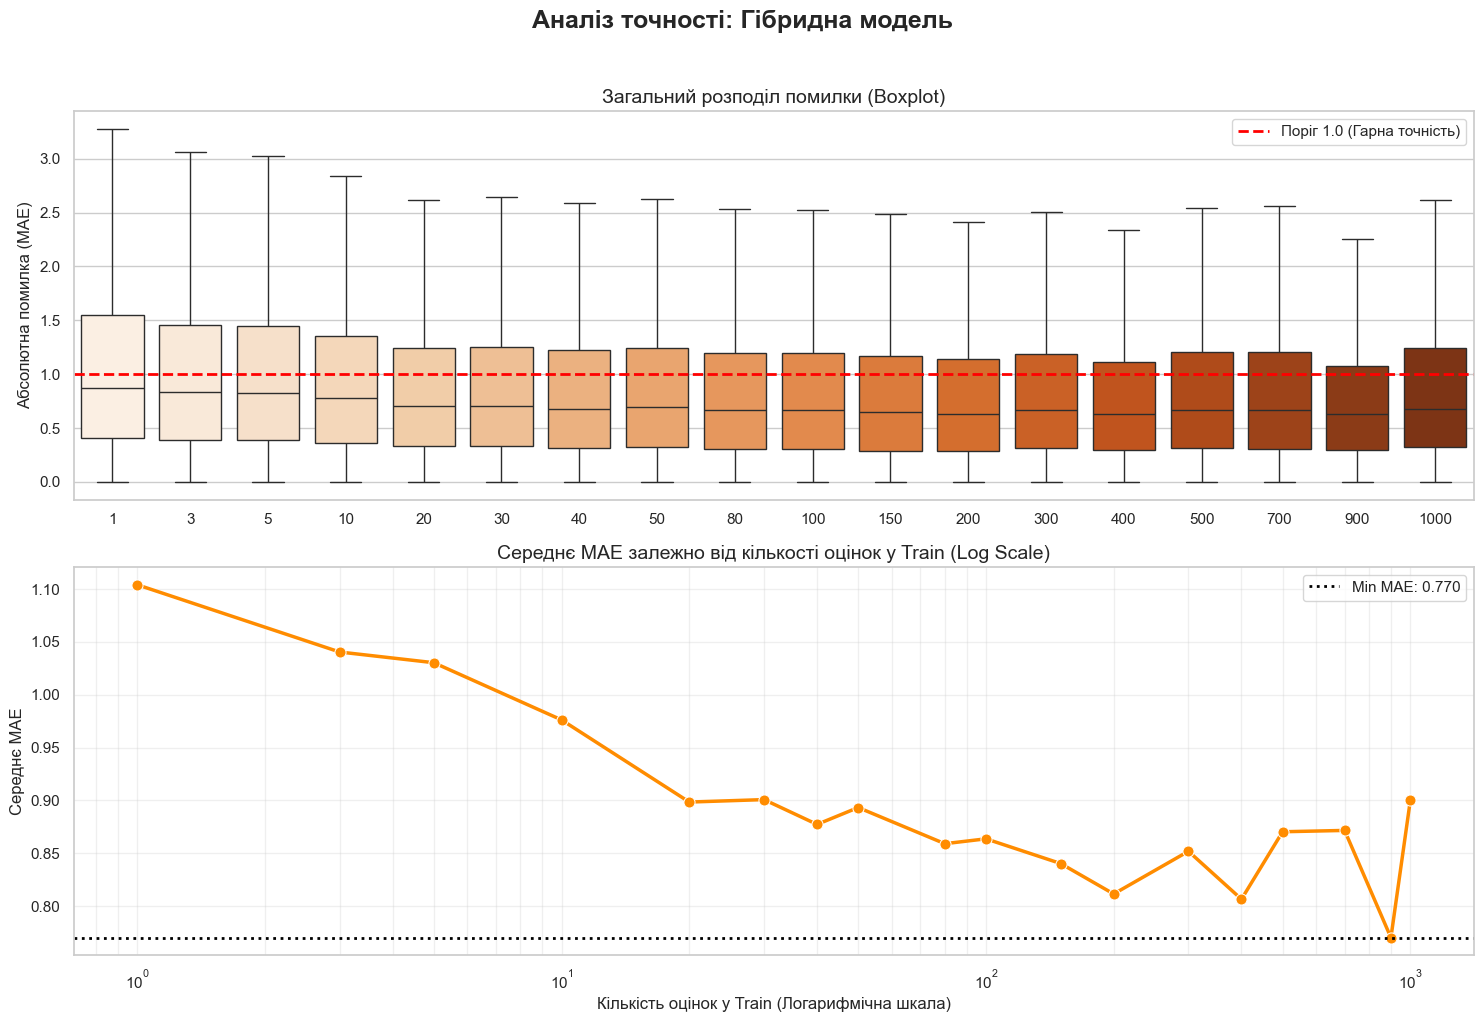

In [30]:
# Визначаємо список моделей: (колонка_з_помилкою, Назва, палітра_для_ящиків, колір_для_лінії)
models_to_plot = [
    ('svd_abs_error', 'SVD (Колаборативна модель)', 'Blues', 'blue'),
    ('content_abs_error', 'TF-IDF (Контентна модель)', 'Greens', 'green'),
    ('hybrid_abs_error', 'Гібридна модель', 'Oranges', 'darkorange')
]

# Запускаємо цикл для створення трьох окремих фігур
for error_col, model_name, box_palette, line_color in models_to_plot:
    
    # Створюємо велике полотно для однієї моделі
    fig = plt.figure(figsize=(15, 10))
    
    # Додаємо головний заголовок для всього малюнка
    plt.suptitle(f'Аналіз точності: {model_name}', fontsize=18, fontweight='bold', y=1.02)

    # --- ГРАФІК 1: Загальний Boxplot для всіх ---
    plt.subplot(2, 1, 1)
    sns.boxplot(
        data=df_ref, 
        x='train_count', 
        y=error_col,           # Динамічно підставляємо колонку з циклу
        showfliers=False, 
        palette=box_palette    # Динамічна палітра
    )
    plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Поріг 1.0 (Гарна точність)')
    
    plt.title('Загальний розподіл помилки (Boxplot)', fontsize=14)
    plt.ylabel('Абсолютна помилка (MAE)', fontsize=12)
    plt.xlabel('') # прибираємо, щоб не накладалося
    plt.legend(loc='upper right')

    # --- ГРАФІК 2: Лінійний тренд середнього MAE ---
    plt.subplot(2, 1, 2)
    # Розраховуємо середнє MAE для кожної кількості Train для поточної моделі
    mean_mae = df_ref.groupby('train_count')[error_col].mean().reset_index()

    sns.lineplot(
        data=mean_mae, 
        x='train_count', 
        y=error_col,           # Динамічна колонка
        color=line_color,      # Динамічний колір
        linewidth=2.5,
        marker='o',            # Додав маркери для кращої видимості точок
        markersize=8
    )
    
    plt.xscale('log') # Логарифмічна шкала
    
    # Лінія мінімального MAE
    min_mae_val = mean_mae[error_col].min()
    plt.axhline(min_mae_val, color='black', linestyle=':', linewidth=2, label=f'Min MAE: {min_mae_val:.3f}')

    plt.title('Середнє MAE залежно від кількості оцінок у Train (Log Scale)', fontsize=14)
    plt.xlabel('Кількість оцінок у Train (Логарифмічна шкала)', fontsize=12)
    plt.ylabel('Середнє MAE', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    
    # Виводимо поточний малюнок на екран
    plt.show()
    
    # Додаємо візуальний роздільник між виводами
    print("\n" + "="*80 + "\n")

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\4181431513.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


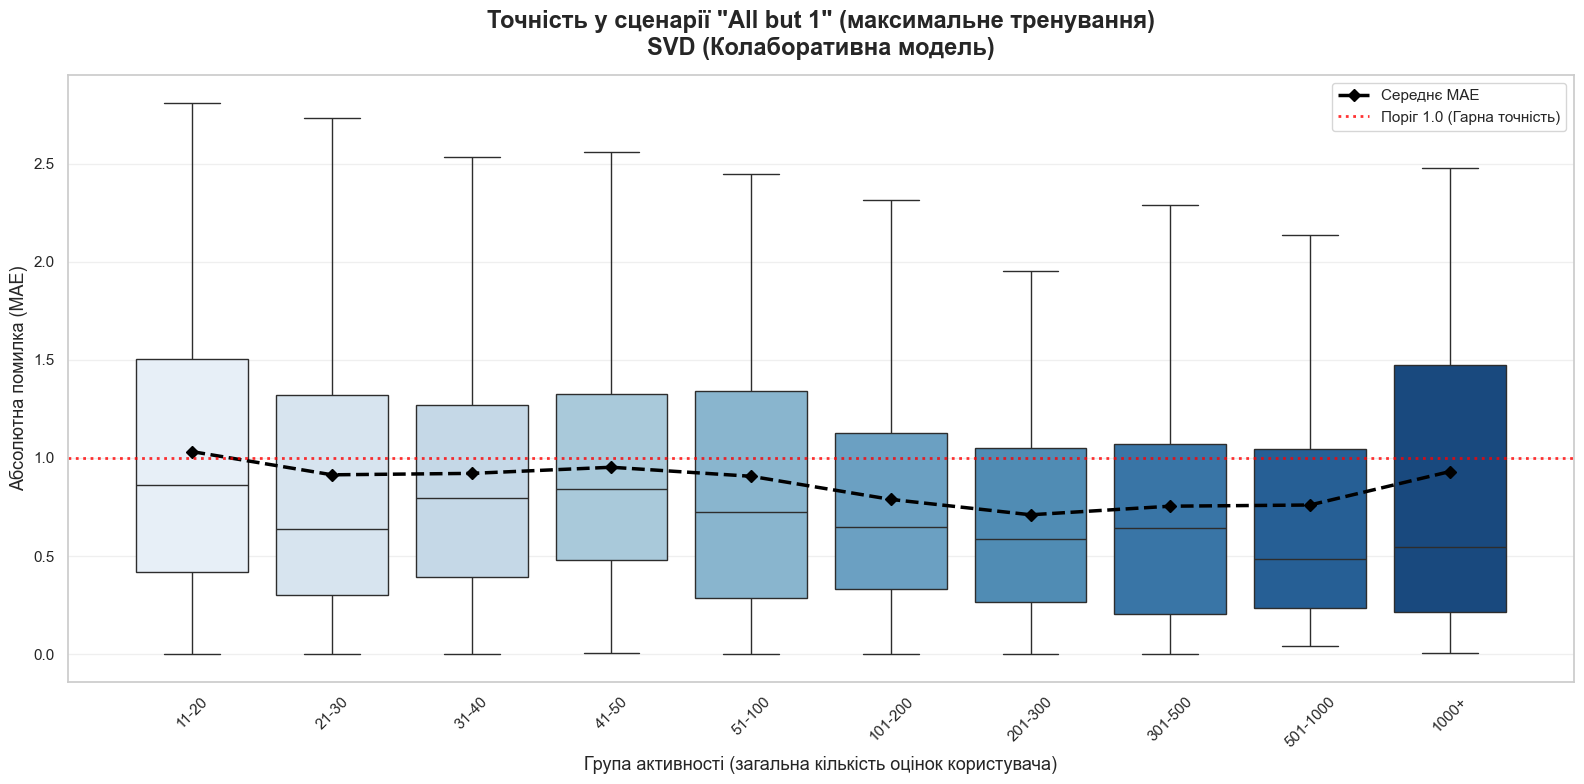

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\4181431513.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


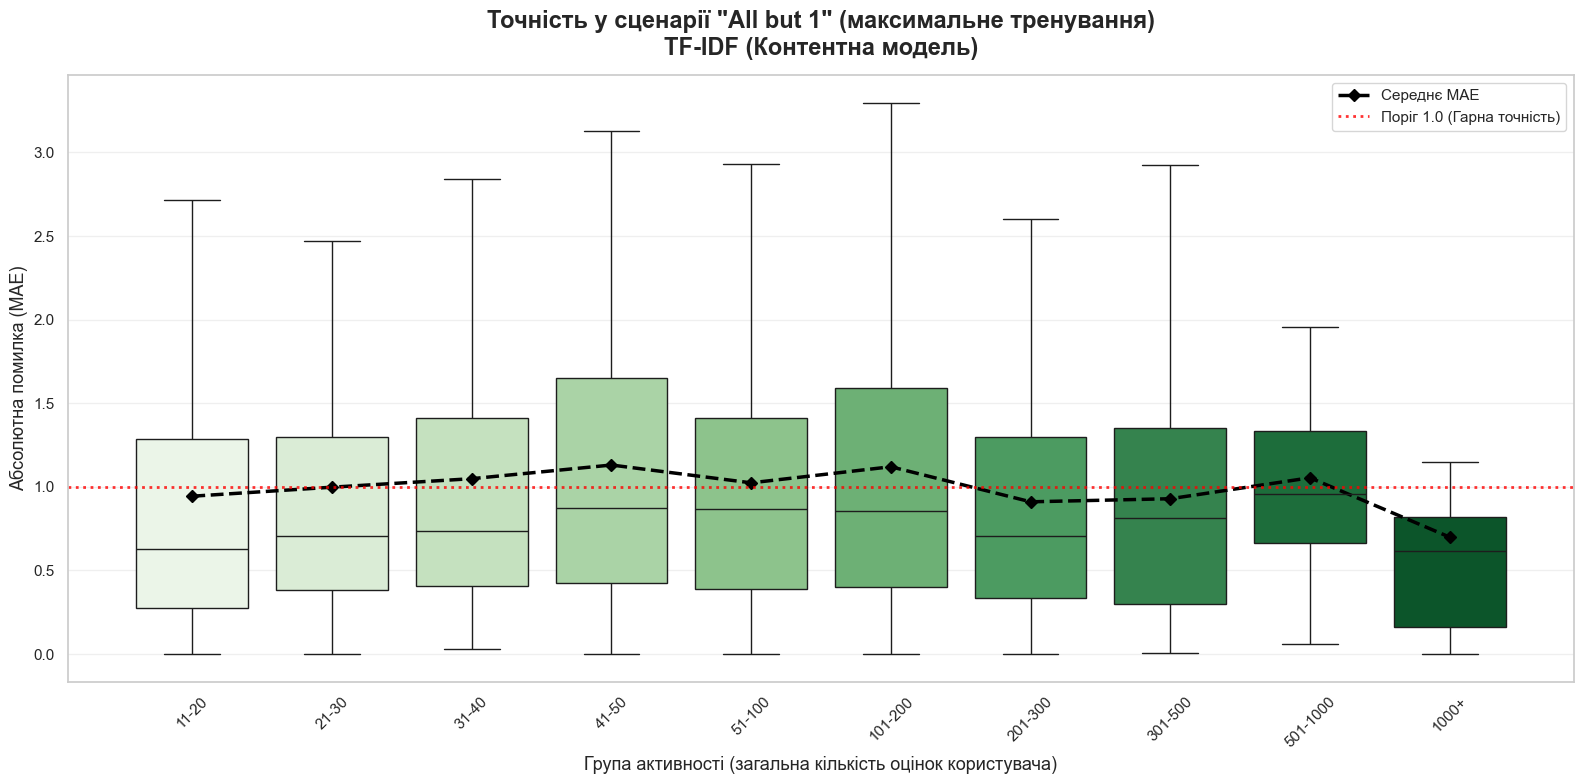

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\4181431513.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


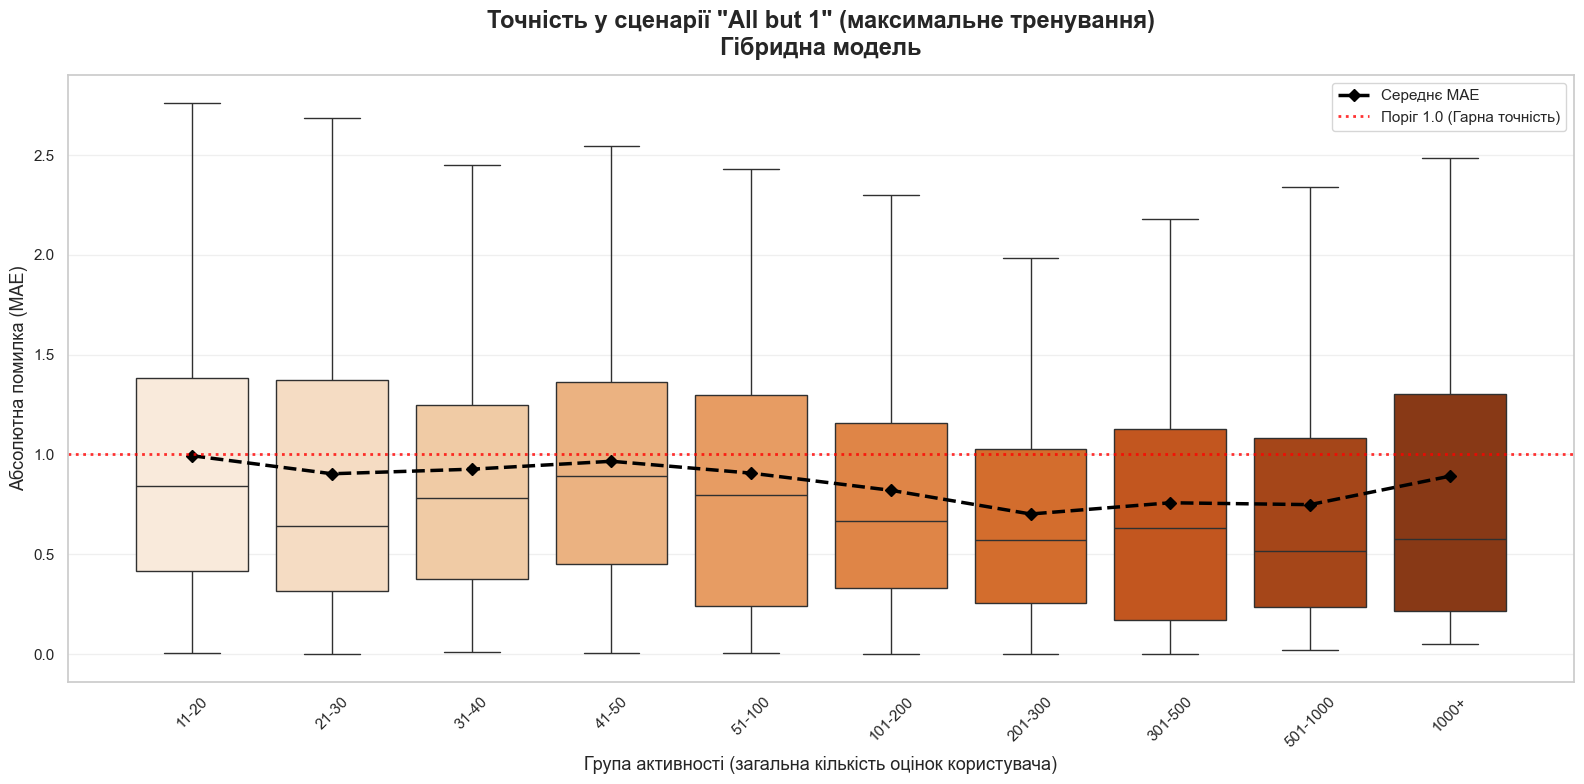

In [31]:
# 1. Готуємо дані (фільтруємо тест)
# Упевніться, що ви використовуєте датафрейм, де вже є наші 3 помилки (наприклад, test)
df_all_but_one = test[test['is_all_but_one'] == True].copy()

# Визначаємо список моделей для побудови
models_to_plot = [
    ('svd_abs_error', 'SVD (Колаборативна модель)', 'Blues'),
    ('content_abs_error', 'TF-IDF (Контентна модель)', 'Greens'),
    ('hybrid_abs_error', 'Гібридна модель', 'Oranges')
]

# Запускаємо цикл для створення 3 окремих графіків
for error_col, model_name, palette_name in models_to_plot:
    
    plt.figure(figsize=(16, 8))

    # 2. Будуємо Boxplot
    ax = sns.boxplot(
        data=df_all_but_one, 
        x='activity_group', 
        y=error_col,           # Динамічно підставляємо помилку
        palette=palette_name,  # Динамічна палітра
        showfliers=False       # Прибираємо викиди
    )

    # 3. Додаємо лінію середнього MAE для наочності тренду
    # Витягуємо точний порядок груп на осі X, який щойно створив seaborn
    x_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    
    # Рахуємо середнє значення саме в такому порядку
    mean_values = [df_all_but_one[df_all_but_one['activity_group'] == group][error_col].mean() for group in x_labels]
    
    # Малюємо лінію середнього
    plt.plot(range(len(mean_values)), mean_values, color='black', marker='D', linestyle='--', linewidth=2.5, label='Середнє MAE')

    # 4. Налаштування
    plt.axhline(1.0, color='red', linestyle=':', linewidth=2, alpha=0.8, label='Поріг 1.0 (Гарна точність)')
    
    # Великий заголовок з назвою поточної моделі
    plt.title(f'Точність у сценарії "All but 1" (максимальне тренування)\n{model_name}', fontsize=17, fontweight='bold', pad=15)
    
    plt.ylabel('Абсолютна помилка (MAE)', fontsize=13)
    plt.xlabel('Група активності (загальна кількість оцінок користувача)', fontsize=13)
    plt.xticks(rotation=45)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    # Відступ між графіками
    print("\n" + "="*80 + "\n")

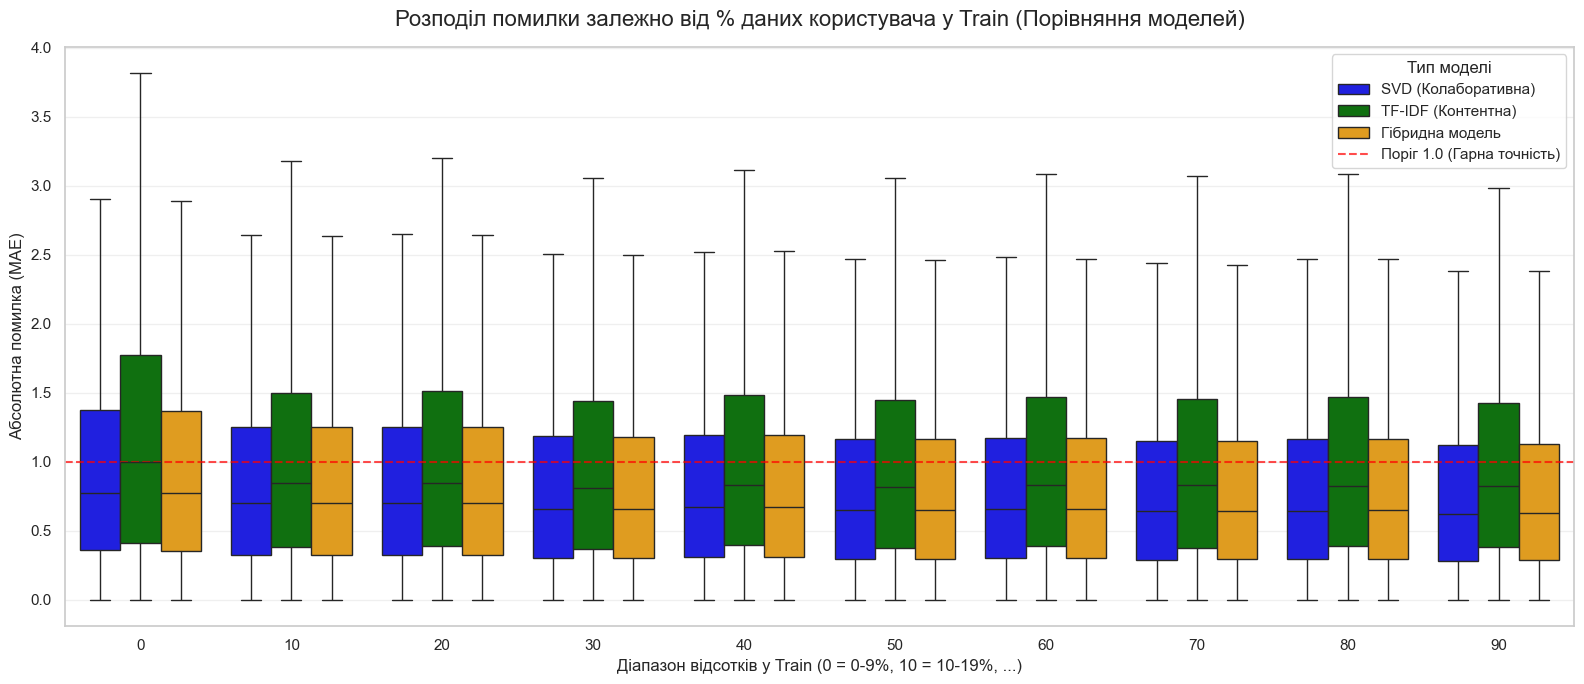

In [32]:
# ==========================================
# 1. Підготовка даних
# ==========================================
# Округлимо відсотки до 10% (використовуємо ваш код)
# Припускаємо, що датафрейм називається test і містить 3 колонки з помилками
df_main_test['train_pct_bin'] = (df_main_test['train_percent'] // 10 * 10).astype(int)

# Згортаємо 3 колонки помилок в одну для побудови (Melt)
df_pct_melted = df_main_test.melt(
    id_vars=['train_pct_bin'], 
    value_vars=['svd_abs_error', 'content_abs_error', 'hybrid_abs_error'], 
    var_name='model_type', 
    value_name='abs_error'
)

# Перейменовуємо моделі для красивої легенди
model_names = {
    'svd_abs_error': 'SVD (Колаборативна)',
    'content_abs_error': 'TF-IDF (Контентна)',
    'hybrid_abs_error': 'Гібридна модель'
}
df_pct_melted['model_type'] = df_pct_melted['model_type'].map(model_names)

# ==========================================
# 2. Побудова графіка
# ==========================================
# Робимо полотно трохи ширшим (16 замість 14), щоб ящикам не було тісно
plt.figure(figsize=(16, 7))

# Головна зміна тут: додано hue='model_type' та palette
sns.boxplot(
    data=df_pct_melted, 
    x='train_pct_bin', 
    y='abs_error', 
    hue='model_type',             # Магія, яка розбиває 1 бін на 3 стовпці
    showfliers=False,             # Прибираємо викиди для чистоти
    palette=["blue", "green", "orange"] # Наші фірмові кольори моделей
)

# Додамо лінію порогу для зручності оцінки (опціонально)
plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Поріг 1.0 (Гарна точність)')

# Налаштування краси
plt.title('Розподіл помилки залежно від % даних користувача у Train (Порівняння моделей)', fontsize=16, pad=15)
plt.xlabel('Діапазон відсотків у Train (0 = 0-9%, 10 = 10-19%, ...)', fontsize=12)
plt.ylabel('Абсолютна помилка (MAE)', fontsize=12)

# Легенду краще винести, щоб вона не перекривала самі графіки
plt.legend(title='Тип моделі', loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklab

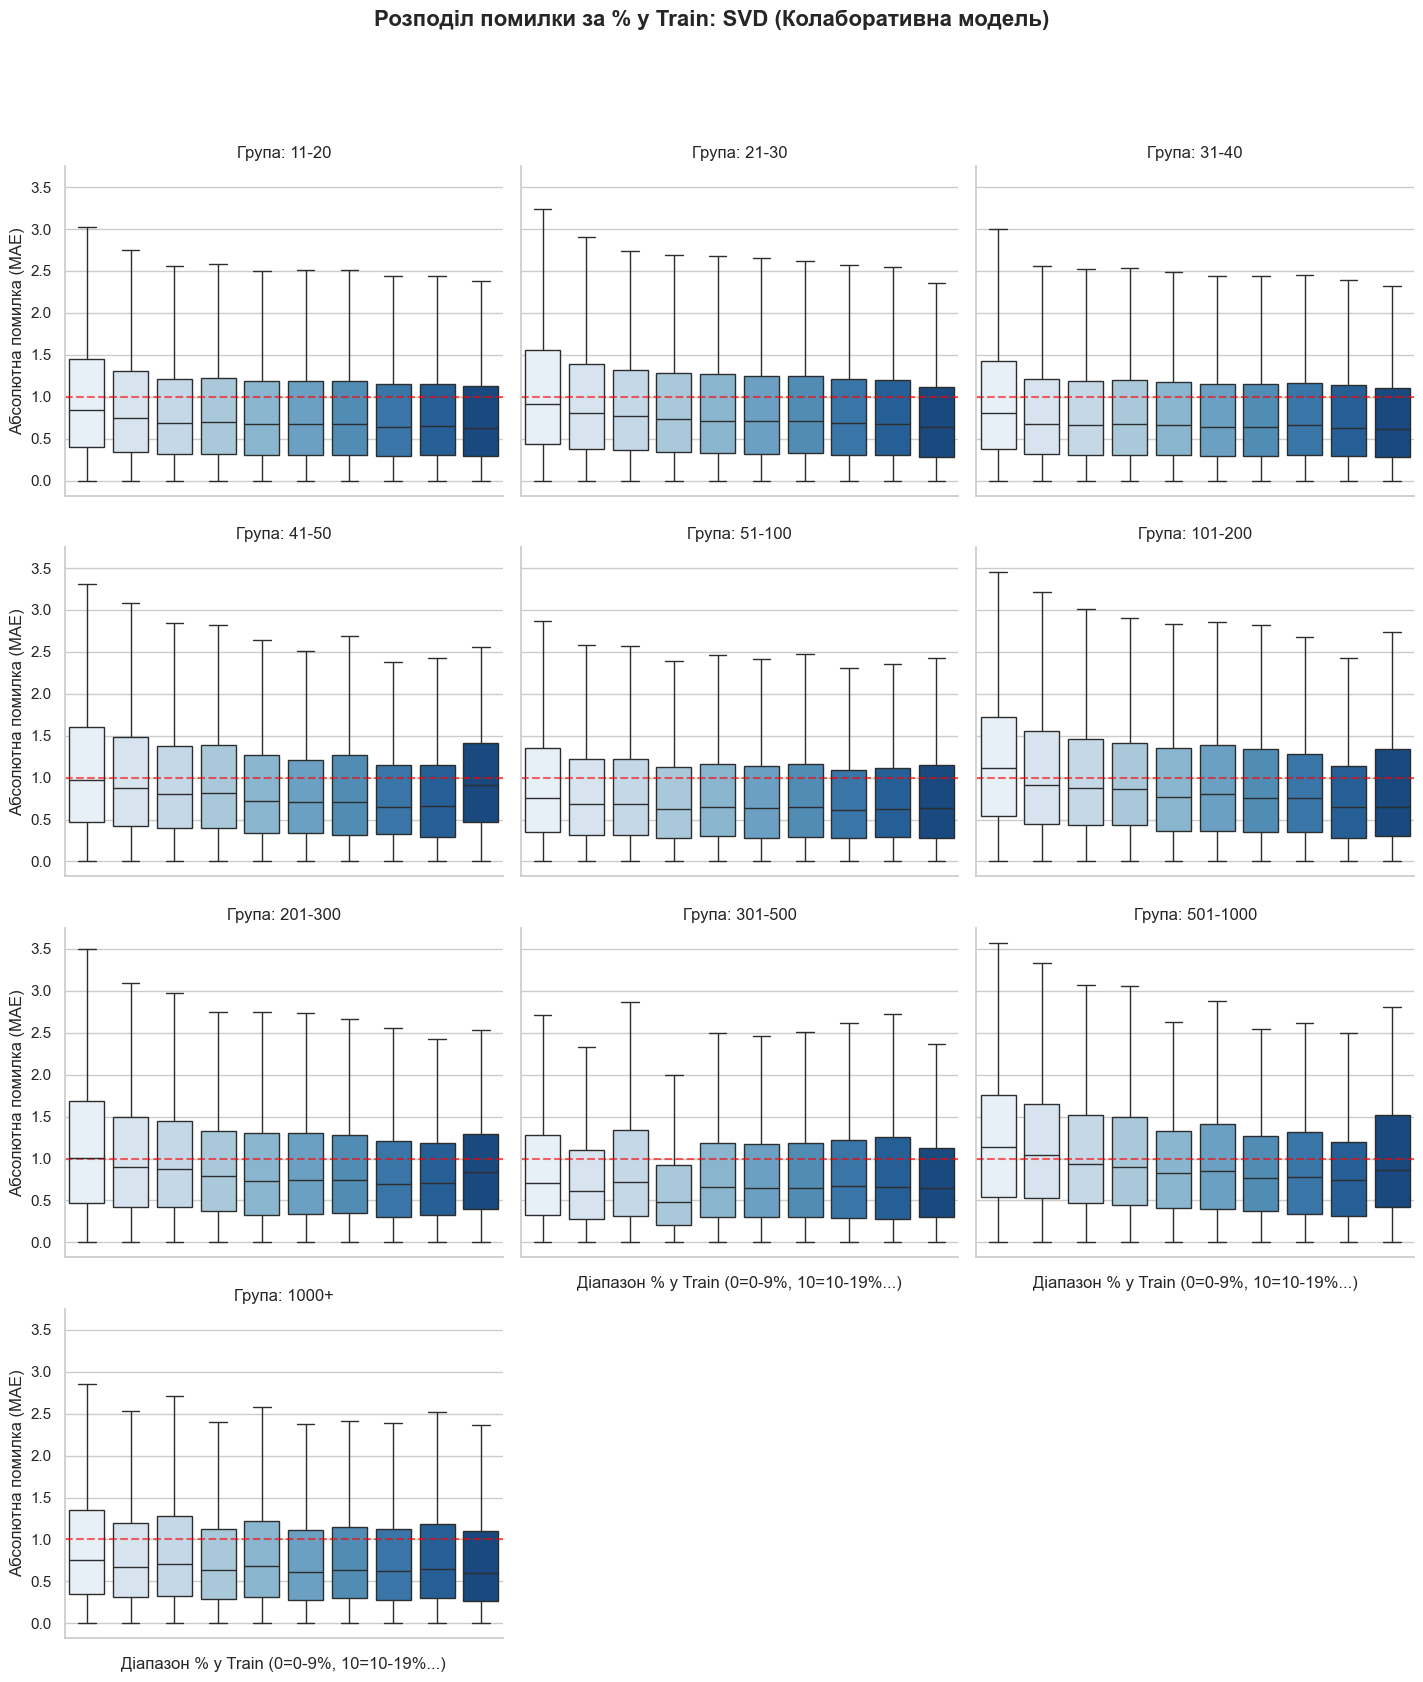

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklab

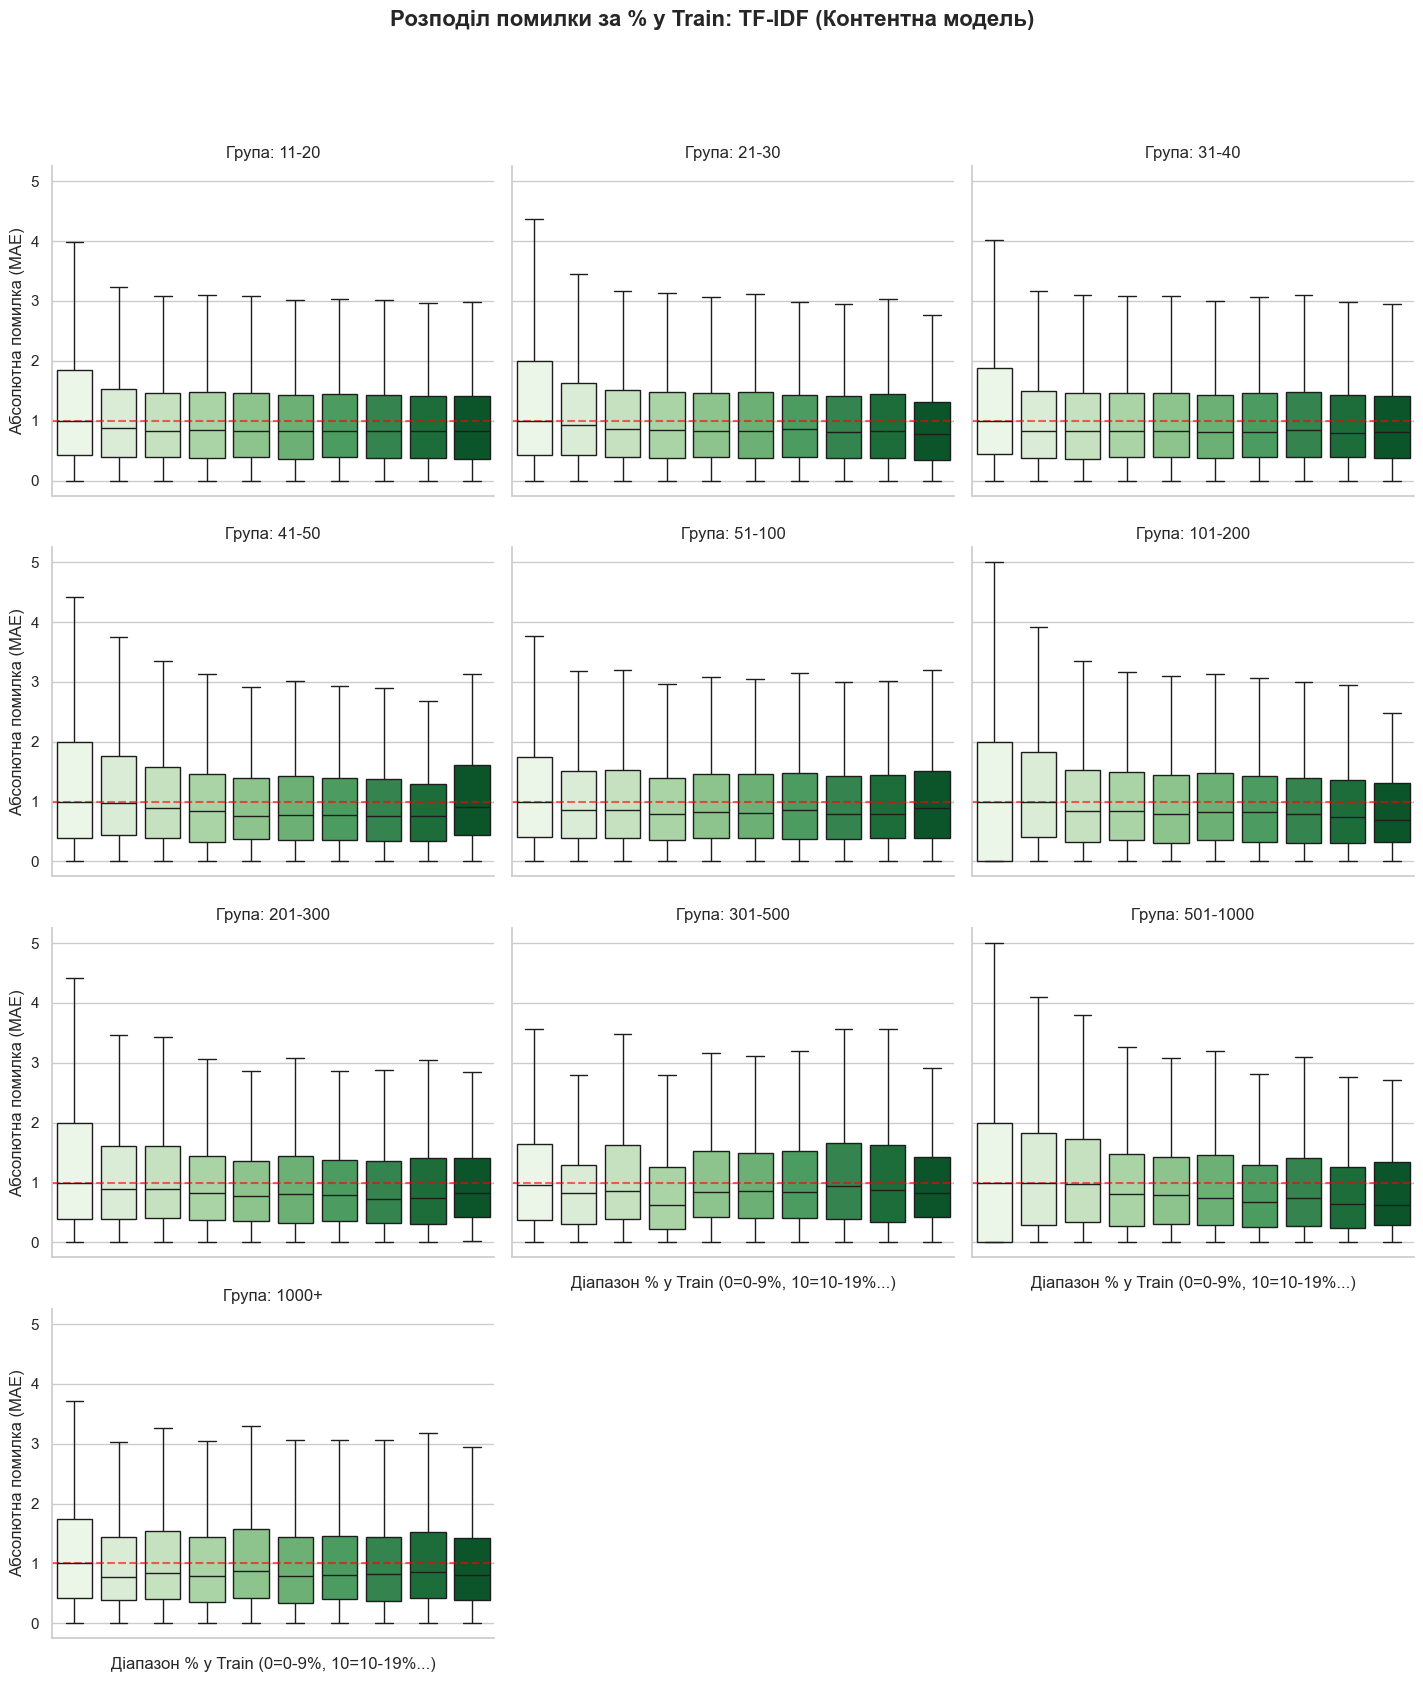

C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
C:\Users\Anton\AppData\Local\Temp\ipykernel_8440\2142763769.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklab

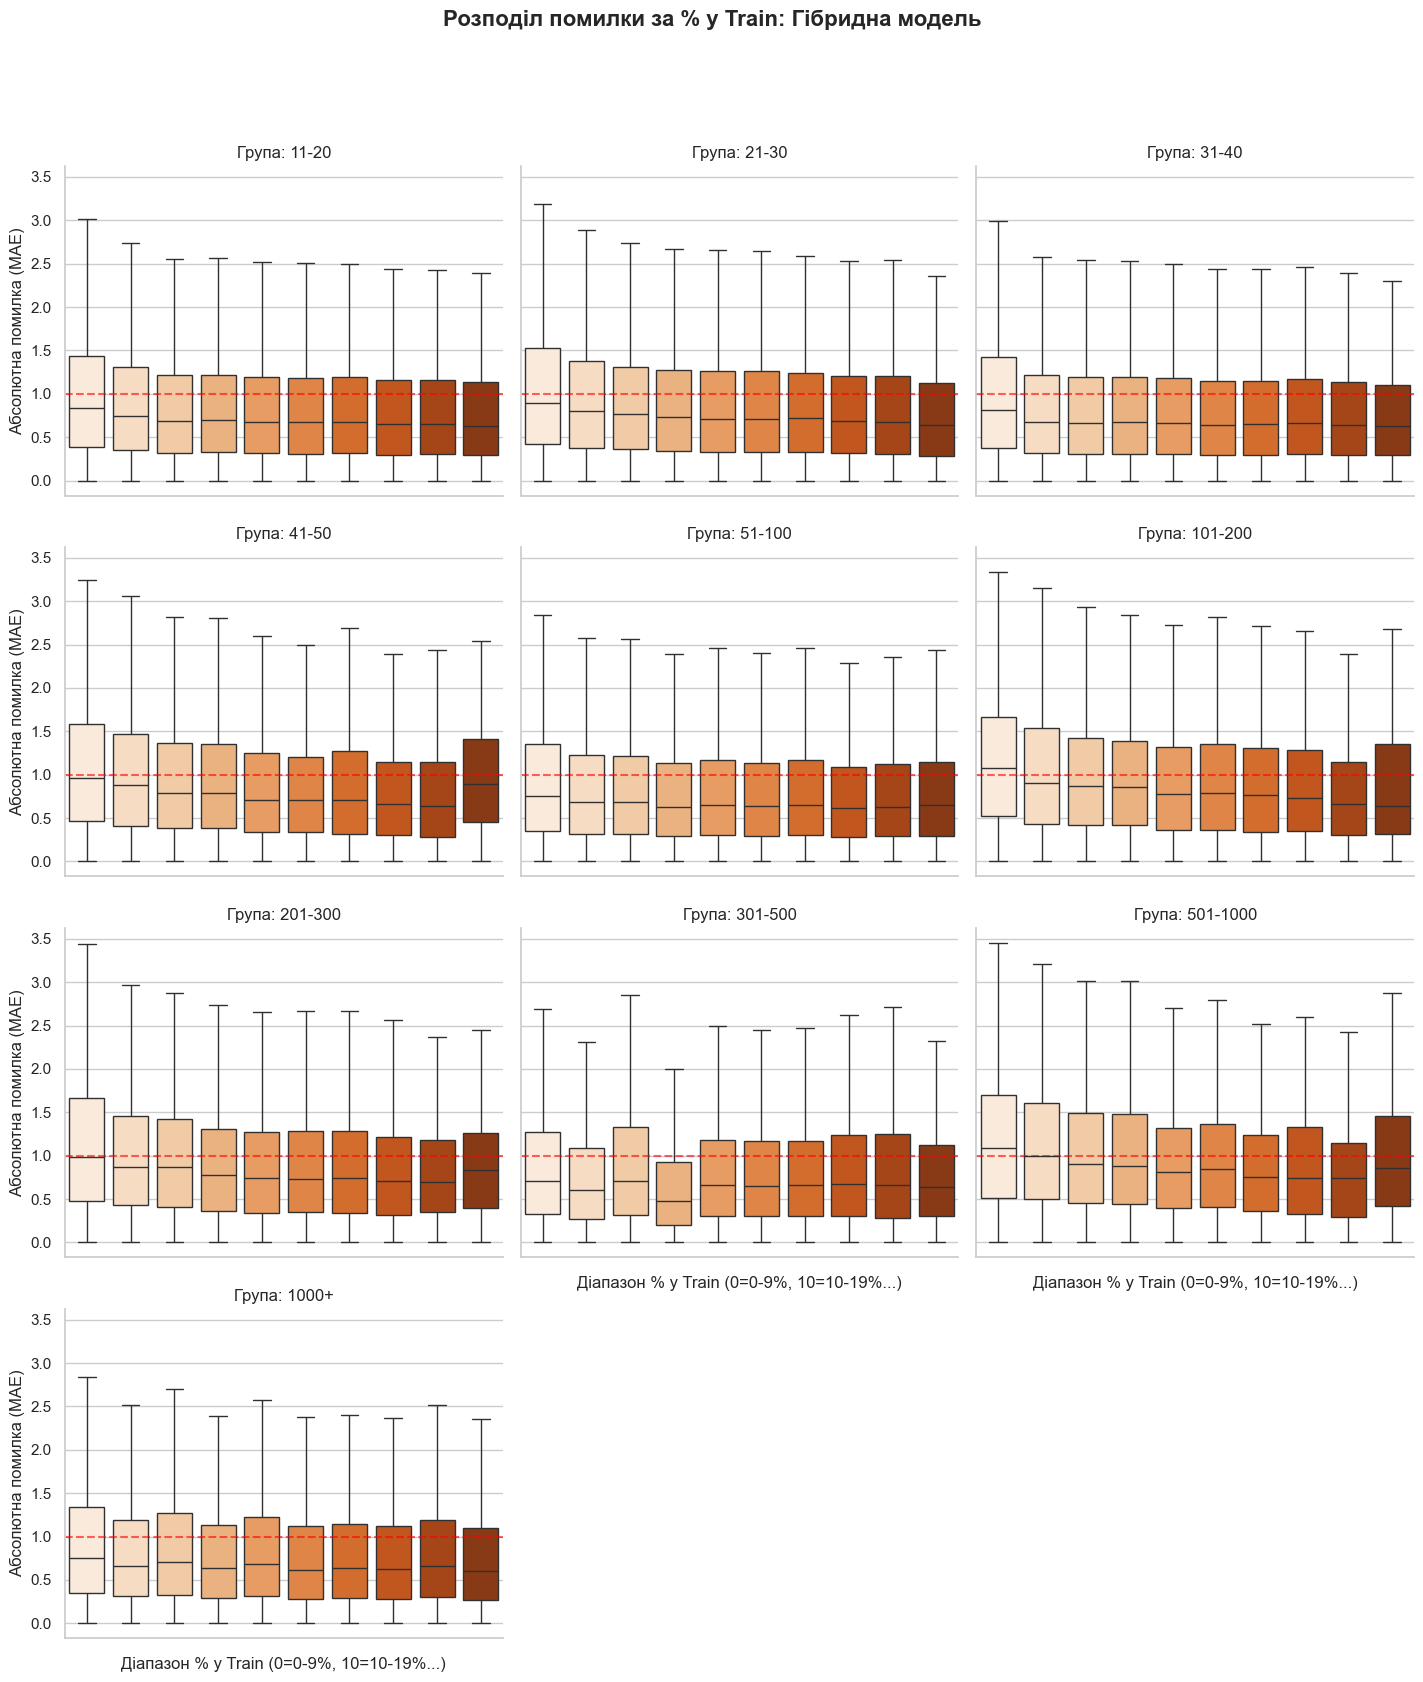

In [33]:
# Визначаємо список моделей: (колонка_з_помилкою, Назва моделі, палітра)
models_to_plot = [
    ('svd_abs_error', 'SVD (Колаборативна модель)', 'Blues'),
    ('content_abs_error', 'TF-IDF (Контентна модель)', 'Greens'),
    ('hybrid_abs_error', 'Гібридна модель', 'Oranges')
]

# Запускаємо цикл для створення 3 окремих сіток графіків
for error_col, model_name, palette_name in models_to_plot:
    
    # 1. Побудова фасетних боксплотів для поточної моделі
    # Використовуйте test або df_main_test залежно від того, де збережено помилки
    g = sns.catplot(
        data=df_main_test,
        x='train_pct_bin',
        y=error_col,           # Динамічно підставляємо помилку
        col='activity_group',
        col_wrap=3,            # Кількість графіків у рядку
        kind='box',
        showfliers=False,      # Прибираємо викиди
        height=4,
        aspect=1.2,
        palette=palette_name   # Динамічна палітра для кожної моделі
    )

    # 2. Налаштування осей та додавання референтної лінії
    for ax in g.axes.flat:
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
        # Обертаємо підписи, якщо вони зливаються (0 - рівно, 45 - під кутом)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    # 3. Підписи осей та заголовки
    g.set_axis_labels("Діапазон % у Train (0=0-9%, 10=10-19%...)", "Абсолютна помилка (MAE)")
    g.set_titles("Група: {col_name}", size=12)
    
    # Додаємо великий ГОЛОВНИЙ заголовок над усією сіткою
    g.fig.suptitle(f'Розподіл помилки за % у Train: {model_name}', y=1.05, fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()
    
    # Додаємо візуальний роздільник між виводами сіток
    print("\n" + "="*80 + "\n")

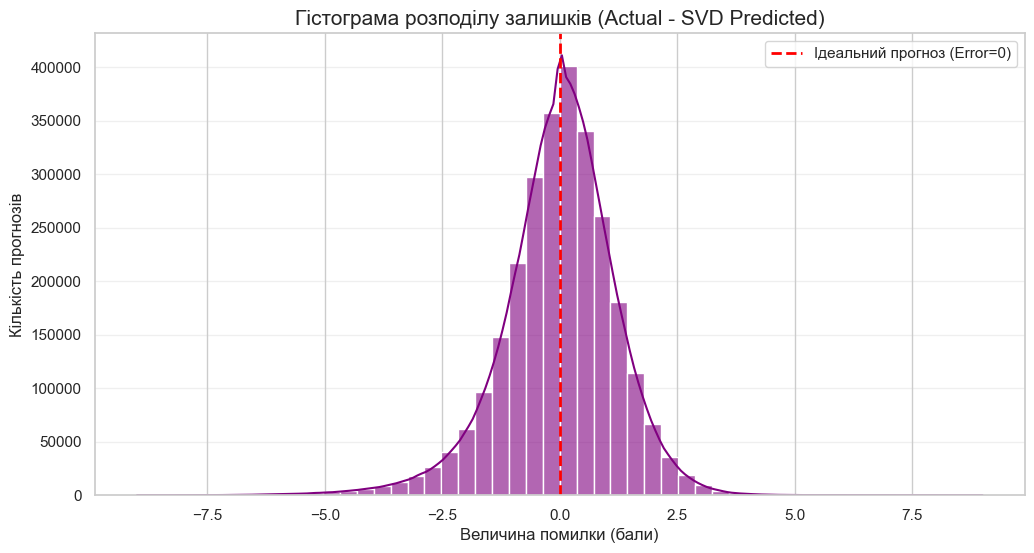

Середня помилка (Mean Error): -0.0160
Медіанна помилка (Median Error): 0.0470


In [34]:
# 1. Розраховуємо залишки (помилки)
# Actual - Predicted
test['error'] = test['rating'] - test['svd_pred']  # або content_pred, hybrid_pred залежно від того, яку модель хочете проаналізувати

# 2. Побудова графіка
plt.figure(figsize=(12, 6))
sns.histplot(test['error'], bins=50, kde=True, color='purple', alpha=0.6)

# Додаємо вертикальну лінію на рівні 0 (ідеальний прогноз)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ідеальний прогноз (Error=0)')

plt.title('Гістограма розподілу залишків (Actual - SVD Predicted)', fontsize=15)
plt.xlabel('Величина помилки (бали)', fontsize=12)
plt.ylabel('Кількість прогнозів', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Додаткова статистика
print(f"Середня помилка (Mean Error): {test['error'].mean():.4f}")
print(f"Медіанна помилка (Median Error): {test['error'].median():.4f}")

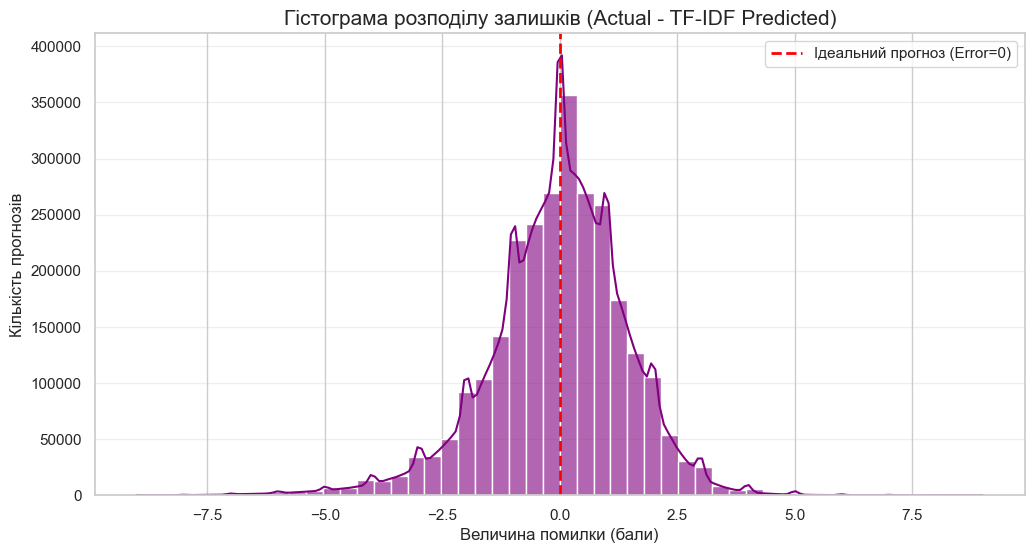

Середня помилка (Mean Error): -0.0355
Медіанна помилка (Median Error): 0.0122


In [35]:
# 1. Розраховуємо залишки (помилки)
# Actual - Predicted
test['error'] = test['rating'] - test['content_pred']  # або content_pred, hybrid_pred залежно від того, яку модель хочете проаналізувати

# 2. Побудова графіка
plt.figure(figsize=(12, 6))
sns.histplot(test['error'], bins=50, kde=True, color='purple', alpha=0.6)

# Додаємо вертикальну лінію на рівні 0 (ідеальний прогноз)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ідеальний прогноз (Error=0)')

plt.title('Гістограма розподілу залишків (Actual - TF-IDF Predicted)', fontsize=15)
plt.xlabel('Величина помилки (бали)', fontsize=12)
plt.ylabel('Кількість прогнозів', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Додаткова статистика
print(f"Середня помилка (Mean Error): {test['error'].mean():.4f}")
print(f"Медіанна помилка (Median Error): {test['error'].median():.4f}")

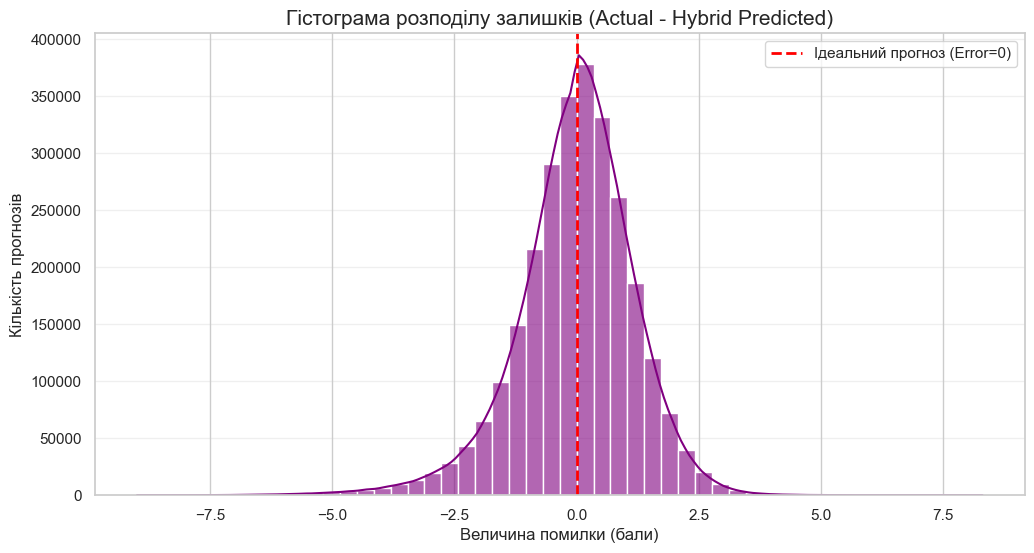

Середня помилка (Mean Error): -0.0194
Медіанна помилка (Median Error): 0.0563


In [36]:
# 1. Розраховуємо залишки (помилки)
# Actual - Predicted
test['error'] = test['rating'] - test['hybrid_pred']  # або content_pred, hybrid_pred залежно від того, яку модель хочете проаналізувати

# 2. Побудова графіка
plt.figure(figsize=(12, 6))
sns.histplot(test['error'], bins=50, kde=True, color='purple', alpha=0.6)

# Додаємо вертикальну лінію на рівні 0 (ідеальний прогноз)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ідеальний прогноз (Error=0)')

plt.title('Гістограма розподілу залишків (Actual - Hybrid Predicted)', fontsize=15)
plt.xlabel('Величина помилки (бали)', fontsize=12)
plt.ylabel('Кількість прогнозів', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Додаткова статистика
print(f"Середня помилка (Mean Error): {test['error'].mean():.4f}")
print(f"Медіанна помилка (Median Error): {test['error'].median():.4f}")

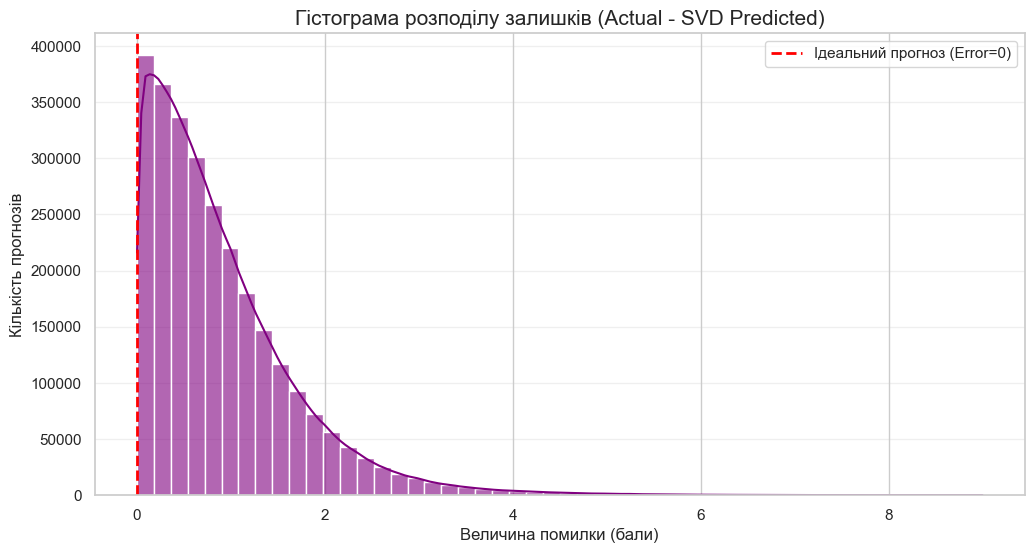

Середня помилка (Mean Error): 0.9042
Медіанна помилка (Median Error): 0.7027


In [37]:
# 2. Побудова графіка
plt.figure(figsize=(12, 6))
sns.histplot(test['svd_abs_error'], bins=50, kde=True, color='purple', alpha=0.6)

# Додаємо вертикальну лінію на рівні 0 (ідеальний прогноз)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ідеальний прогноз (Error=0)')

plt.title('Гістограма розподілу залишків (Actual - SVD Predicted)', fontsize=15)
plt.xlabel('Величина помилки (бали)', fontsize=12)
plt.ylabel('Кількість прогнозів', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Додаткова статистика
print(f"Середня помилка (Mean Error): {test['svd_abs_error'].mean():.4f}")
print(f"Медіанна помилка (Median Error): {test['svd_abs_error'].median():.4f}")

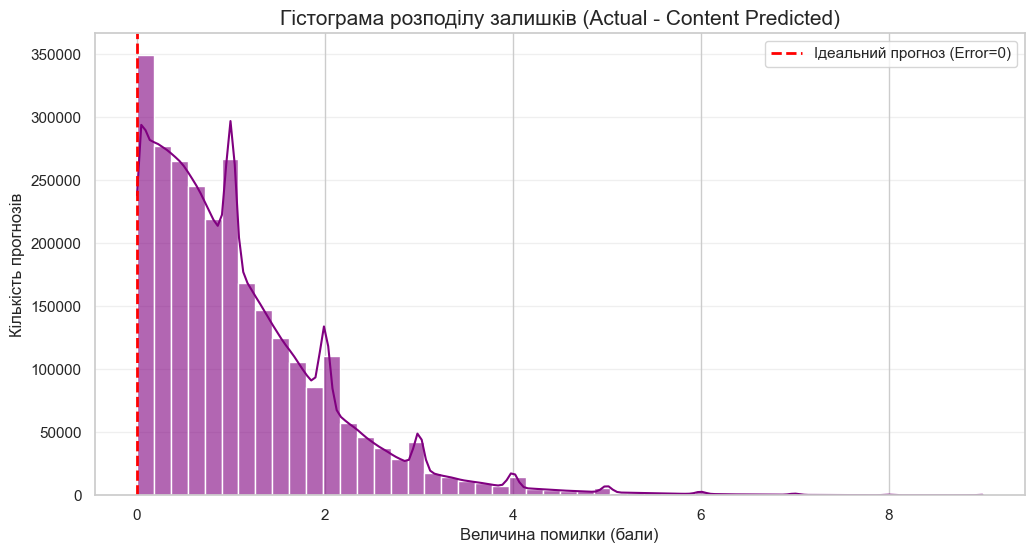

Середня помилка (Mean Error): 1.1056
Медіанна помилка (Median Error): 0.8902


In [38]:
# 2. Побудова графіка
plt.figure(figsize=(12, 6))
sns.histplot(test['content_abs_error'], bins=50, kde=True, color='purple', alpha=0.6)

# Додаємо вертикальну лінію на рівні 0 (ідеальний прогноз)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ідеальний прогноз (Error=0)')

plt.title('Гістограма розподілу залишків (Actual - Content Predicted)', fontsize=15)
plt.xlabel('Величина помилки (бали)', fontsize=12)
plt.ylabel('Кількість прогнозів', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Додаткова статистика
print(f"Середня помилка (Mean Error): {test['content_abs_error'].mean():.4f}")
print(f"Медіанна помилка (Median Error): {test['content_abs_error'].median():.4f}")

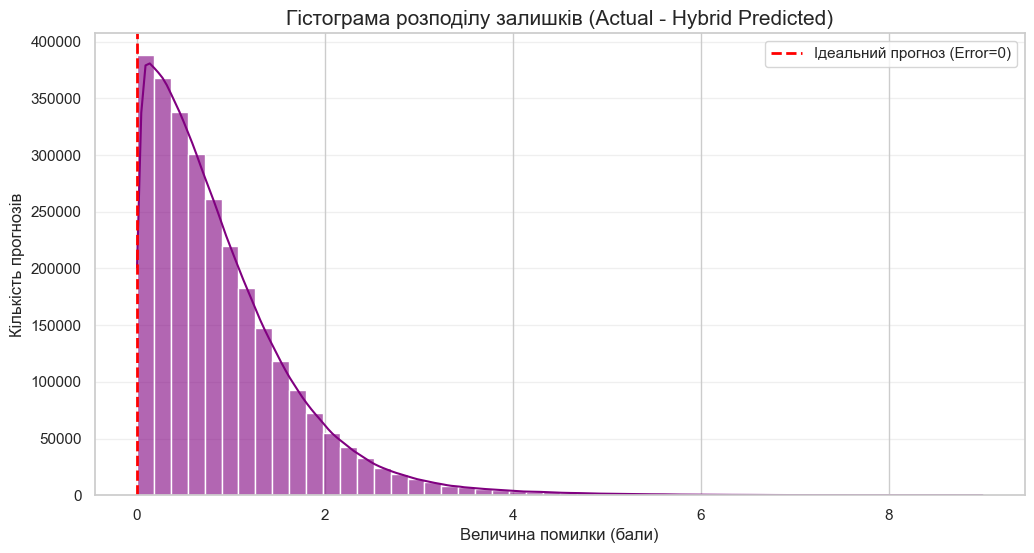

Середня помилка (Mean Error): 0.9018
Медіанна помилка (Median Error): 0.7028


In [39]:
# 2. Побудова графіка
plt.figure(figsize=(12, 6))
sns.histplot(test['hybrid_abs_error'], bins=50, kde=True, color='purple', alpha=0.6)

# Додаємо вертикальну лінію на рівні 0 (ідеальний прогноз)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ідеальний прогноз (Error=0)')

plt.title('Гістограма розподілу залишків (Actual - Hybrid Predicted)', fontsize=15)
plt.xlabel('Величина помилки (бали)', fontsize=12)
plt.ylabel('Кількість прогнозів', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Додаткова статистика
print(f"Середня помилка (Mean Error): {test['hybrid_abs_error'].mean():.4f}")
print(f"Медіанна помилка (Median Error): {test['hybrid_abs_error'].median():.4f}")

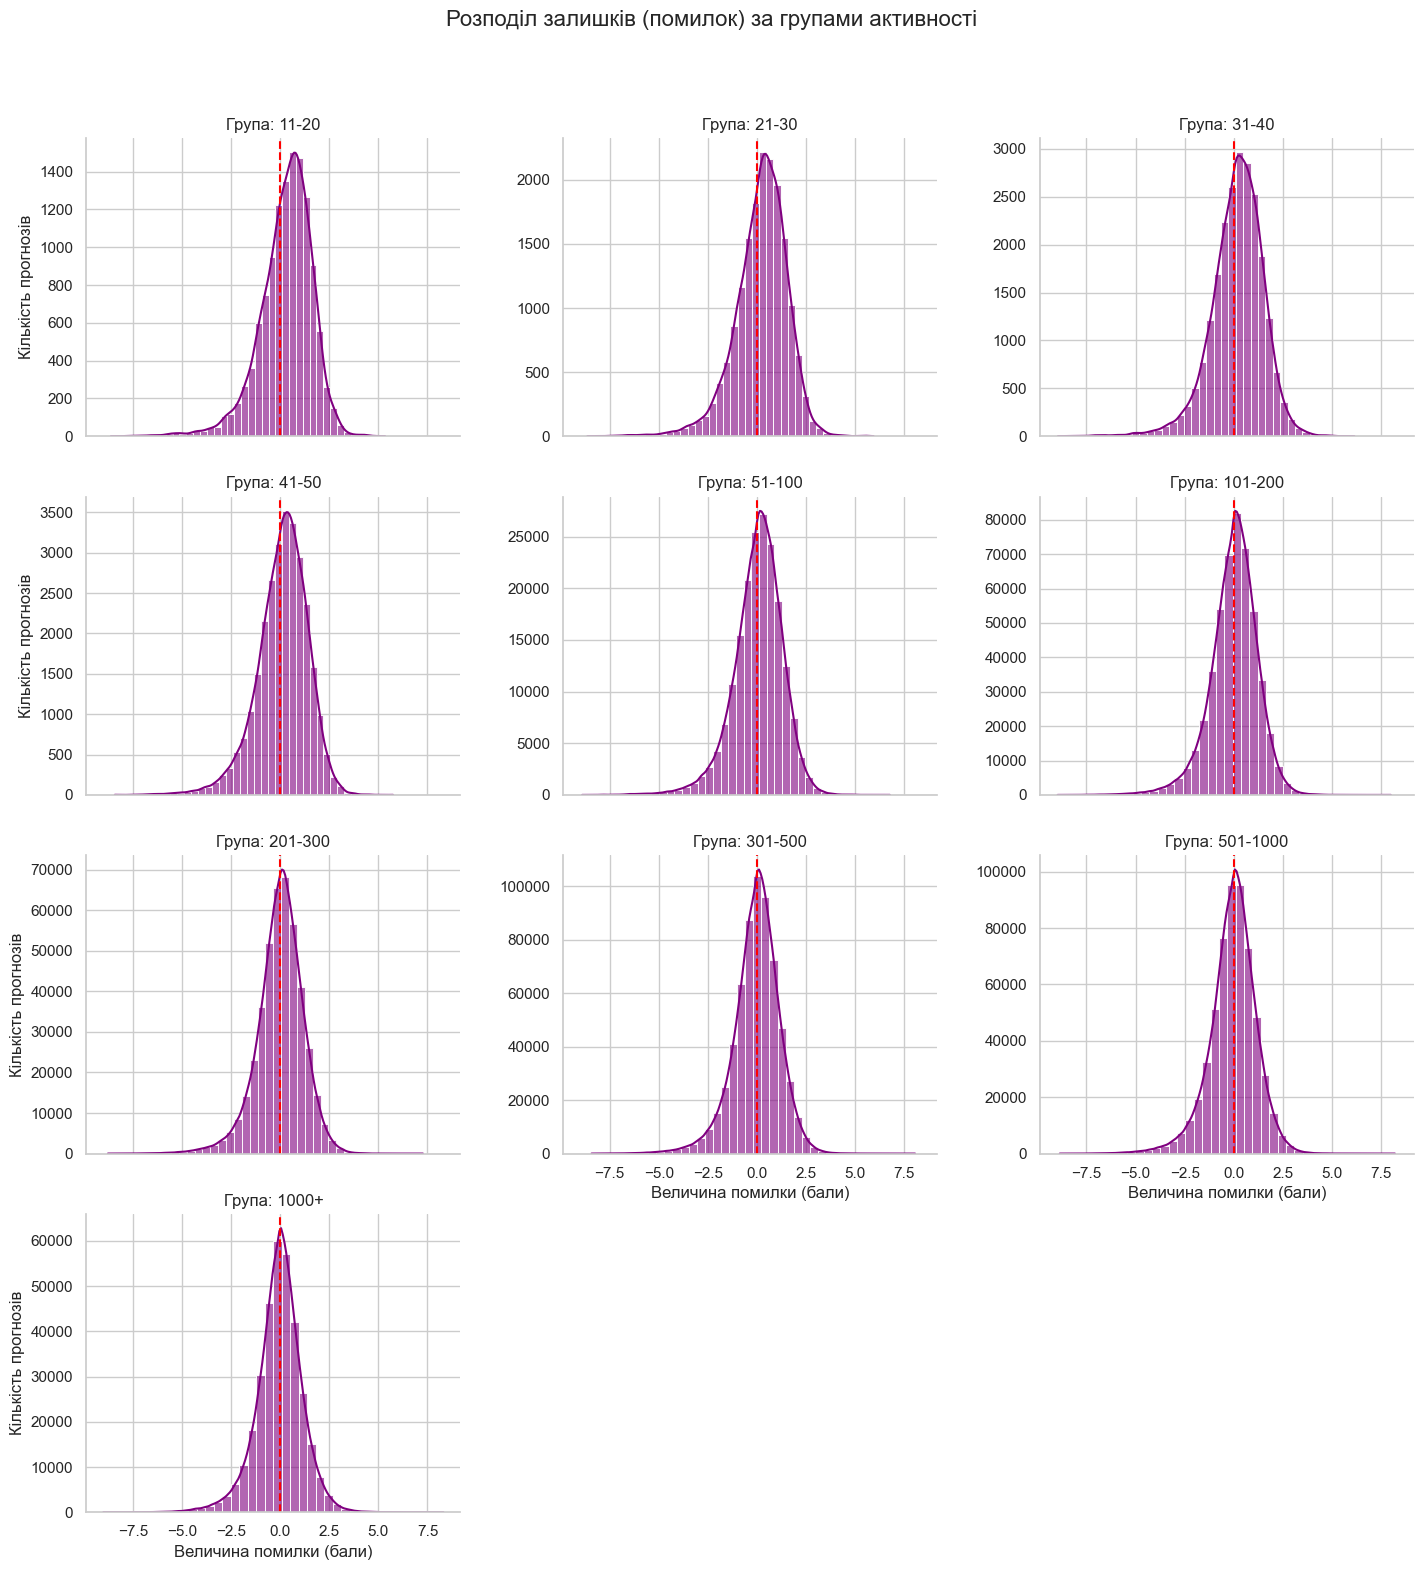

--------------------------------------------------
Статистика помилок по групах активності:
--------------------------------------------------
activity_group    mean  median  count
         11-20  0.3013  0.4691  12358
         21-30  0.2127  0.3407  17347
         31-40  0.1736  0.2743  22950
         41-50  0.1110  0.2302  28489
        51-100  0.0473  0.1437 188563
       101-200 -0.0025  0.0832 489548
       201-300 -0.0090  0.0635 433583
       301-500 -0.0355  0.0420 628325
      501-1000 -0.0545  0.0250 577567
         1000+ -0.0521  0.0000 336964


In [40]:
# Крок 2. Створюємо сітку графіків (FacetGrid)
# col_wrap=3 означає, що в одному рядку буде максимум 3 графіки, далі - перенесення
# sharey=False дуже важливо: у різних групах різна кількість людей, 
# тому шкала Y має бути своєю для кожного графіка, щоб їх було добре видно.
g = sns.FacetGrid(
    test, 
    col="activity_group", 
    col_wrap=3, 
    height=4, 
    aspect=1.2,
    sharex=True, 
    sharey=False 
)

# Крок 3. Наносимо гістограми на створену сітку
g.map_dataframe(
    sns.histplot, 
    x="error", 
    bins=40,              # Кількість стовпчиків (можна змінювати)
    kde=True,             # Лінія тренду
    color="purple", 
    alpha=0.6
)

# Крок 4. Додаємо червону пунктирну лінію на рівні 0 на кожен графік
# Для цього створюємо маленьку функцію-помічника
def add_zero_line(**kwargs):
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)

g.map(add_zero_line)

# Крок 5. Наводимо красу: підписи осей та заголовки
g.set_axis_labels("Величина помилки (бали)", "Кількість прогнозів")
g.set_titles(col_template="Група: {col_name}") # {col_name} автоматично підставить назву групи

# Загальний заголовок для всього малюнка
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Розподіл залишків (помилок) за групами активності', fontsize=16)

plt.show()

# Крок 6. Виводимо детальну статистику по кожній групі
print("-" * 50)
print("Статистика помилок по групах активності:")
print("-" * 50)

# Використовуємо groupby, щоб порахувати середнє (mean) та медіану (median) для кожної групи
group_stats = test.groupby('activity_group')['error'].agg(['mean', 'median', 'count']).reset_index()

# Округлюємо результати для красивого виводу
group_stats['mean'] = group_stats['mean'].round(4)
group_stats['median'] = group_stats['median'].round(4)

print(group_stats.to_string(index=False))

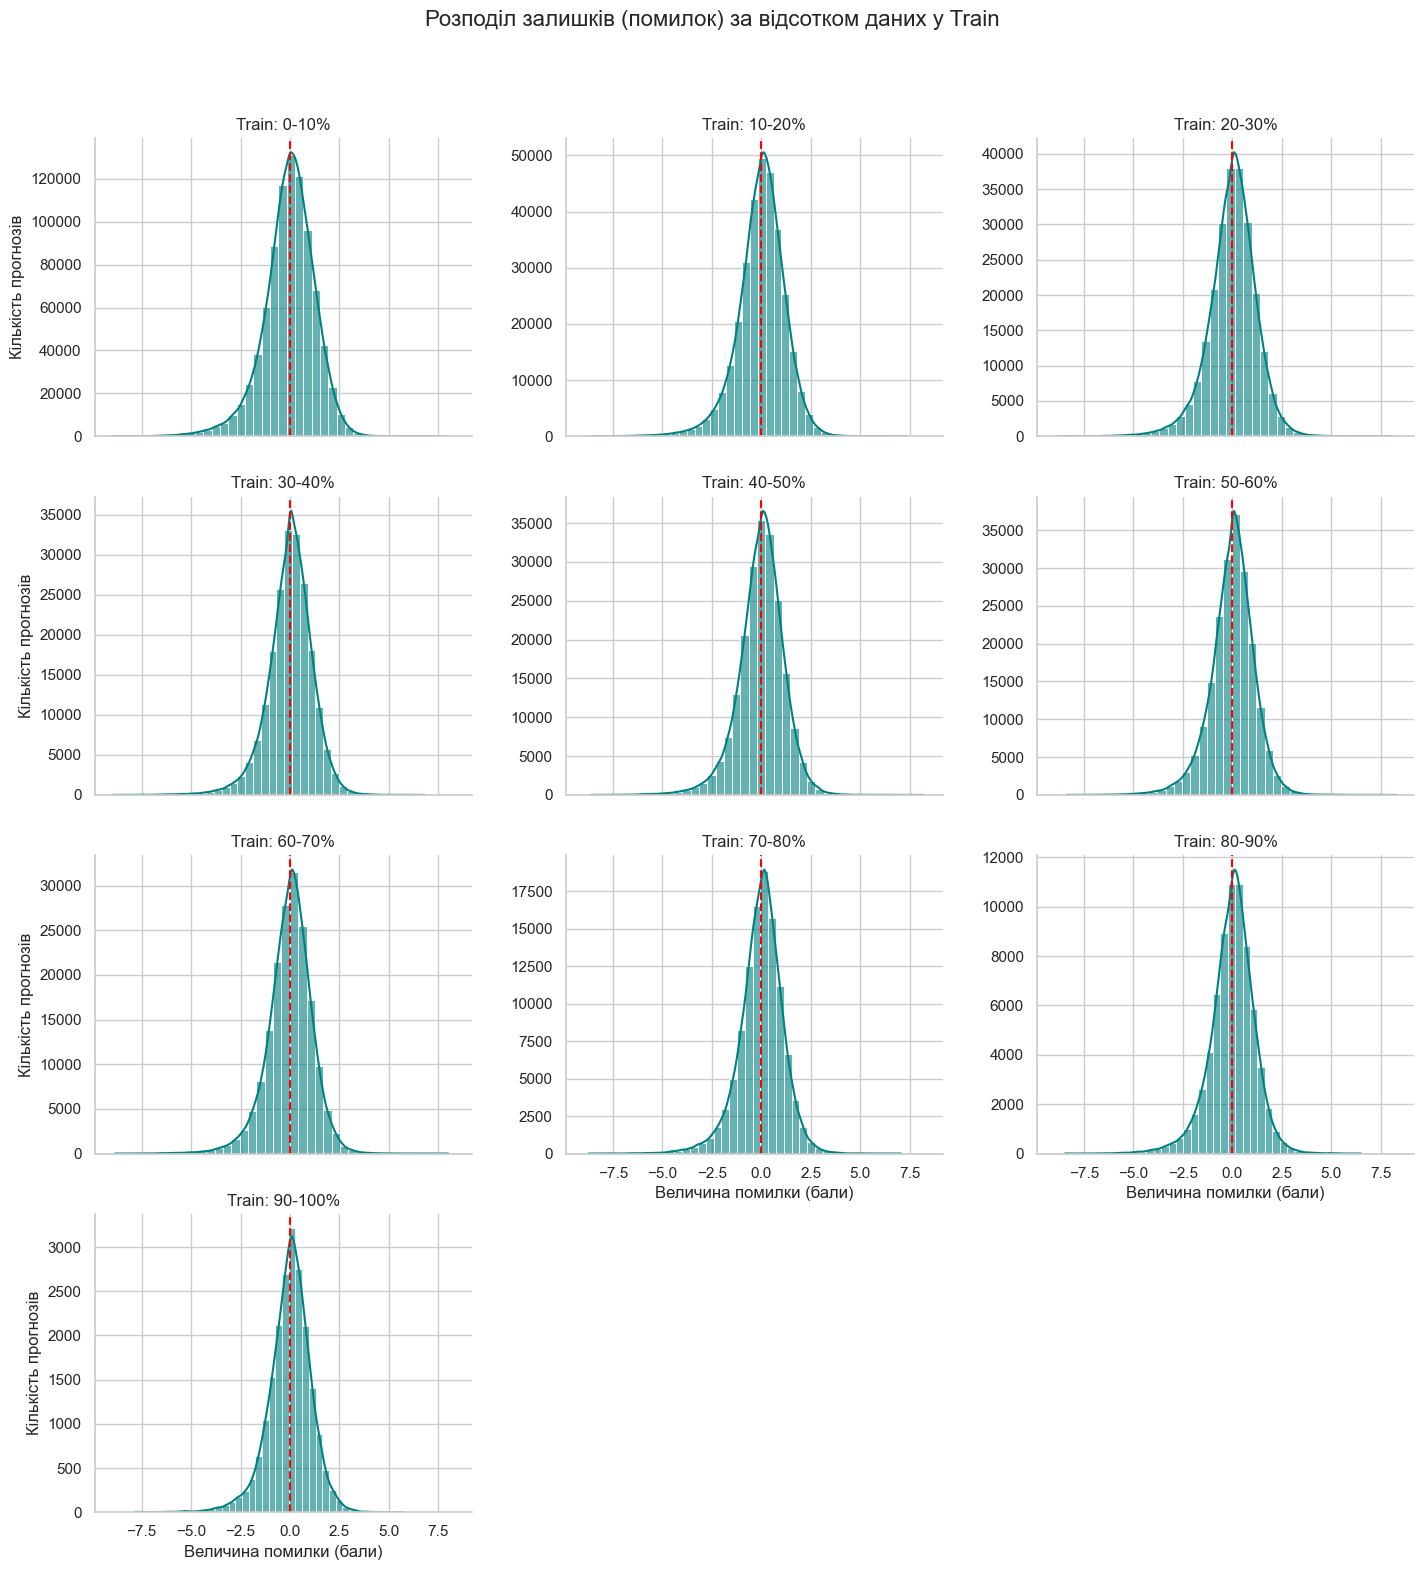

-------------------------------------------------------
Статистика помилок по діапазонах Train (%):
-------------------------------------------------------
train_pct_bin    mean  median  count
        0-10% -0.0429  0.0401 873224
       10-20% -0.0005  0.0747 317029
       20-30%  0.0009  0.0686 234842
       30-40% -0.0016  0.0641 204563
       40-50% -0.0123  0.0599 207755
       50-60% -0.0163  0.0550 201149
       60-70% -0.0160  0.0537 175745
       70-80% -0.0171  0.0572 109199
       80-90% -0.0146  0.0579  69948
      90-100% -0.0172  0.0510  20527


In [41]:
# Крок 2. Створюємо "кошики" (діапазони) по 10%
# Визначаємо межі від 0 до 100 з кроком 10
bins = list(range(0, 101, 10)) # Це створить список [0, 10, 20, 30... 100]
# Створюємо красиві підписи для графіків
labels = [f"{i}-{i+10}%" for i in range(0, 100, 10)] 

# Функція pd.cut розкладає числа по діапазонах
test['train_pct_bin'] = pd.cut(test['train_percent'], bins=bins, labels=labels, include_lowest=True)

# Крок 3. Створюємо сітку графіків (FacetGrid)
# Використовуємо нашу нову колонку train_pct_bin
g = sns.FacetGrid(
    test, 
    col="train_pct_bin", 
    col_wrap=3,        # По 3 графіки в рядку
    height=4, 
    aspect=1.2,
    sharex=True, 
    sharey=False       # Дозволяємо різну висоту стовпчиків, бо в групах різна кількість записів
)

# Крок 4. Малюємо гістограми
g.map_dataframe(
    sns.histplot, 
    x="error", 
    bins=40, 
    kde=True, 
    color="teal",      # Я змінив колір на смарагдовий (teal), щоб візуально відрізнити від минулого графіка
    alpha=0.6
)

# Крок 5. Додаємо червону лінію ідеального прогнозу (0)
def add_zero_line(**kwargs):
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)

g.map(add_zero_line)

# Крок 6. Налаштовуємо підписи та заголовки
g.set_axis_labels("Величина помилки (бали)", "Кількість прогнозів")
g.set_titles(col_template="Train: {col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Розподіл залишків (помилок) за відсотком даних у Train', fontsize=16)

plt.show()

# Крок 7. Розрахунок статистики для кожного діапазону
print("-" * 55)
print("Статистика помилок по діапазонах Train (%):")
print("-" * 55)

# Рахуємо середнє та медіану. observed=False потрібен для коректної роботи з категоріями в нових версіях Pandas
group_stats = test.groupby('train_pct_bin', observed=False)['error'].agg(['mean', 'median', 'count']).reset_index()

# Округлюємо для зручності читання
group_stats['mean'] = group_stats['mean'].round(4)
group_stats['median'] = group_stats['median'].round(4)

# Видаляємо порожні кошики (якщо такі є) і виводимо на екран
print(group_stats.dropna().to_string(index=False))

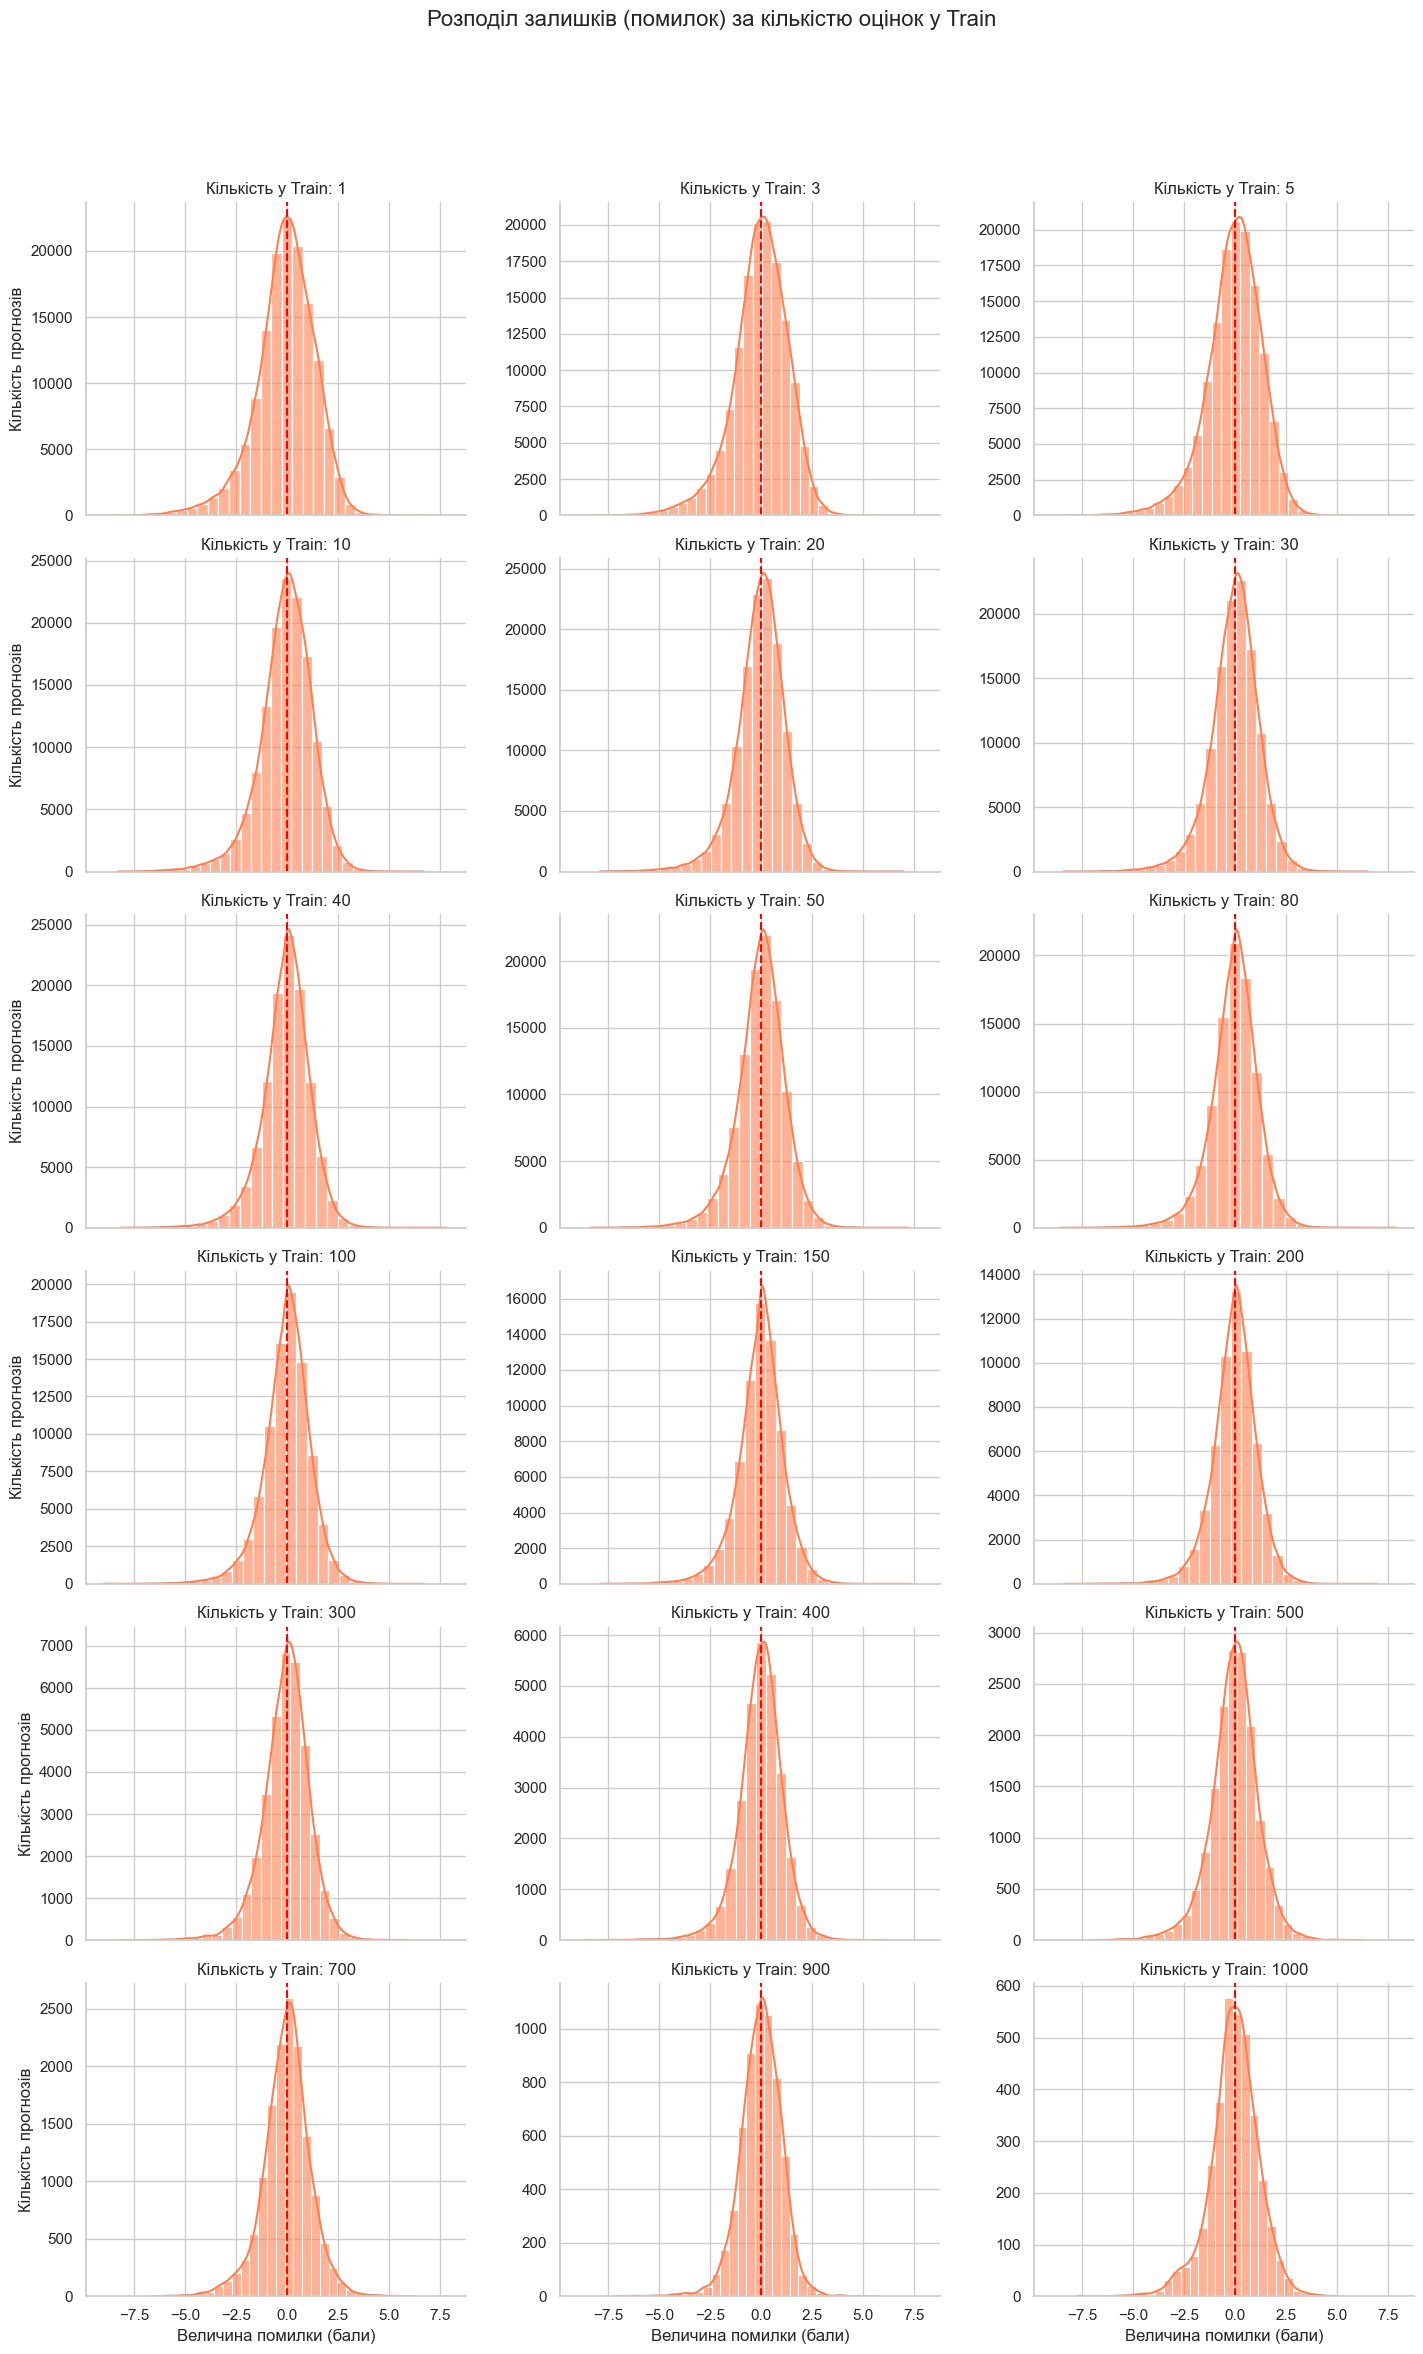

-------------------------------------------------------
Статистика помилок по кількості оцінок у Train:
-------------------------------------------------------
 train_count    mean  median  count
           1 -0.0725  0.0218 138756
           3 -0.0314  0.0600 136487
           5 -0.0335  0.0620 135799
          10 -0.0453  0.0458 134446
          20 -0.0351  0.0512 127220
          30 -0.0140  0.0580 118210
          40 -0.0350  0.0419 111016
          50 -0.0050  0.0681 106495
          80 -0.0229  0.0419  93323
         100 -0.0016  0.0690  88320
         150 -0.0237  0.0409  72193
         200 -0.0113  0.0346  58447
         300 -0.0333  0.0299  35714
         400 -0.0096  0.0427  27396
         500 -0.0259  0.0194  16005
         700 -0.0148  0.0339  14255
         900  0.0034  0.0438   6068
        1000 -0.0271  0.0259   3466


In [43]:
# ==========================================
# Етап 1: Підготовка даних
# ==========================================
# Розраховуємо помилку (Actual - Predicted)
# Якщо ти вже розрахував її раніше, цей рядок просто оновить дані
df_ref['error'] = df_ref['rating'] - df_ref['hybrid_pred']

# ==========================================
# Етап 2: Побудова сітки графіків
# ==========================================
# Використовуємо col="train_count", щоб створити окремий графік для кожної кількості оцінок
g = sns.FacetGrid(
    df_ref, 
    col="train_count", 
    col_wrap=3,        # Максимум 3 графіки в одному горизонтальному рядку
    height=4, 
    aspect=1.2,
    sharex=True,       # Усі графіки матимуть однакову вісь X для легкого порівняння
    sharey=False       # Вісь Y різна, бо кількість прогнозів у групах може сильно відрізнятися
)

# ==========================================
# Етап 3: Додавання гістограм та ліній
# ==========================================
# Будуємо гістограму з лінією тренду (kde=True)
g.map_dataframe(
    sns.histplot, 
    x="error", 
    bins=30,           # Кількість стовпчиків (можна змінити для більшої деталізації)
    kde=True, 
    color="coral",     # Колір графіка (кораловий)
    alpha=0.6
)

# Створюємо допоміжну функцію для малювання червоної лінії на нулі
def add_zero_line(**kwargs):
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)

# Застосовуємо цю функцію до кожного графіка в сітці
g.map(add_zero_line)

# ==========================================
# Етап 4: Наведення краси (підписи та заголовки)
# ==========================================
g.set_axis_labels("Величина помилки (бали)", "Кількість прогнозів")
g.set_titles(col_template="Кількість у Train: {col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Розподіл залишків (помилок) за кількістю оцінок у Train', fontsize=16)

plt.show()

# ==========================================
# Етап 5: Розрахунок та вивід текстової статистики
# ==========================================
print("-" * 55)
print("Статистика помилок по кількості оцінок у Train:")
print("-" * 55)

# Групуємо дані за train_count і рахуємо середнє, медіану та кількість записів
group_stats = df_ref.groupby('train_count')['error'].agg(['mean', 'median', 'count']).reset_index()

# Округлюємо результати до 4 знаків після коми, щоб таблиця виглядала охайно
group_stats['mean'] = group_stats['mean'].round(4)
group_stats['median'] = group_stats['median'].round(4)

# Виводимо результат без стандартних індексів зліва
print(group_stats.to_string(index=False))

In [44]:
output_dir = os.path.join('..', 'data')
test.to_parquet(os.path.join(output_dir, "test_complete_m3.parquet"), index=False)